# Crossectionnal MRI

## Define current working directory

In [49]:
import os
notebook_dir = os.getcwd()
print("Current notebook directory:", notebook_dir)

Current notebook directory: /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/WMH_analyses


## Define all good PR

In [6]:
# Import required libraries
import pandas as pd
import os

# Define file paths
flair_qc_path = os.path.join(notebook_dir, 'CSV/QC_FLAIR_150125.csv')
mpm_qc_path = os.path.join(notebook_dir, 'CSV/QC_MPM_150125.csv')
diff_qc_path = os.path.join(notebook_dir, 'CSV/QC_diffusion_150125.csv')

# Load datasets
flair_qc = pd.read_csv(flair_qc_path)
mpm_qc = pd.read_csv(mpm_qc_path)
diffusion_qc = pd.read_csv(diff_qc_path)

# Create PR variable
flair_qc['PR'] = flair_qc['NAMES FLAIR'].str[1:8]
flair_qc['QC_flair'] = flair_qc['QC']
mpm_qc['PR'] = mpm_qc['Names'].str[1:8]
diffusion_qc['PR'] = diffusion_qc['Names'].str[1:8]
diffusion_qc['QC_diff'] = diffusion_qc['QC']

# Merge QC togethe
flair_mpm_qc = pd.merge(flair_qc[['QC_flair','PR']], mpm_qc[['Names','QC_R1','QC_R2s','QC_MT','PR']], on='PR')
flair_mpm_diffusion_qc = pd.merge(flair_mpm_qc, diffusion_qc[['QC_diff','PR']], on='PR')

# Filter by QC criteria
good_QC = flair_mpm_diffusion_qc[
    (flair_mpm_diffusion_qc['QC_R1'].astype(float) < 2.5) &
    (flair_mpm_diffusion_qc['QC_R2s'].astype(float) < 2.5) &
    (flair_mpm_diffusion_qc['QC_MT'].astype(float) < 2.5) &
    (flair_mpm_diffusion_qc['QC_flair'].astype(float) < 2.5) &
    (flair_mpm_diffusion_qc['QC_diff'].astype(float) < 2.5)
]

# Create table with QC info
flair_mpm_diffusion_qc=flair_mpm_diffusion_qc.astype({'QC_flair': 'category', 'QC_R1': 'category', 'QC_R2s': 'category','QC_MT': 'category','QC_diff': 'category'})
#table_QC=TableOne(flair_mpm_diffusion_qc, columns=['QC_flair', 'QC_R1','QC_R2s','QC_MT','QC_diff'], pval=False)# Create a styled summary table
#table_QC.to_csv(os.path.join(notebook_dir, 'CSV/table_QC.csv'))

good_PR = good_QC['PR'].tolist()

# Print the length of good_PR for verification
print("Number of good PRs:", len(good_PR))


Number of good PRs: 481


## Match with CVR to select PR who have everything

In [10]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

# Load csv variable baseline
BL = pd.read_csv(os.path.join(notebook_dir, 'CSV/4AB_var_all_BD16052024_BL.csv'))
F1 = pd.read_csv(os.path.join(notebook_dir, 'CSV/4AB_var_all_BD16052024_F1.csv'))
F2 = pd.read_csv(os.path.join(notebook_dir, 'CSV/4AB_var_all_BD16052024_F2.csv'))
F3 = pd.read_csv(os.path.join(notebook_dir, 'CSV/4AB_var_all_BD16052024_F3.csv'))

# Load PT to colausID
PT_to_colaudID= pd.read_csv( os.path.join(notebook_dir, 'CSV/4AB_CORR_BD18052024.csv'))

# Convert columns to string
BL['pt'] = BL['pt'].astype(str)
F1['pt'] = F1['pt'].astype(str)
F2['pt'] = F2['pt'].astype(str)
F3['pt'] = F3['pt'].astype(str)
PT_to_colaudID['CoLaus_ID'] = PT_to_colaudID['CoLaus_ID'].astype(str)

# Select only rows from BL where variable_A equals 1
PT_to_colaudID_1=PT_to_colaudID[PT_to_colaudID['Family-ID']==1]
PT_to_colaudID_no1=PT_to_colaudID[PT_to_colaudID['Family-ID']!=1]


# Merge the DataFrames on the matching columns
merged_BL_1 = pd.merge(BL, PT_to_colaudID_1, left_on='pt', right_on='CoLaus_ID')
merged_F1_1 = pd.merge(F1, PT_to_colaudID_1, left_on='pt', right_on='CoLaus_ID')
merged_F2_1 = pd.merge(F2, PT_to_colaudID_1, left_on='pt', right_on='CoLaus_ID')
merged_F3_1 = pd.merge(F3, PT_to_colaudID_1, left_on='pt', right_on='CoLaus_ID')

merged_BL_no1 = pd.merge(BL, PT_to_colaudID_no1, left_on='pt', right_on='CoLaus_ID')
merged_F1_no1 = pd.merge(F1, PT_to_colaudID_no1, left_on='pt', right_on='CoLaus_ID')
merged_F2_no1 = pd.merge(F2, PT_to_colaudID_no1, left_on='pt', right_on='CoLaus_ID')
merged_F3_no1 = pd.merge(F3, PT_to_colaudID_no1, left_on='pt', right_on='CoLaus_ID')

# Create PR variable
merged_BL_1['PR'] = 's' + merged_BL_1['SubjectName'].str[:16]
merged_F1_1['PR'] = 's' + merged_F1_1['SubjectName'].str[:16]
merged_F2_1['PR'] = 's' + merged_F2_1['SubjectName'].str[:16]
merged_F3_1['PR'] = 's' + merged_F3_1['SubjectName'].str[:16]

merged_BL_no1['PR'] = 's' + merged_BL_no1['SubjectName'].str[:16]
merged_F1_no1['PR'] = 's' + merged_F1_no1['SubjectName'].str[:16]
merged_F2_no1['PR'] = 's' + merged_F2_no1['SubjectName'].str[:16]
merged_F3_no1['PR'] = 's' + merged_F3_no1['SubjectName'].str[:16]

# Find common PRs
common_PR_BL_F1 = sorted(list(set(merged_BL_1['PR']).intersection(set(merged_F1_1['PR']))))
common_PR_F2_F3 = sorted(list(set(merged_F2_1['PR']).intersection(set(merged_F3_1['PR']))))
common_PR_BL_F1_F2_F3 = sorted(list(set(common_PR_BL_F1).intersection(set(common_PR_F2_F3))))
print(f"Number of common PR names in merged_F1_1 and merged_BL_1: {len(common_PR_BL_F1)}")
print(f"Number of common PR names in merged_F2_1 and merged_F3_1: {len(common_PR_F2_F3)}")
print(f"Number of common PR names across BL, F1, F2, F3: {len(common_PR_BL_F1_F2_F3)}")

common_PR_BL_F1_no1 = sorted(list(set(merged_BL_no1['PR']).intersection(set(merged_F1_no1['PR']))))
common_PR_F2_F3_no1 = sorted(list(set(merged_F2_no1['PR']).intersection(set(merged_F3_no1['PR']))))
common_PR_BL_F1_F2_F3_no1 = sorted(list(set(common_PR_BL_F1_no1).intersection(set(common_PR_F2_F3_no1))))

# Filter common_PR_BL_F1_F2_F3 by checking 2nd to 8th characters against good_PR
common_PR_BL_F1_F2_F3_good_PR = sorted([
    pr for pr in common_PR_BL_F1_F2_F3 if pr[1:8] in good_PR
])

# Update common_PR to also include filtering with pathID_ok
common_PR = common_PR_BL_F1_F2_F3_good_PR

# Print the filtered results
print(f"Number of PRs in common_PR_BL_F1_F2_F3_good_PR: {len(common_PR_BL_F1_F2_F3_good_PR)}")

# Create DataFrame with good PRs
df_common_PR_good = pd.DataFrame(common_PR_BL_F1_F2_F3_good_PR, columns=['PR'])

# Merge the DataFrames on the matching columns
merged_BL_1_common = pd.merge(merged_BL_1, df_common_PR_good, on='PR')
merged_F1_1_common = pd.merge(merged_F1_1, df_common_PR_good, on='PR')
merged_F2_1_common = pd.merge(merged_F2_1, df_common_PR_good, on='PR')
merged_F3_1_common = pd.merge(merged_F3_1, df_common_PR_good, on='PR')

# Verify that the merged files contain only PRs matching good_PR
print(f"Number of PRs in merged_BL_1_common: {len(merged_BL_1_common['PR'].unique())}")
print(f"Number of PRs in merged_F1_1_common: {len(merged_F1_1_common['PR'].unique())}")
print(f"Number of PRs in merged_F2_1_common: {len(merged_F2_1_common['PR'].unique())}")
print(f"Number of PRs in merged_F3_1_common: {len(merged_F3_1_common['PR'].unique())}")



Number of common PR names in merged_F1_1 and merged_BL_1: 249
Number of common PR names in merged_F2_1 and merged_F3_1: 245
Number of common PR names across BL, F1, F2, F3: 244
Number of PRs in common_PR_BL_F1_F2_F3_good_PR: 169
Number of PRs in merged_BL_1_common: 169
Number of PRs in merged_F1_1_common: 169
Number of PRs in merged_F2_1_common: 169
Number of PRs in merged_F3_1_common: 169


## For Fabio

In [19]:
merged_F3_1.to_csv(os.path.join(notebook_dir, 'CSV/merged_F3_1.csv'))
print(merged_F3_1)

,pt,F3sex,F3datexam,F3age,F3cmp,F3hdv,F3chf,F3artm,F3angn,F3miac,...,CoLaus_ID,Family-ID,Follow-up,SubjectName,Age,Unnamed: 6,Gender,StudySubjectID,StudyDate,PR
0,1,1.0,15aug2018,61.900002,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1.0,4.0,PR06239_DB110956^C,66.54,NaN,M,50001-1-4,2023-03-29,sPR06239_DB110956
1,44,0.0,30apr2018,62.500000,0.0,0.0,0.0,0.0,0.0,0.0,...,44,1.0,4.0,PR06351_AB121155^C,67.57,NaN,F,50044-1-4,2023-06-06,sPR06351_AB121155
2,60,0.0,14may2018,70.300003,0.0,0.0,0.0,0.0,0.0,0.0,...,60,1.0,4.0,PR05768_CH110148^C,74.22,NaN,F,50060-01-4,2022-03-31,sPR05768_CH110148
3,103,0.0,15may2018,72.300003,0.0,0.0,0.0,0.0,0.0,0.0,...,103,1.0,4.0,PR05792_MF040246^C,76.20,NaN,F,50103-01-4,2022-04-19,sPR05792_MF040246
4,105,0.0,17-Jul-18,66.699997,0.0,0.0,0.0,0.0,0.0,0.0,...,105,1.0,4.0,PR05741_CH221051^C,70.38,NaN,F,50105-01-4,2022-03-09,sPR05741_CH221051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,9355,0.0,05-Nov-18,72.400002,0.0,0.0,0.0,0.0,0.0,0.0,...,9355,1.0,4.0,PR06385_IS260546^C,77.30,NaN,F,60355-1-4,2023-09-13,sPR06385_IS260546
242,9390,0.0,07dec2018,74.900002,0.0,0.0,0.0,0.0,0.0,0.0,...,9390,1.0,4.0,PR06458_NL190144^C,79.84,NaN,F,60390-1-4,2023-11-21,sPR06458_NL190144
243,9402,0.0,04feb2019,62.099998,0.0,0.0,0.0,0.0,0.0,0.0,...,9402,1.0,4.0,PR05879_KH171256^C,65.52,NaN,F,60402-01-4,2022-06-23,sPR05879_KH171256
244,9476,1.0,20feb2019,62.400002,0.0,0.0,0.0,0.0,0.0,0.0,...,9476,1.0,4.0,PR06483_GD121056^C,67.15,NaN,M,60476-1-4,2023-12-06,sPR06483_GD121056


## Define cross-sectionnal data (i.e. all good FLAIR + segmentation)

In [30]:
### cross-sectional from brainlaus
### TO CHECK : new data from which dataset???

PT_to_colaudID = PT_to_colaudID.copy()  # Create a copy of the DataFrame
PT_to_colaudID['PR_short'] = PT_to_colaudID['SubjectName'].str[:7]
merged_PR = pd.merge(good_QC, PT_to_colaudID, left_on='PR', right_on='PR_short')
PR_colaus_cross_sectionnal = merged_PR[merged_PR['Unnamed: 0'] != 'UNKNOWN']
#PR_colaus = PR_colaus[PR_colaus['Unnamed: 0'] != 'NCCR']
#PR_colaus_cross_sectionnal = PR_colaus_cross_sectionnal[PR_colaus_cross_sectionnal['Unnamed: 0'] != 'SACR']
PR_colaus_cross_sectionnal = PR_colaus_cross_sectionnal.copy()  # Create a copy of the DataFrame
PR_colaus_cross_sectionnal['PR'] = 's' + PR_colaus_cross_sectionnal['SubjectName'].str[:16]
len(PR_colaus_cross_sectionnal)

441

## Process these specific scans using common_PR - cross-sectional (DO NOT RERUN)

In [51]:
import os
import nibabel as nib
import glob
import numpy as np
from scipy.ndimage import binary_dilation, binary_erosion, binary_fill_holes
import pickle
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

def load_nifti_data(file_path):
    if isinstance(file_path, list):
        file_path = file_path[0] if file_path else None  # Select the first file if the list is non-empty
    try:
        data = nib.load(file_path).get_fdata() if file_path else None
        return data
    except Exception as e:
        print(f"Error loading NIfTI file {file_path}: {e}")
        return None


def save_checkpoint(data, filename):
    temp_filename = filename + '.tmp'
    with open(temp_filename, 'wb') as f:
        pickle.dump(data, f)
    os.replace(temp_filename, filename)

def load_checkpoint(filename):
    if os.path.exists(filename):
        try:
            with open(filename, 'rb') as f:
                return pickle.load(f)
        except (pickle.UnpicklingError, EOFError) as e:
            print(f"Error loading checkpoint {filename}: {e}")
            return None
    return None

def save_batch(batch_data, batch_index, batch_type='masks'):
    batch_folder = dictionnary_dir
    batch_file = os.path.join(batch_folder, f'{batch_type}_batch_cross_sectionnal_{batch_index}.pkl')
    with open(batch_file, 'wb') as f:
        pickle.dump(batch_data, f)

def apply_mask(data, mask):
    if data is not None and mask is not None:
        return data * mask
    return data

def save_cleaned_wmh_data(wmh_data, original_file_path):
    if wmh_data is not None:
        # Load the original WMH NIfTI to get the affine matrix
        original_nifti = nib.load(original_file_path)
        affine_matrix = original_nifti.affine  # Extract affine matrix
        
        # Create the output filename by adding 'cleaned' to the original filename
        cleaned_filename = original_file_path.replace('.nii.gz', '_cleaned.nii.gz')
        
        # Create a NIfTI image object from the cleaned data using the original affine matrix
        cleaned_nifti = nib.Nifti1Image(wmh_data, affine_matrix)
        
        # Save the cleaned data
        nib.save(cleaned_nifti, cleaned_filename)
        print(f"Saved cleaned WMH data to {cleaned_filename}")
    else:
        print("No cleaned WMH data to save.")

def process_subject(pr_tuple):
    pr, pr_short = pr_tuple
    subject_data = {}

    # Define paths based on the updated structure
    wm_file_path = glob.glob(os.path.join(dir_path, 'MPRAGE', pr, f'{pr}*WM.*'))
    wmh_file_path = glob.glob(os.path.join(dir_path, 'FLAIR', pr, f'whitenet_FLAIR_WMH_sanlm_m{pr}*_in_MPRAGE_masked_in_MPM.nii.gz'))
    csf_file_path = glob.glob(os.path.join(dir_path, 'MPRAGE', pr, f'{pr}*CSF.*'))

    wm_data = load_nifti_data(wm_file_path)
    wmh_data = load_nifti_data(wmh_file_path)
    csf_data = load_nifti_data(csf_file_path)

    if wm_data is not None:
        subject_data['WM'] = wm_data
    if csf_data is not None:
        subject_data['CSF'] = csf_data

    if wm_data is not None and wmh_data is not None:
        wmh_data = np.where((wmh_data == 1) & (wm_data == 0), 0, wmh_data)
        nawm_data = np.logical_and(wm_data == 1, wmh_data == 0).astype(np.uint8)
        subject_data['NAWM'] = nawm_data
        subject_data['WMH'] = wmh_data
    else:
        nawm_data = None

    if wmh_data is not None:
        wmh_dilated = binary_dilation(wmh_data, iterations=1)
        wmh_inverted = np.logical_not(wmh_data).astype(np.uint8)
        layer_1 = wmh_dilated * wmh_inverted

        layers = [apply_mask(layer_1, nawm_data)] + [
            apply_mask(np.logical_xor(binary_dilation(wmh_data, iterations=i+1), binary_dilation(wmh_data, iterations=i)), nawm_data)
            for i in range(1, 5)
        ]
        subject_data['Layers'] = layers

        # Define Inner Layers
        inner_layer_1 = np.logical_xor(wmh_data, binary_erosion(wmh_data, iterations=1))
        inner_layer_2 = binary_erosion(wmh_data, iterations=1).astype(np.uint8) - binary_erosion(wmh_data, iterations=2).astype(np.uint8)
        
        subject_data['InnerLayers'] = [inner_layer_1, inner_layer_2]

        wmh_center_mask = binary_erosion(wmh_data, iterations=2)
        subject_data['WMH_center'] = wmh_center_mask

        # Now save the cleaned WMH data with 'cleaned' added to the filename
        save_cleaned_wmh_data(wmh_data, wmh_file_path[0])  # Save using the original file path

    if nawm_data is not None:
        wmh_dilated_mask = binary_dilation(wmh_data, iterations=5)
        wmh_inverted_mask = np.logical_not(wmh_dilated_mask).astype(np.uint8)
        wm_left_mask = nawm_data * wmh_inverted_mask
        subject_data['WM_left'] = wm_left_mask

    if csf_data is not None and wm_data is not None:
        csf_dilated_mask = binary_dilation(csf_data, iterations=8)
        combined_wm_csf = np.logical_or(wm_data, csf_dilated_mask).astype(np.uint8)

        # Fill holes in the combined WM and CSF mask
        combined_filled = binary_fill_holes(combined_wm_csf).astype(np.uint8)

        # Erode the filled combined mask
        combined_eroded = binary_erosion(combined_filled, iterations=2)

        # Define SWM mask
        swm_mask = combined_filled * np.logical_not(combined_eroded).astype(np.uint8)
        subject_data['SWM'] = swm_mask

        # Define PVWM mask
        csf_dilated_mask = binary_dilation(csf_data, iterations=8)
        csf_inverted_mask = np.logical_not(csf_data).astype(np.uint8)
        pvwm_mask = csf_dilated_mask * csf_inverted_mask * wm_data
        subject_data['PVWM'] = pvwm_mask      
        
    if all(mask in subject_data for mask in ['WM', 'PVWM', 'SWM', 'CSF']):
        dwm_mask = wm_data * np.logical_not(subject_data['PVWM']) * np.logical_not(subject_data['SWM']) * np.logical_not(csf_data).astype(np.uint8)
        subject_data['DWM'] = dwm_mask

    if 'WMH' in subject_data:
        subject_data['WMH_DWM'] = np.logical_and(subject_data['WMH'], subject_data.get('DWM', 0)).astype(np.uint8)
        subject_data['WMH_SWM'] = np.logical_and(subject_data['WMH'], subject_data.get('SWM', 0)).astype(np.uint8)
        subject_data['WMH_PVWM'] = np.logical_and(subject_data['WMH'], subject_data.get('PVWM', 0)).astype(np.uint8)

    if 'NAWM' in subject_data:
        subject_data['NAWM_SWM'] = nawm_data * subject_data.get('SWM', 0)
        subject_data['NAWM_DWM'] = nawm_data * subject_data.get('DWM', 0)
        subject_data['NAWM_PVWM'] = nawm_data * subject_data.get('PVWM', 0)

    return pr, subject_data

def load_metrics(pr):
    subject_metrics = {}
    for data_type, file_pattern in data_types.items():
        metric_file_pattern = os.path.join(mpm_path, pr, file_pattern)
        metric_files = glob.glob(metric_file_pattern)
        
        for metric_file_path in metric_files:
            metric_data = load_nifti_data(metric_file_path)
            if metric_data is not None:
                if data_type not in subject_metrics:
                    subject_metrics[data_type] = {}
                subject_metrics[data_type][pr] = metric_data
    return subject_metrics

def calculate_mean_sd_metrics(data_type, metric_data_dict, mask_dict):
    mean_metrics = {key: {} for key in mask_dict.keys() if key not in ['WM', 'CSF']}
    sd_metrics = {key: {} for key in mask_dict.keys() if key not in ['WM', 'CSF']}
    for subject, metric_data in metric_data_dict.items():
        for mask_key in mean_metrics.keys():
            if mask_key in mask_dict and subject in mask_dict[mask_key]:
                mask_data = mask_dict[mask_key][subject]
                masked_metric_data = metric_data[mask_data == 1]
                if masked_metric_data.size > 0:
                    mean_value = np.mean(masked_metric_data)
                    sd_value = np.std(masked_metric_data)
                else:
                    mean_value = np.nan
                    sd_value = np.nan
                mean_metrics[mask_key][subject] = mean_value
                sd_metrics[mask_key][subject] = sd_value
    return data_type, mean_metrics, sd_metrics

def process_and_save_batch(pr_batch, batch_index):
    # Initialize the nifti_masks dictionary for the batch
    batch_masks = {key: {} for key in [
        'WM', 'WMH', 'CSF', 'NAWM', 'Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5',
        'InnerLayer1', 'InnerLayer2', 'WMH_center', 'WM_left', 'PVWM', 'SWM', 'DWM', 
        'WMH_DWM', 'WMH_SWM', 'WMH_PVWM', 'NAWM_SWM', 'NAWM_DWM', 'NAWM_PVWM'
    ]}

    # Load masks
    with Pool(cpu_count()) as pool:
        results = pool.map(process_subject, pr_batch)
    
    for pr, subject_data in results:
        for key, value in subject_data.items():
            if key == 'Layers':
                for i, layer in enumerate(value):
                    layer_key = f'Layer{i+1}'
                    if pr not in batch_masks[layer_key]:
                        batch_masks[layer_key][pr] = layer
            elif key == 'InnerLayers':
                for i, inner_layer in enumerate(value):
                    inner_layer_key = f'InnerLayer{i+1}'
                    if pr not in batch_masks[inner_layer_key]:
                        batch_masks[inner_layer_key][pr] = inner_layer
            else:
                batch_masks[key][pr] = value
    # Save the batch of masks
    save_batch(batch_masks, batch_index, batch_type='masks')

    # Load metrics and calculate means and standard deviations
    batch_metrics = {data_type: {} for data_type in data_types}
    for pr in [pr for pr, pr_short in pr_batch]:
        subject_metrics = load_metrics(pr)
        for data_type, metrics in subject_metrics.items():
            batch_metrics[data_type].update(metrics)
    save_batch(batch_metrics, batch_index, batch_type='metrics')

    # Calculate mean and standard deviation metrics
    mean_sd_metrics_results = []
    for data_type in data_types:
        if data_type in batch_metrics:
            data_type_result = calculate_mean_sd_metrics(data_type, batch_metrics[data_type], batch_masks)
            mean_sd_metrics_results.append(data_type_result)

    output_dictionary_mean = {f'Mean_Metrics_In_{data_type}': {} for data_type in data_types}
    output_dictionary_sd = {f'SD_Metrics_In_{data_type}': {} for data_type in data_types}
    for key, mean_value, sd_value in mean_sd_metrics_results:
        output_dictionary_mean[f'Mean_Metrics_In_{key}'] = mean_value
        output_dictionary_sd[f'SD_Metrics_In_{key}'] = sd_value

    save_checkpoint(output_dictionary_mean, os.path.join(dictionnary_dir, f'metrics_cross_sectional_mean_batch_{batch_index}.pkl'))


common_PR_cross_sectionnal=PR_colaus_cross_sectionnal['PR']

# Main processing loop
dir_path = '/mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/'
mpm_path = '/mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/MPM/'
dictionnary_dir='/mnt/HDD1/USERS_DATAS/aurelie/Dictionnaries_cross/'
batch_size = 5
PR_short_cross_sectionnal = [pr[1:8] for pr in common_PR_cross_sectionnal]


# Define data types and their corresponding file patterns
data_types = {
    'MT': 's*MT.nii',
    'R1': 's*R1.nii',
    'R2*': 's*R2s_OLS.nii',
    'ISOVF': '*data_aligned_FIT_ISOVF_in_MPM.nii.gz',
    'ICVF': '*data_aligned_FIT_ICVF_in_MPM.nii.gz',
    'OD': '*data_aligned_FIT_OD_in_MPM.nii.gz',
    'FA': '*data_aligned_unwarped_FA_in_MPM.nii.gz',
    'MD': '*data_aligned_unwarped_MD_in_MPM.nii.gz',
    'g-ratio': '*MT_g_ratio.nii'
}

#common_PR = ["sPR05710_JD190636", "sPR05714_NP091046","sPR05719_PG220250"]  # Replace with your actual subject list
    
batches = [list(zip(common_PR_cross_sectionnal[i:i + batch_size], PR_short_cross_sectionnal[i:i + batch_size])) for i in range(0, len(common_PR_cross_sectionnal), batch_size)]

# Process subjects in batches
for batch_index, batch in enumerate(tqdm(batches, desc='Processing batches')):
    process_and_save_batch(batch, batch_index)

Processing batches:   0%|                                                                                                                                              | 0/89 [00:00<?, ?it/s]

Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05711_SB030899/whitenet_FLAIR_WMH_sanlm_msPR05711_SB030899-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05710_JD190636/whitenet_FLAIR_WMH_sanlm_msPR05710_JD190636-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05713_SD101257/whitenet_FLAIR_WMH_sanlm_msPR05713_SD101257-0012-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05715_AL100858/whitenet_FLAIR_WMH_sanlm_msPR05715_AL100858-0012-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05714_NP091046/whitenet_FLAIR_WMH_sanlm_msPR05714_NP091046-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz


Processing batches:   1%|█▍                                                                                                                                 | 1/89 [02:02<2:59:21, 122.29s/it]

Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05717_JB170499/whitenet_FLAIR_WMH_sanlm_msPR05717_JB170499-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05723_MC300402/whitenet_FLAIR_WMH_sanlm_msPR05723_MC300402-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05719_PG220250/whitenet_FLAIR_WMH_sanlm_msPR05719_PG220250-0004-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05720_MA231199/whitenet_FLAIR_WMH_sanlm_msPR05720_MA231199-0012-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR05716_DB130593/whitenet_FLAIR_WMH_sanlm_msPR05716_DB130593-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz


Processing batches:   2%|██▉                                                                                                                                | 2/89 [03:41<2:37:23, 108.55s/it]

...

Processing batches:  98%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████   | 87/89 [2:31:52<03:25, 102.93s/it]

Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR06691_EL060251/whitenet_FLAIR_WMH_sanlm_msPR06691_EL060251-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR06699_HG110604/whitenet_FLAIR_WMH_sanlm_msPR06699_HG110604-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR06700_DC110455/whitenet_FLAIR_WMH_sanlm_msPR06700_DC110455-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR06694_JK210857/whitenet_FLAIR_WMH_sanlm_msPR06694_JK210857-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz
Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR06701_CC300556/whitenet_FLAIR_WMH_sanlm_msPR06701_CC300556-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz


Processing batches:  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌ | 88/89 [2:33:36<01:43, 103.26s/it]

Saved cleaned WMH data to /mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/FLAIR/sPR06703_NF170556/whitenet_FLAIR_WMH_sanlm_msPR06703_NF170556-0003-00001-000176-01_in_MPRAGE_masked_in_MPM_cleaned.nii.gz


Processing batches: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 89/89 [2:34:19<00:00, 104.04s/it]


## Load to avoid rerunning cross-sectionnal

In [52]:
import pickle
import os
import glob

def load_saved_data(batch_index, batch_type='masks'):
    batch_folder = '/mnt/HDD1/USERS_DATAS/aurelie/Dictionnaries_cross/'
    batch_file = os.path.join(batch_folder, f'{batch_type}_batch_{batch_index}.pkl')
    
    if os.path.exists(batch_file):
        try:
            with open(batch_file, 'rb') as f:
                data = pickle.load(f)
                #print(f"Successfully loaded {batch_type} data for batch {batch_index}")
                return data
        except (pickle.UnpicklingError, EOFError) as e:
            print(f"Error loading {batch_type} data for batch {batch_index}: {e}")
            return None
    else:
        print(f"No saved data found for batch {batch_index} and type {batch_type}.")
        return None

def load_all_batches(start_batch, end_batch, batch_type='masks'):
    all_batches = []

    for batch_index in range(start_batch, end_batch + 1):
        batch_data = load_saved_data(batch_index, batch_type)
        if batch_data:
            all_batches.append(batch_data)
    
    return all_batches

def merge_dictionaries(all_batches):
    combined_data = {}

    for batch_data in all_batches:
        for metric_key, regions_data in batch_data.items():
            if metric_key not in combined_data:
                combined_data[metric_key] = {}
            
            for region_key, pr_values in regions_data.items():
                if region_key not in combined_data[metric_key]:
                    combined_data[metric_key][region_key] = {}

                for pr_key, value in pr_values.items():
                    if pr_key in combined_data[metric_key][region_key]:
                        combined_data[metric_key][region_key][pr_key].append(value)
                    else:
                        combined_data[metric_key][region_key][pr_key] = [value]

    return combined_data

# Example usage:
# Load all mean and SD batches from 0 to 31
all_mean_batches = load_all_batches(0, 88, batch_type='metrics_cross_sectional_mean')

# Merge all the loaded batches into combined dictionaries
combined_mean_metrics_data_cross_sectionnal = merge_dictionaries(all_mean_batches)

len(combined_mean_metrics_data_cross_sectionnal['Mean_Metrics_In_MT']['WMH'])

437

## Boxplots SWM PVWM DWM

[8.19187418e-110 1.62696321e-120 1.59442049e-124]
[2.37175744e-107 2.29459808e-120 4.37190605e-125]
[2.53936552e-102 7.37091220e-115 1.06962998e-117]
[6.42509296e-81 4.40868382e-66 6.50077199e-49]
[1.09543035e-100 2.85022497e-116 4.57603086e-125]
[2.03371794e-82 2.95485723e-01 1.47426350e-11]
[5.39565083e-031 1.74850126e-103 1.90323079e-113]
[3.16442763e-093 3.97601784e-109 3.30322964e-109]
[6.74354340e-04 2.94459387e-10 4.67723087e-21]


/tmp/ipykernel_370962/3007872820.py:186: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=13)


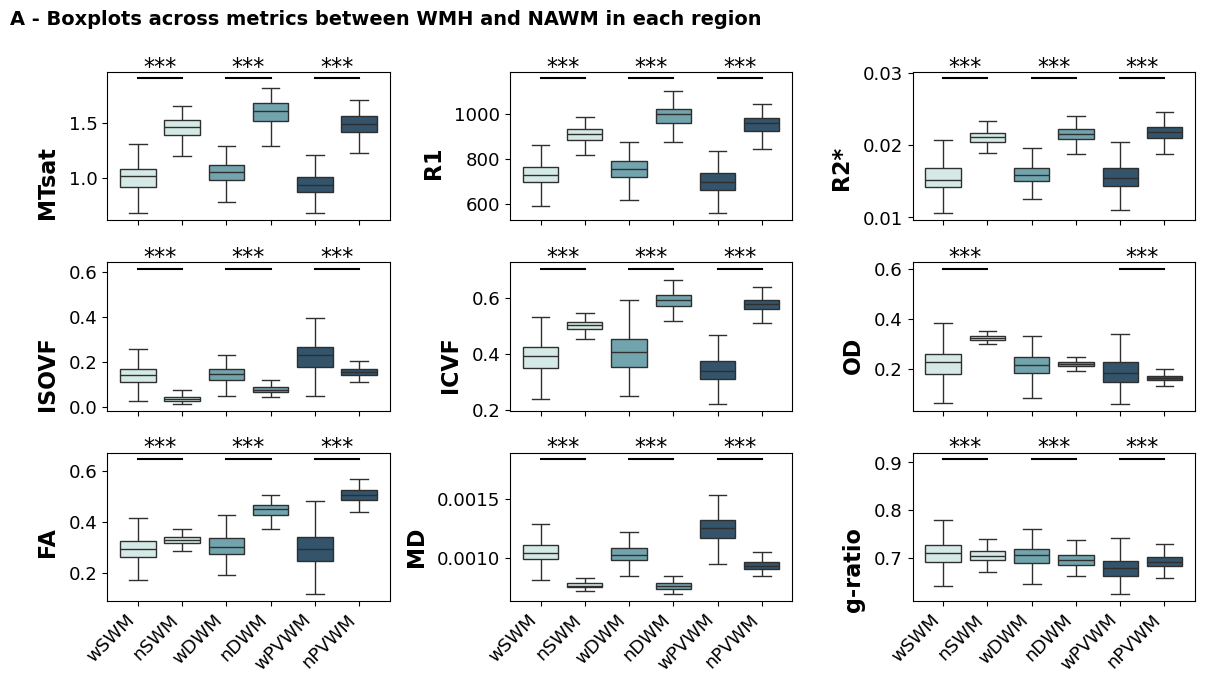

In [54]:
import os
import pickle
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def load_checkpoint(filename):
    if os.path.exists(filename):
        try:
            with open(filename, 'rb') as f:
                return pickle.load(f)
        except (pickle.UnpicklingError, EOFError) as e:
            print(f"Error loading checkpoint {filename}: {e}")
            return None
    return None

# Path to the directory where the output dictionaries are saved
batch_folder = '/mnt/HDD1/USERS_DATAS/aurelie/Dictionnaries_cross/'

# Load all mean metric batches
mean_batch_files = glob.glob(os.path.join(batch_folder, 'metrics_cross_sectional_mean*.pkl'))

mean_metrics_data = {
    'WMH_DWM': {},
    'NAWM_DWM': {},
    'WMH_PVWM': {},
    'NAWM_PVWM': {},
    'WMH_SWM': {},
    'NAWM_SWM': {}
}

# Extract mean metrics for each category from each batch
for batch_file in mean_batch_files:
    output_dictionary = load_checkpoint(batch_file)
    if output_dictionary:
        for key in output_dictionary.keys():
            metric = key.replace('Mean_Metrics_In_', '')
            if 'WMH_DWM' in output_dictionary[key]:
                if metric not in mean_metrics_data['WMH_DWM']:
                    mean_metrics_data['WMH_DWM'][metric] = {}
                mean_metrics_data['WMH_DWM'][metric].update(output_dictionary[key]['WMH_DWM'])
            if 'NAWM_DWM' in output_dictionary[key]:
                if metric not in mean_metrics_data['NAWM_DWM']:
                    mean_metrics_data['NAWM_DWM'][metric] = {}
                mean_metrics_data['NAWM_DWM'][metric].update(output_dictionary[key]['NAWM_DWM'])
            if 'WMH_PVWM' in output_dictionary[key]:
                if metric not in mean_metrics_data['WMH_PVWM']:
                    mean_metrics_data['WMH_PVWM'][metric] = {}
                mean_metrics_data['WMH_PVWM'][metric].update(output_dictionary[key]['WMH_PVWM'])
            if 'NAWM_PVWM' in output_dictionary[key]:
                if metric not in mean_metrics_data['NAWM_PVWM']:
                    mean_metrics_data['NAWM_PVWM'][metric] = {}
                mean_metrics_data['NAWM_PVWM'][metric].update(output_dictionary[key]['NAWM_PVWM'])
            if 'WMH_SWM' in output_dictionary[key]:
                if metric not in mean_metrics_data['WMH_SWM']:
                    mean_metrics_data['WMH_SWM'][metric] = {}
                mean_metrics_data['WMH_SWM'][metric].update(output_dictionary[key]['WMH_SWM'])
            if 'NAWM_SWM' in output_dictionary[key]:
                if metric not in mean_metrics_data['NAWM_SWM']:
                    mean_metrics_data['NAWM_SWM'][metric] = {}
                mean_metrics_data['NAWM_SWM'][metric].update(output_dictionary[key]['NAWM_SWM'])

# Define metrics to plot
metrics_to_plot = list(mean_metrics_data['WMH_DWM'].keys())

y_axis_captions = ['MTsat', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']  # Customize these captions as needed


# Define pairwise comparisons
comparisons_to_make = [
    ('wSWM', 'nSWM'), 
    ('wDWM', 'nDWM'), 
    ('wPVWM', 'nPVWM')
]

# Check if there are any metrics to plot
if not metrics_to_plot:
    print("No metrics to plot.")
else:
    # Plotting settings
    num_metrics = len(metrics_to_plot)
    rows = (num_metrics + 2) // 3  # Calculate number of rows needed
    if rows == 0:
        rows = 1
    fig, axes = plt.subplots(rows, 3, figsize=(12, 2 * rows), sharey=False, sharex=True)

    # Flatten axes to handle cases where there are fewer than 3 metrics
    axes = axes.flatten()

    # Define color palette with provided colors
    custom_palette = {
        'wDWM': '#68abb8',  # Medium Teal
        'nDWM': '#68abb8',  # Medium Teal
        'wPVWM':'#2a5674',   # Dark Teal
        'nPVWM': '#2a5674',   # Dark Teal
        'wSWM':  '#d1eeea',  # Light Teal
        'nSWM': '#d1eeea',  # Light Teal
    }

    def add_stat_annotation(ax, x1, x2, y, text):
        ax.plot([x1, x2], [y, y], lw=1.5, color='black')
        ax.text((x1 + x2) * 0.5, y, text, ha='center', va='bottom', color='black', fontsize=16)

    # Define the exact order of the groups on the x-axis
    group_order = ['wSWM', 'nSWM', 'wDWM', 'nDWM', 'wPVWM', 'nPVWM']

    # Loop through metrics and create boxplots
    for i, (metric, caption) in enumerate(zip(metrics_to_plot[:rows*3], y_axis_captions)):  # Only plot the first 12 metrics

        ax = axes[i]
        
        # Gather data for current metric
        metric_data = {
            'wSWM': np.array(list(mean_metrics_data['WMH_SWM'][metric].values())),
            'nSWM': np.array(list(mean_metrics_data['NAWM_SWM'][metric].values())),
            'wDWM': np.array(list(mean_metrics_data['WMH_DWM'][metric].values())),
            'nDWM': np.array(list(mean_metrics_data['NAWM_DWM'][metric].values())),
            'wPVWM': np.array(list(mean_metrics_data['WMH_PVWM'][metric].values())),
            'nPVWM': np.array(list(mean_metrics_data['NAWM_PVWM'][metric].values()))
        }
        
        # Remove NaN values from each group
        for key in metric_data:
            metric_data[key] = metric_data[key][~np.isnan(metric_data[key])]
        
        # Prepare data for boxplot (ensure order SWM, DWM, PVWM)
        data = pd.DataFrame({
            'Metric': np.concatenate([metric_data[group] for group in group_order]),
            'Group': np.concatenate([[group] * len(metric_data[group]) for group in group_order])
        })
        
        # Plot boxplot with individual data points
        sns.boxplot(x='Group', y='Metric', data=data, ax=ax, hue='Group', palette=custom_palette, dodge=False, showfliers=False, legend=False)

        # Remove background horizontal grid lines
        ax.yaxis.grid(False)
        
        # Perform pairwise statistical tests
        p_values = []
        for group1, group2 in comparisons_to_make:
            if len(metric_data[group1]) > 0 and len(metric_data[group2]) > 0:
                _, p_value = mannwhitneyu(metric_data[group1], metric_data[group2])
                p_values.append(p_value)
            else:
                p_values.append(1)  # If either group is empty, set p-value to 1 (no significance)

        # FDR correction
        _, corrected_p_values, _, _ = multipletests(p_values, method='fdr_bh')
        print(corrected_p_values)
        # Annotate plot with significance levels
        y_max = data['Metric'].max() * 1.05
        for (group1, group2), p_value in zip(comparisons_to_make, corrected_p_values):
            group1_idx = group_order.index(group1)
            group2_idx = group_order.index(group2)
            if p_value < 0.001:
                add_stat_annotation(ax, group1_idx, group2_idx, y_max, '***')
            elif p_value < 0.01:
                add_stat_annotation(ax, group1_idx, group2_idx, y_max, '**')
            elif p_value < 0.05:
                add_stat_annotation(ax, group1_idx, group2_idx, y_max, '*')
            #y_max += 0.05 * y_max  # Increment y position for next annotation

        # Set y-axis title to metric name and increase font size
        ax.set_ylabel(caption, fontsize=16, labelpad=15, fontweight='bold', verticalalignment='center', horizontalalignment='right') 
        #ax.set_yticklabels(fontsize=14)
        ax.tick_params(axis='y', labelsize=13)
        # Remove plot title
        ax.set_title('')
        
        # Remove x-axis label for better layout
        ax.set_xlabel('')

    # Remove extra subplots if there are any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Adjust layout and display the plot
    plt.tight_layout()

    # Rotate X-axis labels for the bottom row only
    for ax in axes[-3:]:  # Last 3 axes (bottom row)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=13)
        
    # Add a title to the entire plot (aligned to top-left with boxplots)
    plt.suptitle('A - Boxplots across metrics between WMH and NAWM in each region', fontsize=14, fontweight='bold', y=1.05, ha='left', x=0)

    # Save the plot
    plot_path = os.path.join(notebook_dir, f'Figures/Boxplot_WMH_NAWM_PVWM_DWM_SWM_cross_sectionnal.png')
    plt.savefig(plot_path, bbox_inches='tight')

    # Show the plot
    plt.show()


## Effect size barplot SWM DWM PVWM

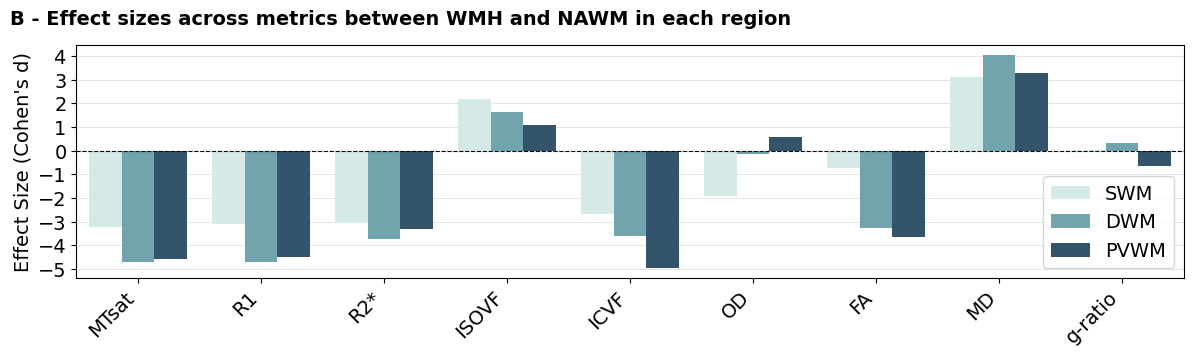

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import math

# Function to calculate Cohen's d (Effect Size) for paired data
def cohen_d(w_data, n_data):
    """Calculate Cohen's d for paired data."""
    mean_diff = np.mean(w_data) - np.mean(n_data)
    pooled_std = math.sqrt(((len(w_data) - 1) * np.std(w_data, ddof=1)**2 + (len(n_data) - 1) * np.std(n_data, ddof=1)**2) / (len(w_data) + len(n_data) - 2))
    return mean_diff / pooled_std

# Placeholder for the mean_metrics_data and metrics_to_plot
metrics_to_plot = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']  # Example metrics

# Store the effect sizes in a DataFrame
effect_sizes = pd.DataFrame(index=metrics_to_plot, columns=['DWM', 'PVWM', 'SWM'])

# Loop through the metrics
for metric in metrics_to_plot:
    metric_data = {
        'wSWM': np.array(list(mean_metrics_data['WMH_SWM'][metric].values())),
        'nSWM': np.array(list(mean_metrics_data['NAWM_SWM'][metric].values())),
        'wDWM': np.array(list(mean_metrics_data['WMH_DWM'][metric].values())),
        'nDWM': np.array(list(mean_metrics_data['NAWM_DWM'][metric].values())),
        'wPVWM': np.array(list(mean_metrics_data['WMH_PVWM'][metric].values())),
        'nPVWM': np.array(list(mean_metrics_data['NAWM_PVWM'][metric].values()))
       
    }

    # Calculate the effect size for each region
    for region in ['SWM', 'DWM','PVWM']:
        w_data = metric_data[f'w{region}']
        n_data = metric_data[f'n{region}']

        # Exclude NaN values and their corresponding pairs
        valid_indices = ~np.isnan(w_data) & ~np.isnan(n_data)
        w_data_filtered = w_data[valid_indices]
        n_data_filtered = n_data[valid_indices]

        if len(w_data_filtered) > 2:  # Ensure there are enough valid data points
            effect_sizes.loc[metric, region] = cohen_d(w_data_filtered, n_data_filtered)
        else:
            effect_sizes.loc[metric, region] = np.nan

# Function to create a grouped bar plot
def create_grouped_bar_plot(data, title, metric_names):
    """
    Creates a grouped bar plot showing the effect sizes for each metric and region.
    
    Args:
        data (pd.DataFrame): DataFrame with effect sizes for metrics and regions.
        title (str): Title of the plot.
        metric_names (list): List of custom metric names to use on the x-axis.
    """
    # Melt the DataFrame to a long format for easier plotting with Seaborn
    data_melted = data.reset_index().melt(id_vars='index', var_name='Region', value_name='Effect Size')
    data_melted.rename(columns={'index': 'Metric'}, inplace=True)

    # Specify the desired order for the regions
    region_order = ['SWM', 'DWM', 'PVWM']

    # Define the Teal color palette
    custom_palette = {
        'SWM': '#d1eeea',  # Dark Teal
        'DWM': '#68abb8',  # Medium Teal
        'PVWM': '#2a5674'  # Light Teal
    }

    # Set up the plot
    plt.figure(figsize=(12, 3.7))
    
    # Create the bar plot with a higher zorder to make sure the bars are in front
    sns.barplot(
        data=data_melted,
        x='Metric',
        y='Effect Size',
        hue='Region',
        hue_order=region_order,  # Set the custom order for the regions
        palette=custom_palette,  # Apply the custom Teal color palette
        zorder=2  # Make sure the bars are on top
    )

    # Customize the appearance
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--', zorder=3)  # Add a horizontal line at zero

    # Add the title and labels
    plt.title(title, fontsize=14, fontweight='bold', ha='left', x=-0.06, y=1.05)  # Align title to the left
    plt.xlabel('', fontsize=14, fontweight='bold')
    plt.ylabel('Effect Size (Cohen\'s d)', fontsize=14)

    # Use the custom metric names for x-tick labels
    plt.xticks(ticks=range(len(metric_names)), labels=metric_names, rotation=45, fontsize=14, ha='right')

    # Set the y-tick font size and position the y-ticks
    plt.yticks(fontsize=14)

    # Set the y-axis ticks manually if needed
    plt.yticks(np.arange(-5, 5, step=1))  # Adjust step size as necessary

    # Add horizontal grid lines behind the bars by setting zorder=-1, and make the grid lines lighter
    plt.grid(True, axis='y', zorder=-1, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)  # Lighter grid lines

    # Increase font size for the legend
    plt.legend(fontsize=14, loc='lower right', bbox_to_anchor=(1, 0))  # Increased font size

    # Adjust layout to avoid overlap
    plt.tight_layout()

    # Save the figure
    plt.savefig(os.path.join(notebook_dir, f'Figures/Effect_size_WMH_NAWM_PVWM_DWM_SWM_cross_sectionnal.png'), dpi=300)

    # Show the plot
    plt.show()

# Example usage:
# Assume effect_sizes is your DataFrame with the data you want to plot
# Replace this with your actual data
# effect_sizes = pd.DataFrame(...)

# List of custom metric names for the x-axis
metric_names = ['MTsat', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

# Example usage:
create_grouped_bar_plot(effect_sizes, "B - Effect sizes across metrics between WMH and NAWM in each region", metric_names)


## Radar plots SWM DWM PVWM

/tmp/ipykernel_370962/313116115.py:58: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data = data.append(data.iloc[0])


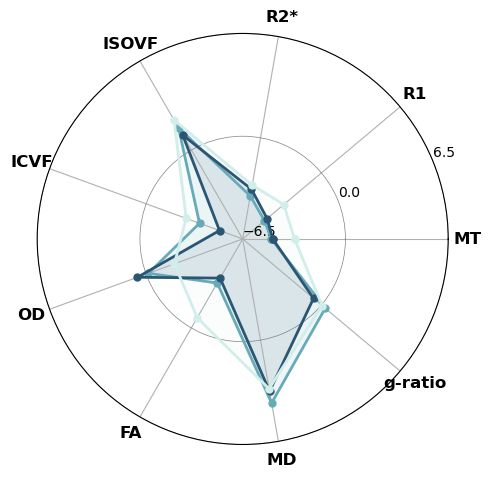

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math

# Function to calculate Cohen's d (Effect Size) for paired data
def cohen_d(w_data, n_data):
    """Calculate Cohen's d for paired data."""
    mean_diff = np.mean(w_data) - np.mean(n_data)
    pooled_std = math.sqrt(((len(w_data) - 1) * np.std(w_data, ddof=1)**2 + (len(n_data) - 1) * np.std(n_data, ddof=1)**2) / (len(w_data) + len(n_data) - 2))
    return mean_diff / pooled_std

# Placeholder for the mean_metrics_data and metrics_to_plot
metrics_to_plot = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']  # Example metrics

# Store the effect sizes in a DataFrame
effect_sizes = pd.DataFrame(index=metrics_to_plot, columns=['DWM', 'PVWM', 'SWM'])

# Loop through the metrics
for metric in metrics_to_plot:
    metric_data = {
        'wSWM': np.array(list(mean_metrics_data['WMH_SWM'][metric].values())),
        'nSWM': np.array(list(mean_metrics_data['NAWM_SWM'][metric].values())),
        'wDWM': np.array(list(mean_metrics_data['WMH_DWM'][metric].values())),
        'nDWM': np.array(list(mean_metrics_data['NAWM_DWM'][metric].values())),
        'wPVWM': np.array(list(mean_metrics_data['WMH_PVWM'][metric].values())),
        'nPVWM': np.array(list(mean_metrics_data['NAWM_PVWM'][metric].values()))
       
    }

    # Calculate the effect size for each region
    for region in ['SWM', 'DWM','PVWM']:
        w_data = metric_data[f'w{region}']
        n_data = metric_data[f'n{region}']

        # Exclude NaN values and their corresponding pairs
        valid_indices = ~np.isnan(w_data) & ~np.isnan(n_data)
        w_data_filtered = w_data[valid_indices]
        n_data_filtered = n_data[valid_indices]

        if len(w_data_filtered) > 2:  # Ensure there are enough valid data points
            effect_sizes.loc[metric, region] = cohen_d(w_data_filtered, n_data_filtered)
        else:
            effect_sizes.loc[metric, region] = np.nan

# Function to create radar plot (spider plot) based on effect sizes
def create_spider_plot(data, title):
    # Number of variables (metrics)
    labels = data.index
    num_vars = len(labels)

    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # Repeat the first point to close the circle
    angles += angles[:1]
    data = data.append(data.iloc[0])

    # Map regions to the colors in the palette
    colors = {'DWM': '#68abb8', 'PVWM': '#2a5674', 'SWM': '#d1eeea'}

    # Create the plot with a smaller figure size* 
    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))  # Adjusted size

    for region in data.columns:
        values = data[region].values
        ax.plot(angles, values, label=region, linewidth=2, color=colors[region], marker='o', markersize=5)
        ax.fill(angles, values, alpha=0.1, color=colors[region])  # Add transparency for the fills

    # Customize gridlines and yticks
    ax.set_yticks([-6.5, 0, 6.5])  # Only show -2, 0, and 2 circles
    ax.yaxis.grid(True, color='lightgray', linewidth=0.5)

    gridlines = ax.yaxis.get_gridlines()
    for line in gridlines:
        y_value = line.get_ydata()[0]
        if np.isclose(y_value, 0):
            line.set_linewidth(0.5)  # Make the 0-circle bolder
            line.set_color('gray')
        else:
            line.set_visible(False)  # Hide other gridlines

    # Add labels and title
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')  # Reduced font size for title
    
    # Save the figure to a file
    plt.tight_layout()
    plt.savefig(os.path.join(notebook_dir, f'Figures/Radar_plot_WMH_NAWM_PVWM_DWM_SWM_cross_sectionnal.png'), dpi=300)

    # Show plot
    plt.show()

# Call the function with normalized effect sizes
create_spider_plot(effect_sizes, "")


/tmp/ipykernel_370962/1372616206.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data_swm = data_swm.append(data_swm.iloc[0])


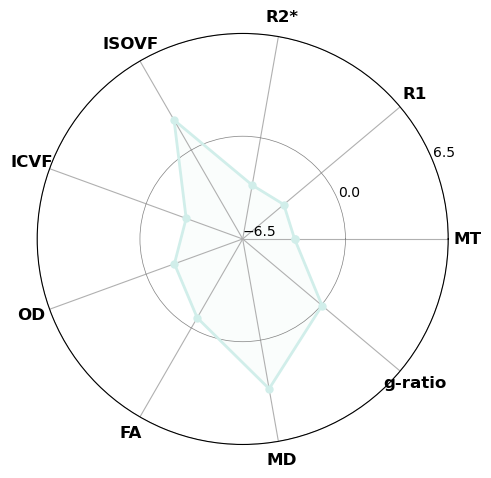

In [58]:
# Function to create radar plot (spider plot) based on effect sizes, modified to plot only SWM
def create_spider_plot(data, title):
    # Filter to include only SWM region
    data_swm = data[['SWM']]

    # Number of variables (metrics)
    labels = data_swm.index
    num_vars = len(labels)

    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # Repeat the first point to close the circle
    angles += angles[:1]
    data_swm = data_swm.append(data_swm.iloc[0])

    # Get the colorblind palette from Seaborn
    colors = {'SWM': '#d1eeea'}

    # Create the plot with a smaller figure size
    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))  # Adjusted size

    # Plot only SWM region
    values = data_swm['SWM'].values
    ax.plot(angles, values, label='SWM', linewidth=2, color=colors['SWM'], marker='o', markersize=5)
    ax.fill(angles, values, alpha=0.1, color=colors['SWM'])  # Add transparency for the fills

    # Customize gridlines and yticks
    ax.set_yticks([-6.5, 0, 6.5])  # Only show -2, 0, and 2 circles
    ax.yaxis.grid(True, color='lightgray', linewidth=0.5)

    gridlines = ax.yaxis.get_gridlines()
    for line in gridlines:
        y_value = line.get_ydata()[0]
        if np.isclose(y_value, 0):
            line.set_linewidth(0.5)  # Make the 0-circle bolder
            line.set_color('gray')
        else:
            line.set_visible(False)  # Hide other gridlines

    # Add labels and title
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')  # Reduced font size for title
    
    # Save the figure to a file
    plt.tight_layout()
    plt.savefig(os.path.join(notebook_dir, f'Figures/Radar_plot_WMH_NAWM_SWM_cross_sectionnal.png'), dpi=300)

    # Show plot
    plt.show()

# Call the function with the filtered effect sizes for SWM
create_spider_plot(effect_sizes, "")


/tmp/ipykernel_370962/3328604104.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data_swm_dwm = data_swm_dwm.append(data_swm_dwm.iloc[0])


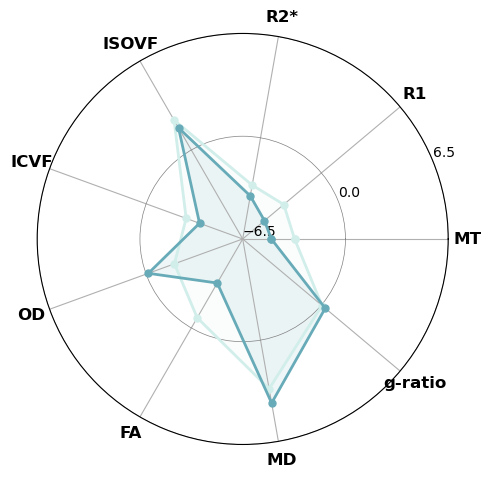

In [59]:
# Function to create radar plot (spider plot) based on effect sizes, modified to plot SWM and DWM
def create_spider_plot(data, title):
    # Filter to include only SWM and DWM regions
    data_swm_dwm = data[['SWM', 'DWM']]

    # Number of variables (metrics)
    labels = data_swm_dwm.index
    num_vars = len(labels)

    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # Repeat the first point to close the circle
    angles += angles[:1]
    data_swm_dwm = data_swm_dwm.append(data_swm_dwm.iloc[0])

    # Get the colorblind palette 
    colors = {'DWM': '#68abb8','SWM': '#d1eeea'}

    # Create the plot with a smaller figure size
    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))  # Adjusted size

    # Plot SWM and DWM regions
    for region in data_swm_dwm.columns:
        values = data_swm_dwm[region].values
        ax.plot(angles, values, label=region, linewidth=2, color=colors[region], marker='o', markersize=5)
        ax.fill(angles, values, alpha=0.1, color=colors[region])  # Add transparency for the fills

    # Customize gridlines and yticks
    ax.set_yticks([-6.5, 0, 6.5])  # Only show -3, 0, and 3 circles
    ax.yaxis.grid(True, color='lightgray', linewidth=0.5)

    gridlines = ax.yaxis.get_gridlines()
    for line in gridlines:
        y_value = line.get_ydata()[0]
        if np.isclose(y_value, 0):
            line.set_linewidth(0.5)  # Make the 0-circle bolder
            line.set_color('gray')
        else:
            line.set_visible(False)  # Hide other gridlines

    # Add labels and title
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')  # Reduced font size for title
    
    # Save the figure to a file
    plt.tight_layout()
    plt.savefig(os.path.join(notebook_dir, f'Figures/Radar_plot_WMH_NAWM_SWM_DWM_cross_sectionnal.png'), dpi=300)

    # Show plot
    plt.show()

# Call the function with the filtered effect sizes for SWM and DWM
create_spider_plot(effect_sizes, "")


## Boxplots layers 

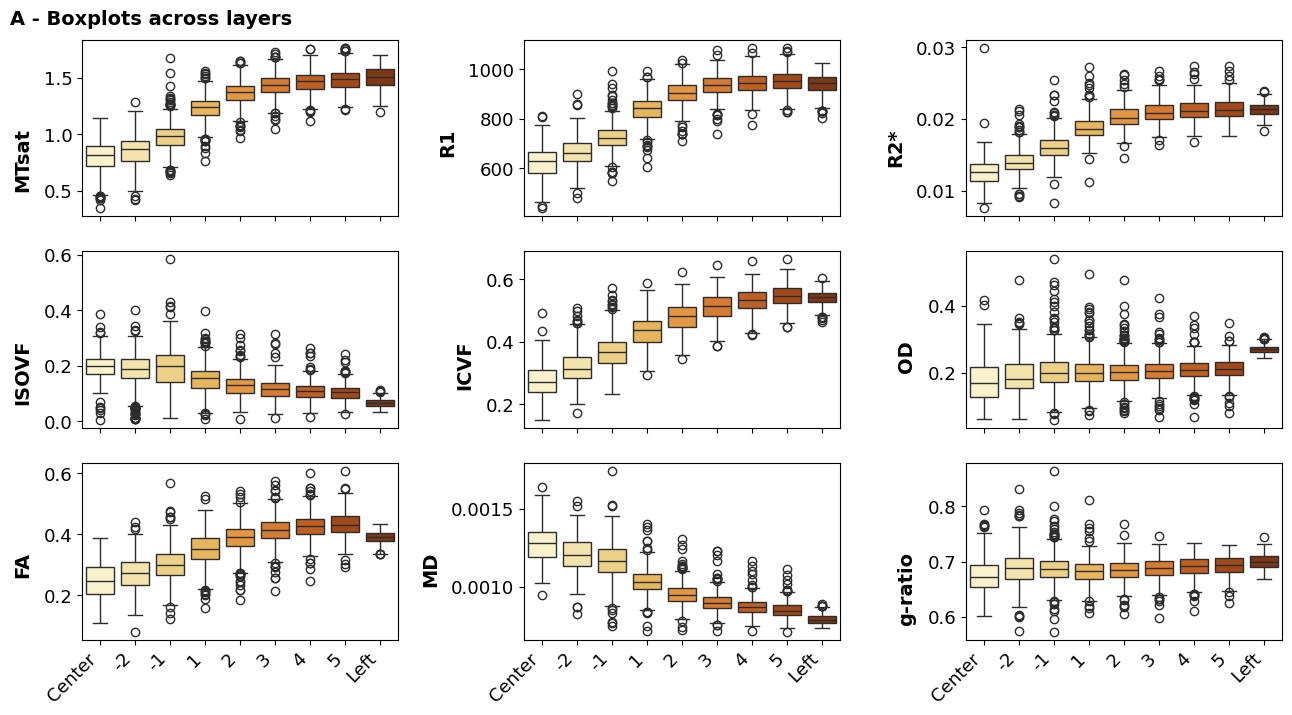

In [60]:
import os
import pickle
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def load_checkpoint(filename):
    if os.path.exists(filename):
        try:
            with open(filename, 'rb') as f:
                return pickle.load(f)
        except (pickle.UnpicklingError, EOFError) as e:
            print(f"Error loading NIfTI file {file_path}: {e}")
            return None
    return None

# Path to the directory where the output dictionaries are saved
batch_folder = '/mnt/HDD1/USERS_DATAS/aurelie/Dictionnaries_cross/'

# Load all mean metric batches
mean_batch_files = glob.glob(os.path.join(batch_folder, 'metrics_cross_sectional_mean*.pkl'))

mean_metrics_data = {}

# Extract mean metrics from each batch
for batch_file in mean_batch_files:
    output_dictionary = load_checkpoint(batch_file)
    if output_dictionary:
        for metric, masks in output_dictionary.items():
            if metric not in mean_metrics_data:
                mean_metrics_data[metric] = {}
            for mask, values in masks.items():
                if mask not in mean_metrics_data[metric]:
                    mean_metrics_data[metric][mask] = {}
                mean_metrics_data[metric][mask].update(values)

# Define metrics to plot and corresponding captions
metrics_to_plot = list(mean_metrics_data.keys())
y_axis_captions = ['MTsat', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']  # Customize these captions as needed

# Define groups to plot
groups_to_plot = {
    'Center': 'WMH_center',
    '-2': 'InnerLayer2',
    '-1': 'InnerLayer1',
    '1': 'Layer1',
    '2': 'Layer2',
    '3': 'Layer3',
    '4': 'Layer4',
    '5': 'Layer5',
    'Left': 'WM_left'
}

def add_stat_annotation(ax, x1, x2, y, text):
    ax.plot([x1, x2], [y, y], lw=1.5, color='black')
    ax.text((x1 + x2) * 0.5, y, text, ha='center', va='bottom', color='black', fontsize=16)

# Ensure that custom_palette has colors for all groups
custom_palette = dict(zip(groups_to_plot.keys(), sns.color_palette('YlOrBr', n_colors=len(groups_to_plot))))

# Plotting settings
num_metrics = len(metrics_to_plot)
rows = min((num_metrics + 2) // 3, 4)  # Limit rows to 4 to prevent image size issues
fig, axes = plt.subplots(rows, 3, figsize=(12, 2 * rows), sharey=False, sharex=True)

# Flatten axes to handle cases where there are fewer than 3 metrics
axes = axes.flatten()

# Loop through metrics and create boxplots
for i, (metric, caption) in enumerate(zip(metrics_to_plot[:rows*3], y_axis_captions)):  # Only plot the first 12 metrics
    ax = axes[i]

    # Gather data for current metric
    data_list = []
    for group_label, mask in groups_to_plot.items():
        if mask in mean_metrics_data[metric]:
            group_values = list(mean_metrics_data[metric][mask].values())
            group_values = [value for value in group_values if not np.isnan(value)]  # Remove NaN values
            if group_values:  # Ensure the list is not empty
                df = pd.DataFrame({'Metric': group_values, 'Group': [group_label] * len(group_values)})
                data_list.append(df)

    if data_list:
        data = pd.concat(data_list, ignore_index=True)  # Ensure unique indices
        
        # Plot boxplot with individual data points
        sns.boxplot(x='Group', y='Metric', data=data, ax=ax, hue='Group', palette=custom_palette, dodge=False, legend=False)
        
        # Plot individual data points (optional, can be uncommented if needed)
        #sns.stripplot(x='Group', y='Metric', data=data, ax=ax, color='black', alpha=0.3, jitter=True, size=4)
    
        # Statistical comparisons: compare each group to 'Left'
        comparison_pvals = []
        comparison_labels = []
        for group_label in groups_to_plot:
            if group_label != 'Left' and group_label in data['Group'].values:
                group_data = data.loc[data['Group'] == group_label, 'Metric']
                left_data = data.loc[data['Group'] == 'Left', 'Metric']
                if len(group_data) > 0 and len(left_data) > 0:
                    _, p_val = mannwhitneyu(group_data, left_data, alternative='two-sided')
                    comparison_pvals.append(p_val)
                    comparison_labels.append((group_label, 'Left'))
                else:
                    comparison_pvals.append(np.nan)
                    comparison_labels.append((group_label, 'Left'))

        # Correct p-values for multiple testing using FDR correction
        if comparison_pvals:
            corrected_pvals = multipletests(comparison_pvals, method='fdr_bh')[1]
            # Filter out NaN p-values to avoid unnecessary plotting
            filtered_pvals = [(p, label) for p, label in zip(corrected_pvals, comparison_labels) if not np.isnan(p)]
            
        # Set y-axis title to the custom caption with consistent axis font size and formatting
        ax.set_ylabel(caption, fontsize=14, labelpad=15, fontweight='bold', verticalalignment='center', horizontalalignment='right') 

        # Remove plot title
        ax.set_title('')
        ax.get_yaxis().grid(False)
        
        # Remove x-axis label for better layout
        ax.set_xlabel('')
        ax.tick_params(axis='y', labelsize=13)

        # Set y-limits to give more space above the boxplots for the lines and asterisks
        # Rotate X-axis labels for the bottom row only
        for ax in axes[-3:]:  # Last 3 axes (bottom row)
            ax.set_xticks(np.arange(len(ax.get_xticklabels())))  # Set tick positions
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',fontsize=13)


# Remove extra subplots if there are any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout manually to avoid the tight_layout warning
plt.subplots_adjust(top=1, bottom=0, left=0, right=1, hspace=0.2, wspace=0.4)

plt.suptitle('A - Boxplots across layers', fontsize=14, fontweight='bold', y=1.05, ha='left', x=-0.06)

# Save the plot
plot_path = os.path.join(notebook_dir, f'Figures/Boxplot_layers_cross_sectionnal.png')  # Change this to your desired path
plt.savefig(plot_path, bbox_inches='tight', dpi=300)

# Show the plot
plt.show()


## Effect size layers

In [108]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Helper function to calculate Cohen's d
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    mean1, mean2 = np.mean(x), np.mean(y)
    var1, var2 = np.var(x, ddof=1), np.var(y, ddof=1)
    sd_pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (mean1 - mean2) / sd_pooled if sd_pooled != 0 else np.nan  # Layer vs WM_left

# List of specific metrics you want to compare
metrics_to_plot = ['Mean_Metrics_In_MT', 'Mean_Metrics_In_R1', 'Mean_Metrics_In_R2*', 'Mean_Metrics_In_ISOVF', 
                   'Mean_Metrics_In_ICVF', 'Mean_Metrics_In_OD', 'Mean_Metrics_In_FA', 'Mean_Metrics_In_MD', 
                   'Mean_Metrics_In_g-ratio']

# Clean the combined_mean_metrics_data_cross_sectionnal to keep only the first value per PR (if there are multiple)
for metric in combined_mean_metrics_data_cross_sectionnal:
    for label in combined_mean_metrics_data_cross_sectionnal[metric]:
        for pr, values in combined_mean_metrics_data_cross_sectionnal[metric][label].items():
            if isinstance(values, list) and len(values) > 1:
                combined_mean_metrics_data_cross_sectionnal[metric][label][pr] = [values[0]]

# Initialize dictionary to store results in table format
results = {}

# Loop through each specified metric
for metric in metrics_to_plot:
    if metric in combined_mean_metrics_data_cross_sectionnal:
        # Extract the reference data (WM_Left)
        wm_left_data = np.array(list(combined_mean_metrics_data_cross_sectionnal[metric]['WM_left'].values()))
        wm_left_data = wm_left_data[~np.isnan(wm_left_data)]  # Remove NaNs

        # Prepare lists for p-values, Cohen's d, and comparison labels
        p_values = []
        cohen_d_values = []
        comparison_labels = []

        # Loop through each group and compare it to 'WM_left'
        for label, mask in groups_to_plot.items():
            if label != 'Left' and mask in combined_mean_metrics_data_cross_sectionnal[metric]:
                layer_data = np.array(list(combined_mean_metrics_data_cross_sectionnal[metric][mask].values()))
                layer_data = layer_data[~np.isnan(layer_data)]  # Remove NaNs

                # Perform statistical test if data is available
                if len(wm_left_data) > 0 and len(layer_data) > 0:
                    # Here, Layer is compared to WM_left (Layer vs WM_left)
                    _, p_value = mannwhitneyu(layer_data, wm_left_data, alternative='two-sided')  # Test direction
                    d_value = cohen_d(layer_data, wm_left_data)  # Cohen's d for Layer vs WM_left
                    p_values.append(p_value)
                    cohen_d_values.append(d_value)
                    comparison_labels.append(f"{label} vs WM_left")  # Update labels to match Layer vs WM_left
                else:
                    p_values.append(np.nan)
                    cohen_d_values.append(np.nan)
                    comparison_labels.append(f"{label} vs WM_left")

        # Apply FDR correction for multiple comparisons
        if p_values:
            _, q_values, _, _ = multipletests(p_values, method='fdr_bh')

            # Store results in dictionary, where each metric is a row
            results[metric] = {
                label: ("{:.2e}".format(d), "{:.2e}".format(q)) 
                for label, d, q in zip(comparison_labels, cohen_d_values, q_values)
            }

# Convert results dictionary to DataFrame
results_df = pd.DataFrame(results).T

# Rename the columns to indicate metrics more clearly
results_df.columns = [f"{label.split('vs')[0].strip()} vs WM_left (Cohen's d, Q-value)" for label in results_df.columns]

# Display the formatted results and save to CSV
#results_df.to_csv('/mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/Analyses/stat_comparison_table_cohen_d_vs_WM_left_cross_sectionnal.csv')
results_df


,"Center vs WM_left (Cohen's d, Q-value)","-2 vs WM_left (Cohen's d, Q-value)","-1 vs WM_left (Cohen's d, Q-value)","1 vs WM_left (Cohen's d, Q-value)","2 vs WM_left (Cohen's d, Q-value)","3 vs WM_left (Cohen's d, Q-value)","4 vs WM_left (Cohen's d, Q-value)","5 vs WM_left (Cohen's d, Q-value)"
Mean_Metrics_In_MT,"(-6.02e+00, 4.43e-83)","(-5.55e+00, 1.55e-121)","(-4.62e+00, 6.52e-133)","(-2.53e+00, 3.75e-117)","(-1.28e+00, 1.29e-55)","(-6.22e-01, 1.69e-18)","(-2.97e-01, 1.71e-06)","(-1.20e-01, 1.20e-02)"
Mean_Metrics_In_R1,"(-6.24e+00, 4.52e-83)","(-5.68e+00, 3.43e-121)","(-4.47e+00, 1.23e-132)","(-2.11e+00, 3.90e-102)","(-7.97e-01, 7.35e-28)","(-1.35e-01, 1.61e-02)","(1.69e-01, 7.91e-02)","(3.20e-01, 1.36e-04)"
Mean_Metrics_In_R2*,"(-6.26e+00, 3.41e-81)","(-5.49e+00, 9.55e-120)","(-3.67e+00, 1.60e-128)","(-1.89e+00, 1.94e-94)","(-8.37e-01, 1.27e-32)","(-2.76e-01, 5.93e-07)","(-3.34e-02, 1.09e-01)","(4.76e-02, 5.65e-01)"
Mean_Metrics_In_ISOVF,"(4.16e+00, 8.65e-72)","(2.62e+00, 2.03e-84)","(2.21e+00, 2.32e-91)","(2.11e+00, 2.32e-91)","(1.95e+00, 3.34e-89)","(1.78e+00, 2.03e-84)","(1.69e+00, 1.60e-79)","(1.62e+00, 1.40e-74)"
Mean_Metrics_In_ICVF,"(-7.73e+00, 4.81e-81)","(-5.57e+00, 2.79e-119)","(-4.20e+00, 3.58e-129)","(-2.90e+00, 6.71e-123)","(-1.78e+00, 1.90e-86)","(-8.95e-01, 6.61e-28)","(-2.60e-01, 2.39e-03)","(1.82e-01, 8.09e-03)"
Mean_Metrics_In_OD,"(-2.55e+00, 7.18e-56)","(-2.14e+00, 1.74e-80)","(-1.51e+00, 1.15e-82)","(-1.85e+00, 5.69e-95)","(-2.04e+00, 4.61e-98)","(-2.25e+00, 4.00e-105)","(-2.45e+00, 4.46e-113)","(-2.54e+00, 8.22e-117)"
Mean_Metrics_In_FA,"(-3.81e+00, 2.04e-72)","(-2.86e+00, 1.22e-96)","(-2.04e+00, 2.89e-91)","(-9.26e-01, 1.05e-33)","(-5.63e-02, 8.52e-01)","(6.13e-01, 1.40e-20)","(1.11e+00, 4.81e-46)","(1.42e+00, 1.47e-63)"
Mean_Metrics_In_MD,"(7.25e+00, 2.06e-75)","(5.43e+00, 3.80e-109)","(4.20e+00, 1.94e-118)","(3.80e+00, 1.94e-118)","(2.99e+00, 1.14e-115)","(2.25e+00, 1.54e-103)","(1.79e+00, 3.35e-84)","(1.46e+00, 1.24e-65)"
Mean_Metrics_In_g-ratio,"(-1.04e+00, 4.36e-23)","(-4.69e-01, 5.50e-11)","(-5.43e-01, 4.07e-19)","(-9.37e-01, 5.19e-37)","(-9.29e-01, 5.80e-33)","(-7.11e-01, 3.62e-19)","(-5.09e-01, 3.48e-10)","(-3.68e-01, 8.19e-06)"


In [109]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# Helper function to calculate Cohen's d
def cohen_d(x, y):
    n1, n2 = len(x), len(y)
    mean1, mean2 = np.mean(x), np.mean(y)
    var1, var2 = np.var(x, ddof=1), np.var(y, ddof=1)
    sd_pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (mean1 - mean2) / sd_pooled if sd_pooled != 0 else np.nan

# List of specific metrics you want to compare
metrics_to_plot = ['Mean_Metrics_In_MT', 'Mean_Metrics_In_R1', 'Mean_Metrics_In_R2*', 'Mean_Metrics_In_ISOVF', 
                   'Mean_Metrics_In_ICVF', 'Mean_Metrics_In_OD', 'Mean_Metrics_In_FA', 'Mean_Metrics_In_MD', 
                   'Mean_Metrics_In_g-ratio']

# Initialize dictionary to store results in table format
results = {}

# Loop through each specified metric
for metric in metrics_to_plot:
    if metric in combined_mean_metrics_data_cross_sectionnal:
        # Extract the reference data (WM_Left)
        wm_left_data = np.array(list(combined_mean_metrics_data_cross_sectionnal[metric]['WM_left'].values()))
        wm_left_data = wm_left_data[~np.isnan(wm_left_data)]  # Remove NaNs

        # Prepare lists for Cohen's d and comparison labels
        cohen_d_values = []
        comparison_labels = []

        # Loop through each group and compare it to 'WM_left'
        for label, mask in groups_to_plot.items():
            if label != 'Left' and mask in combined_mean_metrics_data_cross_sectionnal[metric]:
                layer_data = np.array(list(combined_mean_metrics_data_cross_sectionnal[metric][mask].values()))
                layer_data = layer_data[~np.isnan(layer_data)]  # Remove NaNs

                # Calculate Cohen's d if data is available
                if len(wm_left_data) > 0 and len(layer_data) > 0:
                    # Now we compare Layer vs WM_left, so swap wm_left_data and layer_data
                    d_value = cohen_d(layer_data, wm_left_data)  # Layer vs WM_left
                    cohen_d_values.append(d_value)
                    comparison_labels.append(f"{label} vs WM_left")  # Update label to reflect the correct comparison
                else:
                    cohen_d_values.append(np.nan)
                    comparison_labels.append(f"{label} vs WM_left")

        # Store results in dictionary for the current metric
        results[metric] = {
            label: "{:.2e}".format(d) if not np.isnan(d) else "NaN"
            for label, d in zip(comparison_labels, cohen_d_values)
        }

# Convert results dictionary to DataFrame
results_df = pd.DataFrame(results).T

# Rename the columns to indicate metrics more clearly
# Here we directly assign the valid labels with a format for Cohen's d
valid_layers = ['Center', '-2', '-1', '1', '2', '3', '4', '5']
results_df.columns = [f"{layer}" for layer in valid_layers]

# Display the formatted results
print(results_df)

# Optionally, save the results to a CSV file
results_df.to_csv(os.path.join(notebook_dir, f'CSV/cohen_d_layers_matrix.csv'))


                            Center         -2         -1          1  \
Mean_Metrics_In_MT       -6.02e+00  -5.55e+00  -4.62e+00  -2.53e+00   
Mean_Metrics_In_R1       -6.24e+00  -5.68e+00  -4.47e+00  -2.11e+00   
Mean_Metrics_In_R2*      -6.26e+00  -5.49e+00  -3.67e+00  -1.89e+00   
Mean_Metrics_In_ISOVF     4.16e+00   2.62e+00   2.21e+00   2.11e+00   
Mean_Metrics_In_ICVF     -7.73e+00  -5.57e+00  -4.20e+00  -2.90e+00   
Mean_Metrics_In_OD       -2.55e+00  -2.14e+00  -1.51e+00  -1.85e+00   
Mean_Metrics_In_FA       -3.81e+00  -2.86e+00  -2.04e+00  -9.26e-01   
Mean_Metrics_In_MD        7.25e+00   5.43e+00   4.20e+00   3.80e+00   
Mean_Metrics_In_g-ratio  -1.04e+00  -4.69e-01  -5.43e-01  -9.37e-01   

                                 2          3          4          5  
Mean_Metrics_In_MT       -1.28e+00  -6.22e-01  -2.97e-01  -1.20e-01  
Mean_Metrics_In_R1       -7.97e-01  -1.35e-01   1.69e-01   3.20e-01  
Mean_Metrics_In_R2*      -8.37e-01  -2.76e-01  -3.34e-02   4.76e-02  
Mean_Metr

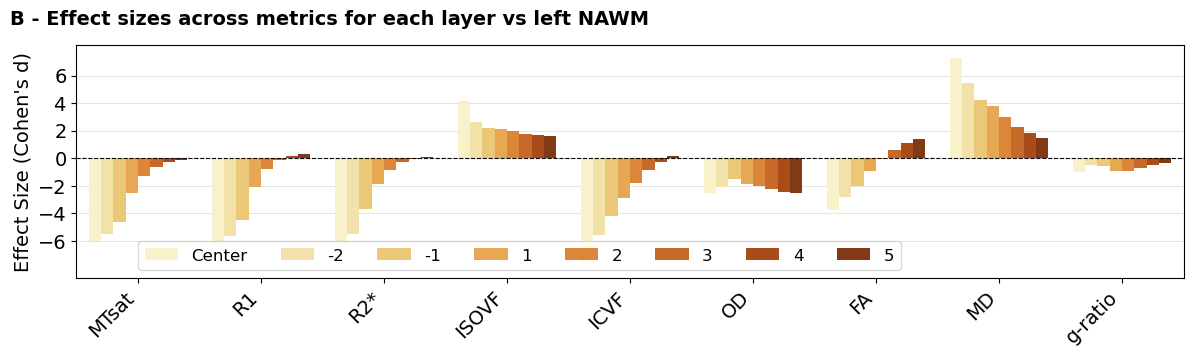

In [79]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def create_grouped_bar_plot_layers(data, title, metric_names):
    """
    Creates a grouped bar plot showing the effect sizes for each metric and layer.
    
    Args:
        data (pd.DataFrame): DataFrame with effect sizes for metrics and layers.
        title (str): Title of the plot.
        metric_names (list): List of custom metric names to use on the x-axis.
    """
    # Reset the index, but we will specify how to treat it to avoid unnamed columns
    data_reset = data.reset_index(drop=False)  # Drop=False keeps the original index as a column

    # Rename the unnamed first column (it will be labeled as 0) to 'Metric'
    data_reset.rename(columns={data_reset.columns[0]: 'Metric'}, inplace=True)

    # Melt the DataFrame to a long format for easier plotting with Seaborn
    data_melted = data_reset.melt(id_vars='Metric', var_name='Layer', value_name='Effect Size')
    # Define the valid layers you want to plot and the order
    valid_layers = ['Center', '-2', '-1', '1', '2', '3', '4', '5']
    order = ['5', '4', '3', '2', '1', '-1', '-2', 'Center']
    order = ['Center', '-2', '-1', '1', '2', '3', '4', '5']

    # Filter out invalid layers from the melted DataFrame
    data_melted = data_melted[data_melted['Layer'].isin(valid_layers)]

    # Ensure the 'Effect Size' column is numeric (float) for continuous scaling
    data_melted['Effect Size'] = pd.to_numeric(data_melted['Effect Size'], errors='coerce')

    # Create a custom color palette to match the valid layers
    layer_palette = sns.color_palette('YlOrBr', len(valid_layers))

    # Map colors to layers based on the valid_layers order
    layer_color_map = {layer: layer_palette[i] for i, layer in enumerate(valid_layers)}

    # Set up the plot
    plt.figure(figsize=(12, 3.7))

    sns.barplot(
        data=data_melted,
        x='Metric',
        y='Effect Size',
        hue='Layer',
        hue_order=order,  # Ensure the layers are plotted in the correct order
        palette=layer_color_map,  # Apply custom color map to layers
        zorder=2
    )

    # Customize the appearance
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--', zorder=3)  # Horizontal line at zero
    plt.title(title, fontsize=14, fontweight='bold', ha='left', x=-0.06, y=1.05)  # Align title to the left with the boxplots
    plt.xlabel('', fontsize=14, fontweight='bold')
    plt.ylabel('Effect Size (Cohen\'s d)', fontsize=14)

    # Use the custom metric names for x-tick labels
    plt.xticks(ticks=range(len(metric_names)), labels=metric_names, rotation=45, fontsize=14, ha='right')

    plt.yticks(fontsize=14)

    # Make sure the y-axis is continuous and has appropriate limits
    plt.ylim(data_melted['Effect Size'].min() - 1, data_melted['Effect Size'].max() + 1)  # Adjust y-axis to fit data

    # Adjust the legend to be horizontal, with each group next to each other
    plt.legend(
        title='', 
        fontsize=12, 
        loc='lower center', 
        bbox_to_anchor=(0.4, 0),  # Move legend outside the plot to be horizontal
        ncol=len(valid_layers),  # Number of columns in the legend (one for each layer)
        frameon=True  # Remove the box around the legend
    )

    # Set the y-axis ticks manually if needed
    plt.yticks(np.arange(-6, 8, step=2))  # Adjust step size as necessary

    # Add horizontal grid lines behind the bars by setting zorder=-1, and make the grid lines lighter
    plt.grid(True, axis='y', zorder=-1, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)  # Lighter grid lines


    # Adjust layout for better appearance
    plt.tight_layout()

    plot_path = os.path.join(notebook_dir, f'Figures/Effect_size_layers_cross_sectionnal.png')  # Change this to your desired path

    # Save the figure
    plt.savefig(plot_path, dpi=300)

    # Show the plot
    plt.show()

# List of custom metric names for the x-axis
metric_names = ['MTsat', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

# Example usage:
create_grouped_bar_plot_layers(results_df, "B - Effect sizes across metrics for each layer vs left NAWM", metric_names)


## Radarplot layers

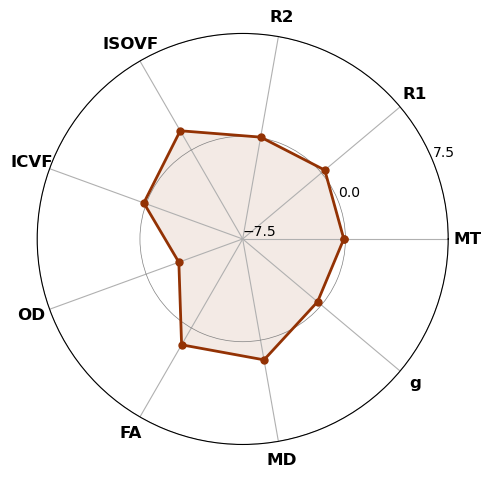

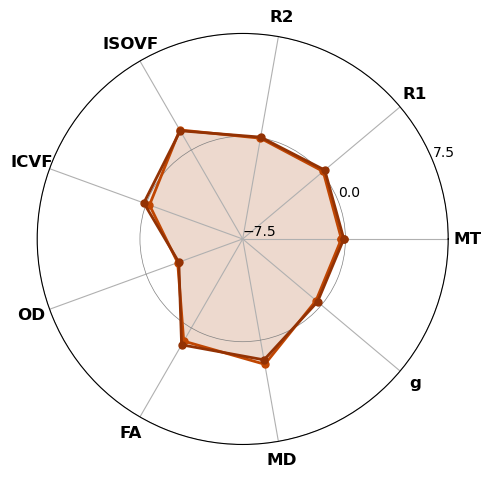

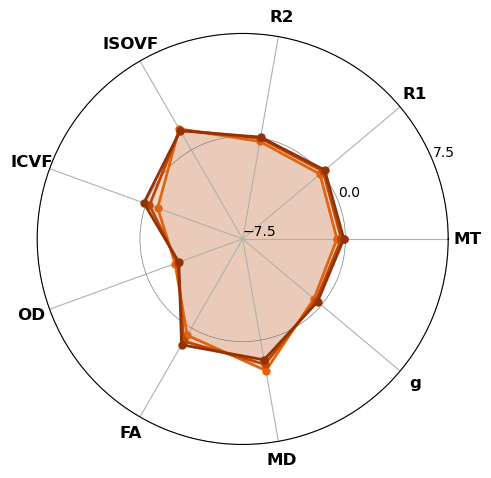

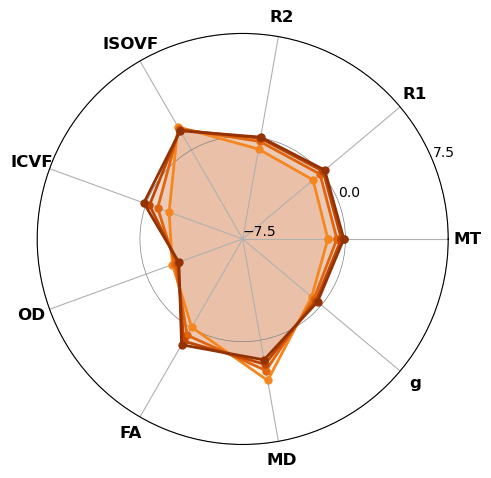

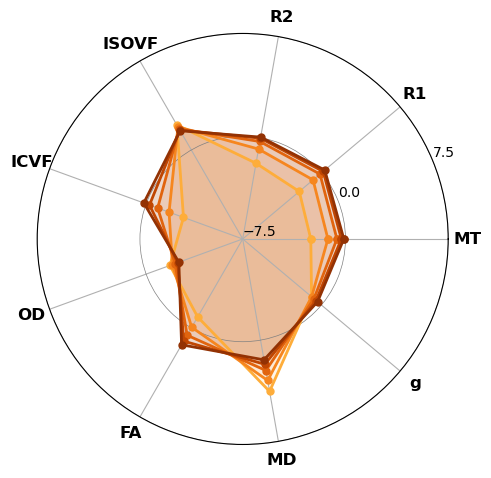

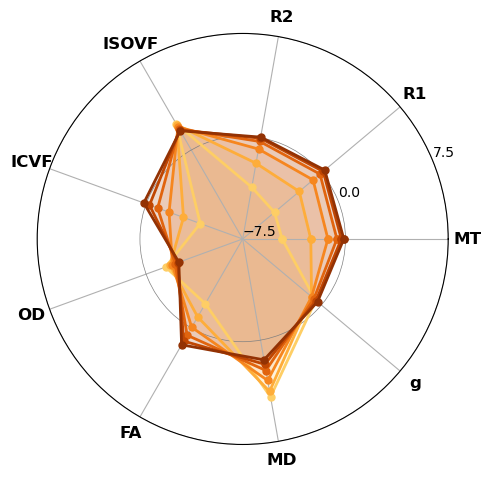

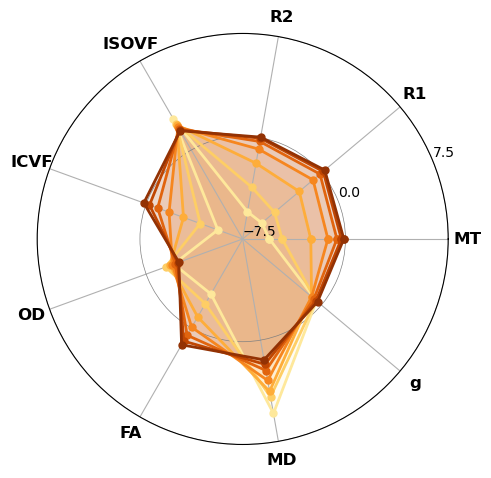

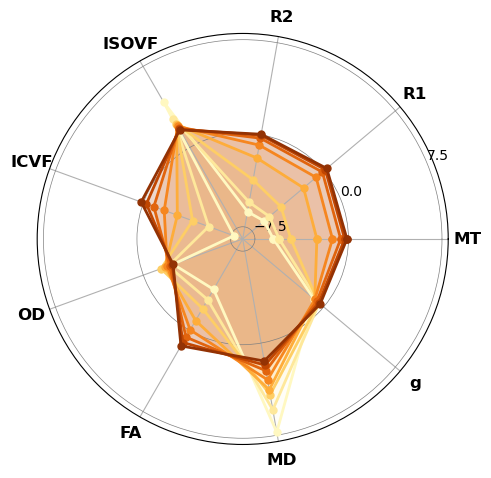

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

results_df_copy=results_df

# Convert index to short metric labels
short_labels = results_df.index.str.extract(r"Mean_Metrics_In_(\w+)")[0]
results_df_copy.index = short_labels

layers = results_df_copy.columns

# Define colors using PuOr colormap
layer_colors = sns.color_palette('YlOrBr', len(layers))

# Create a color dictionary to store the consistent colors for each layer
color_dict = {layer: layer_colors[idx] for idx, layer in enumerate(layers)}

# Function to plot a chunk of layers and save it
def plot_and_save_chunk(layers_chunk, chunk_num):
    # Initialize the radar plot with a smaller figure size
    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))  # Adjusted size

    # Create a radar plot for each layer
    for idx, layer in enumerate(layers_chunk):
        # Values for this layer, drop NaNs
        values = results_df[layer].astype(float).dropna().values
        
        # Ensure there are enough data points to plot
        if len(values) == 0:
            continue
        
        # Add the circular connection to close the radar plot
        values = np.append(values, values[0])  # Circular connection
        
        # Angles for radar plot (adjusted to account for circular connection)
        angles = np.linspace(0, 2 * np.pi, len(values)-1, endpoint=False).tolist()
        
        # Ensure angles also have one extra element to match values
        angles += [angles[0]]  # Circular connection for x and y match
        
        # Plot the values with markers and line width
        ax.plot(angles, values, label=layer, color=color_dict[layer], linewidth=2, marker='o', markersize=5)
        ax.fill(angles, values, alpha=0.1, color=color_dict[layer])  # Add transparency for the fills

    # Customize gridlines and yticks
    ax.set_yticks([-7.5, 0, 7.5])  # Only show -7, 0, and 7 circles
    ax.yaxis.grid(True, color='lightgray', linewidth=0.5)

    gridlines = ax.yaxis.get_gridlines()
    for line in gridlines:
        y_value = line.get_ydata()[0]
        if np.isclose(y_value, 0):
            line.set_linewidth(0.5)  # Make the 0-circle bolder
            line.set_color('gray')
        else:
            line.set_visible(False)  # Hide other gridlines

    # Set custom tick labels for the x-axis
    ax.set_xticks(np.linspace(0, 2 * np.pi, len(results_df.index), endpoint=False))
    ax.set_xticklabels(short_labels, fontsize=12, fontweight='bold')

    # Set title with reduced font size and bold weight
    #plt.title(f"Cohen's d by Metric and Layer - Batch {chunk_num}", fontsize=14, fontweight='bold', pad=20)

    # Save the figure to a file
    plt.tight_layout()
    plot_path = os.path.join(notebook_dir, f'Figures/Radar_plot_layers_{chunk_num}_cross_sectionnal.png')  # Change this to your desired path

    # Save the figure
    plt.savefig(plot_path, dpi=300)

    # Show the plot
    plt.show()

# Loop through the inverse list of layers and plot
for i in range(1, len(layers) + 1):
    # Take first 'i' layers in reverse order
    layers_chunk = layers[-i:]
    plot_and_save_chunk(layers_chunk, i)


## Age relationships

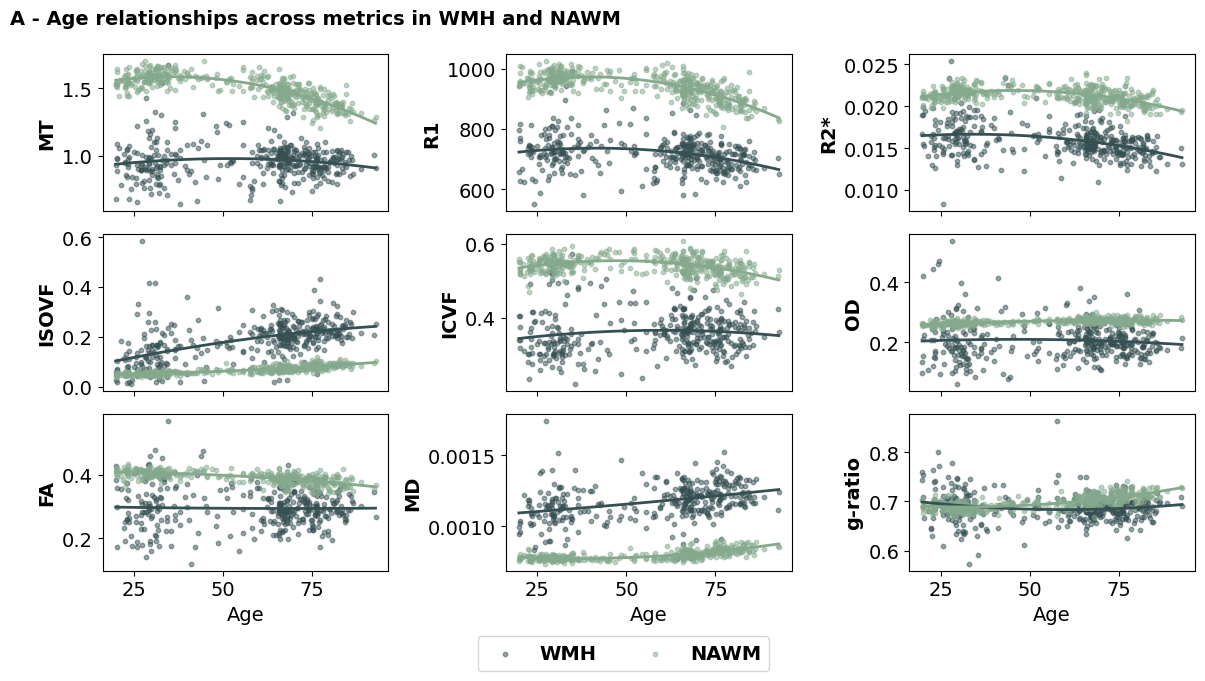

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.font_manager as fm

# Create PR column for merging
PT_to_colaudID['PR'] = 's' + PT_to_colaudID['SubjectName'].str[:16]

# List of all the metrics you want to plot
metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

# Set up the 3x3 grid for plotting with shared x-axis
fig, axes = plt.subplots(3, 3, figsize=(12, 6), sharex=True)  # 3 rows, 3 columns, shared x-axis
axes = axes.flatten()  # Flatten to easily index each subplot

# Iterate over each metric and create the plot
for i, metric in enumerate(metrics):
    try:
        # Extracting the metric values for WMH
        wmh_data = {
            'PR': list(combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['WMH'].keys()),
            'WMH': [value[0] for value in combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['WMH'].values()]  # Flattening the list
        }

        # Extracting the 'NAWM' values for the current metric
        nawm_data = {
            'PR': list(combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['NAWM'].keys()),
            'NAWM': [value[0] for value in combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['NAWM'].values()]  # Flattening the list
        }

        # Create DataFrames for WMH and NAWM for the current metric
        wmh_df = pd.DataFrame(wmh_data)
        nawm_df = pd.DataFrame(nawm_data)

        # Merge with PT_to_colaudID to get Age and Gender columns
        merged_wmh = pd.merge(wmh_df, PT_to_colaudID[['PR', 'Age', 'Gender']], on='PR', how='inner')
        merged_nawm = pd.merge(nawm_df, PT_to_colaudID[['PR', 'Age', 'Gender']], on='PR', how='inner')

        # Remove NaN values from Age and metric columns
        merged_wmh = merged_wmh.dropna(subset=['Age', 'WMH'])
        merged_nawm = merged_nawm.dropna(subset=['Age', 'NAWM'])

        # Sort Age and corresponding values (strictly increasing)
        merged_wmh = merged_wmh.sort_values(by='Age')
        merged_nawm = merged_nawm.sort_values(by='Age')

        # Ensure Age values are strictly increasing, remove duplicates if needed
        merged_wmh = merged_wmh[merged_wmh['Age'].diff() > 0]
        merged_nawm = merged_nawm[merged_nawm['Age'].diff() > 0]

        # Scatter plot for WMH and NAWM
        axes[i].scatter(merged_wmh['Age'], merged_wmh['WMH'], color='#354f52', alpha=0.5, s=10, label='WMH')
        axes[i].scatter(merged_nawm['Age'], merged_nawm['NAWM'], color='#84a98c', alpha=0.5, s=10, label='NAWM')

        # Fit a second-order polynomial (quadratic) to WMH data
        coeffs_wmh = np.polyfit(merged_wmh['Age'], merged_wmh['WMH'], 2)
        poly_wmh = np.poly1d(coeffs_wmh)
        age_range = np.linspace(min(merged_wmh['Age']), max(merged_wmh['Age']), 100)
        axes[i].plot(age_range, poly_wmh(age_range), color='#354f52', lw=2)

        # Fit a second-order polynomial (quadratic) to NAWM data
        coeffs_nawm = np.polyfit(merged_nawm['Age'], merged_nawm['NAWM'], 2)
        poly_nawm = np.poly1d(coeffs_nawm)
        axes[i].plot(age_range, poly_nawm(age_range), color='#84a98c', lw=2)

        # Set the title for the subplot
        axes[i].set_title(f'', fontsize=12)
        axes[i].set_ylabel(f'{metric}', fontsize=14, fontweight='bold')

        # Remove the x-axis label for all plots except the last row (indices 6, 7, 8)
        if i >= 6:  # For the last row (indices 6, 7, 8)
            axes[i].set_xlabel('Age', fontsize=14)
        else:
            axes[i].set_xlabel('')  # Remove x-axis label for all other plots

        # Set font size for x and y ticks
        axes[i].tick_params(axis='both', labelsize=14)

        axes[i].grid(False)

    except KeyError as e:
        print(f"KeyError for {metric}: {e}. Skipping this metric.")
        continue  # Skip this metric and move to the next

# Adjust layout and spacing between subplots
plt.tight_layout()

# Add a title to the entire plot (aligned to top-left with boxplots)
plt.suptitle('A - Age relationships across metrics in WMH and NAWM', fontsize=14, fontweight='bold', y=1.05, ha='left', x=0)


# Define font properties
font_props = fm.FontProperties(weight='bold', size=14)

# Add legend at the bottom of the plot
plt.legend(loc='lower center', bbox_to_anchor=(-1, -0.7), shadow=False, ncol=2, prop=font_props)

# Save the plot
plot_path = os.path.join(notebook_dir, f'Figures/Age_relationships.png')  # Change this to your desired path
plt.savefig(plot_path, bbox_inches='tight', dpi=300)

# Display the plot
plt.show()


In [114]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import fdrcorrection
import matplotlib.pyplot as plt

# Create PR column for merging
PT_to_colaudID['PR'] = 's' + PT_to_colaudID['SubjectName'].str[:16]

# List of all the metrics you want to plot
metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

# Create a list to store results
results = []

# Iterate over each metric and perform the group * polynomial regression
for metric in metrics:
    try:
        # Extracting the metric values for WMH
        wmh_data = {
            'PR': list(combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['WMH'].keys()),
            'WMH': [value[0] for value in combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['WMH'].values()]  # Flattening the list
        }

        # Extracting the 'NAWM' values for the current metric
        nawm_data = {
            'PR': list(combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['NAWM'].keys()),
            'NAWM': [value[0] for value in combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['NAWM'].values()]  # Flattening the list
        }

        # Create DataFrames for WMH and NAWM for the current metric
        wmh_df = pd.DataFrame(wmh_data)
        nawm_df = pd.DataFrame(nawm_data)

        # Merge with PT_to_colaudID to get Age and Gender columns
        merged_wmh = pd.merge(wmh_df, PT_to_colaudID[['PR', 'Age', 'Gender']], on='PR', how='inner')
        merged_nawm = pd.merge(nawm_df, PT_to_colaudID[['PR', 'Age', 'Gender']], on='PR', how='inner')

        # Remove NaN values from Age and metric columns
        merged_wmh = merged_wmh.dropna(subset=['Age', 'WMH'])
        merged_nawm = merged_nawm.dropna(subset=['Age', 'NAWM'])

        # Sort Age and corresponding values (strictly increasing)
        merged_wmh = merged_wmh.sort_values(by='Age')
        merged_nawm = merged_nawm.sort_values(by='Age')

        # Combine both WMH and NAWM data into one DataFrame for analysis
        merged_data = pd.concat([merged_wmh[['Age', 'WMH', 'Gender']], merged_nawm[['Age', 'NAWM', 'Gender']]], ignore_index=True)

        merged_data['Group'] = ['WMH'] * len(merged_wmh) + ['NAWM'] * len(merged_nawm)
        merged_data['MetricValue'] = np.where(merged_data['WMH'].notna(), merged_data['WMH'], merged_data['NAWM'])

        # Create polynomial features for Age (quadratic term)
        merged_data['Age_poly'] = merged_data['Age'] ** 2  # Calculate the quadratic term manually

        # Perform regression analysis (Group * Age and Age_poly interaction), with NAWM as reference category
        model = ols('MetricValue ~ C(Group, Treatment(reference="NAWM")) * (Age + Age_poly)', data=merged_data).fit()

        # Extract t-values and p-values for each term
        t_values = model.tvalues
        p_values = model.pvalues

        # Store results
        results.append({
            'Metric': metric,
            'Age t-value': round(t_values['Age'], 1),
            'Age_poly t-value': round(t_values['Age_poly'], 1),
            'Gp t-value': round(t_values['C(Group, Treatment(reference="NAWM"))[T.WMH]'], 1),
            'Gp*Age t-value': round(t_values['C(Group, Treatment(reference="NAWM"))[T.WMH]:Age'], 1),
            'Gp*Age_poly t-value': round(t_values['C(Group, Treatment(reference="NAWM"))[T.WMH]:Age_poly'], 1),
            'Age p-value': round(p_values['Age'], 5),
            'Age_poly p-value': round(p_values['Age_poly'], 5),
            'Gp p-value': round(p_values['C(Group, Treatment(reference="NAWM"))[T.WMH]'], 5),
            'Gp*Age p-value': round(p_values['C(Group, Treatment(reference="NAWM"))[T.WMH]:Age'], 5),
            'Gp*Age_poly p-value': round(p_values['C(Group, Treatment(reference="NAWM"))[T.WMH]:Age_poly'], 5),
        })

    except KeyError as e:
        print(f"KeyError for {metric}: {e}. Skipping this metric.")
        continue  # Skip this metric and move to the next

# Convert the results to a DataFrame
results_df = pd.DataFrame(results)

# Collect all p-values into a single list to apply FDR correction
all_p_values = results_df[['Age p-value', 'Age_poly p-value', 'Gp p-value', 'Gp*Age p-value', 'Gp*Age_poly p-value']].values.flatten()

# Apply FDR correction
rejected, q_values = fdrcorrection(all_p_values)

# Reshape the q-values back to the results_df
q_values = q_values.reshape(-1, 5)

# Round the q-values to 5 decimal places
q_values_rounded = np.round(q_values, 5)

# Add the rounded q-values to the results dataframe
results_df[['Age q-value', 'Age_poly q-value', 'Gp q-value', 'Gp*Age q-value', 'Gp*Age_poly q-value']] = q_values_rounded

# Save results to CSV
results_df.to_csv(os.path.join(notebook_dir, f'CSV/group_poly_age_regression_results.csv'), index=False)

# Print the results for debugging
print(results_df)


    Metric  Age t-value  Age_poly t-value  Gp t-value  Gp*Age t-value  \
0       MT          4.7              -7.0       -11.0            -1.3   
1       R1          5.5              -7.2        -8.7            -1.6   
2      R2*          4.5              -5.2        -5.0            -1.4   
3    ISOVF          0.0               0.7        -0.2             2.9   
4     ICVF          3.5              -3.9        -7.6            -0.8   
5       OD          1.0              -0.7        -2.4             0.2   
6       FA          0.2              -1.0        -3.8            -0.6   
7       MD         -1.6               2.3         4.9             1.9   
8  g-ratio         -1.8               3.1         1.8            -1.1   

   Gp*Age_poly t-value  Age p-value  Age_poly p-value  Gp p-value  \
0                  2.8      0.00000           0.00000     0.00000   
1                  2.3      0.00000           0.00000     0.00000   
2                  1.0      0.00001           0.00000     0.00

## Effect size age decades

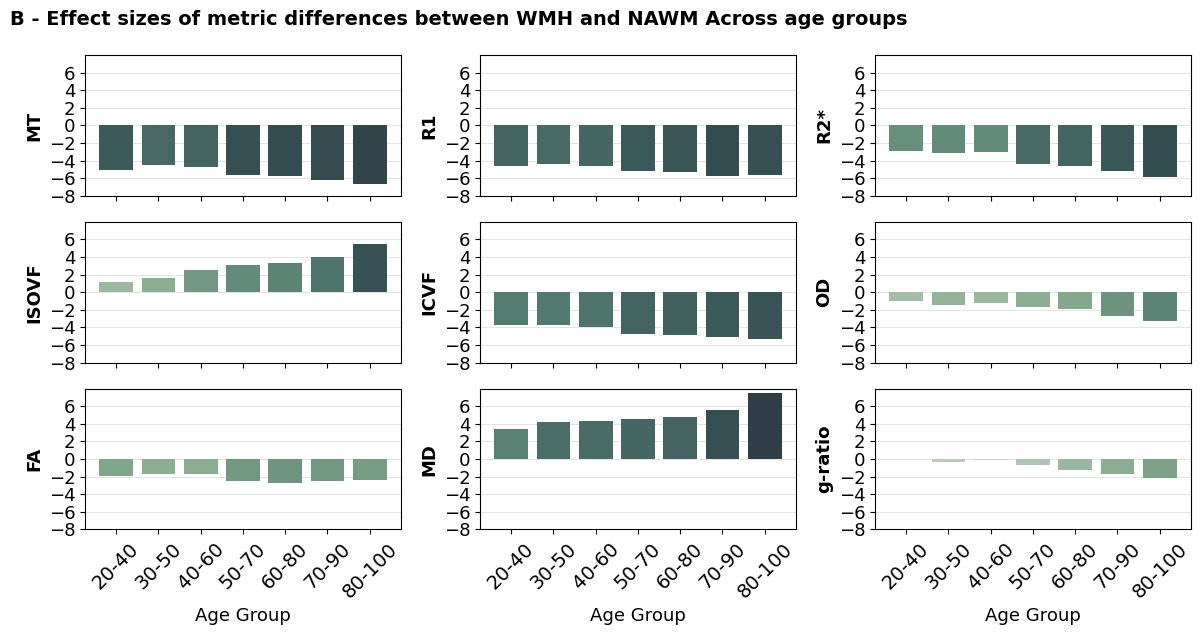

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm

# Define the sliding age groups
age_groups = [(20,35),(25,40), (30,45), (35,50), (40,55), (45,60), (50,65), (55, 70), (60, 75), (65, 80), (70, 85), (75, 90), (80, 95)]
age_groups = [(20,40),(30,50), (40,60),  (50,70), (60,80), (70,90), (80,100)]

# List of all the metrics you want to plot
metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'FA', 'MD', 'g-ratio']

# Function to compute Cohen's d
def cohen_d(group1, group2):
    # Calculate means and standard deviations
    mean1, mean2 = np.mean(group1), np.mean(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    n1, n2 = len(group1), len(group2)

    # Compute pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))

    # Cohen's d
    return (mean1 - mean2) / pooled_std

# Create a custom color palette
custom_palette = ["#cad2c5", "#a7bea9", "#84a98c", "#6b917e", "#52796f", "#446461", "#354f52", "#32474c", "#2f3e46"]
cmap = LinearSegmentedColormap.from_list("effect_size_palette", custom_palette)

# Set up the 3x3 grid for plotting
fig, axes = plt.subplots(3, 3, figsize=(12, 6))  # 3 rows, 3 columns
axes = axes.flatten()  # Flatten to easily index each subplot

# Initialize list to store all effect sizes for calculating global y-axis limits
all_effect_sizes = []

# Iterate over each metric
for i, metric in enumerate(metrics):
    effect_sizes = []  # To store the effect sizes for each age group

    # Extracting the metric values for WMH and NAWM
    wmh_data = {
        'PR': list(combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['WMH'].keys()),
        'WMH': [value[0] for value in combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['WMH'].values()]  # Flattening the list
    }
    nawm_data = {
        'PR': list(combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['NAWM'].keys()),
        'NAWM': [value[0] for value in combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['NAWM'].values()]  # Flattening the list
    }

    # Create DataFrames for WMH and NAWM
    wmh_df = pd.DataFrame(wmh_data)
    nawm_df = pd.DataFrame(nawm_data)

    # Merge with PT_to_colaudID to get Age and Gender columns
    merged_wmh = pd.merge(wmh_df, PT_to_colaudID[['PR', 'Age', 'Gender']], on='PR', how='inner')
    merged_nawm = pd.merge(nawm_df, PT_to_colaudID[['PR', 'Age', 'Gender']], on='PR', how='inner')

    # For each age group, calculate Cohen's d
    for start, end in age_groups:
        # Filter data based on the age range
        group_wmh = merged_wmh[(merged_wmh['Age'] >= start) & (merged_wmh['Age'] < end)]['WMH']
        group_nawm = merged_nawm[(merged_nawm['Age'] >= start) & (merged_nawm['Age'] < end)]['NAWM']

        # If both groups have data, calculate the effect size
        if len(group_wmh) > 0 and len(group_nawm) > 0:
            d = cohen_d(group_wmh, group_nawm)
            effect_sizes.append(d)
        else:
            effect_sizes.append(np.nan)  # If one of the groups is empty, append NaN

    # Collect effect sizes for global min/max
    all_effect_sizes.extend(effect_sizes)

# Calculate the global minimum and maximum effect sizes to set consistent y-axis limits across all plots
global_min_effect_size = np.nanmin(all_effect_sizes)
global_max_effect_size = np.nanmax(all_effect_sizes)

# Calculate the global maximum absolute effect size to normalize colors
max_effect_size = max(abs(global_min_effect_size), abs(global_max_effect_size))

# Set up the color normalization
norm = plt.Normalize(vmin=0, vmax=max_effect_size)  # Normalize effect sizes to range [0, max_effect_size]
colors = cmap(norm(np.linspace(0, 1, len(age_groups))))  # Apply color gradient

# Plot each metric
for i, metric in enumerate(metrics):
    effect_sizes = []  # To store the effect sizes for each age group

    # Extracting the metric values for WMH and NAWM
    wmh_data = {
        'PR': list(combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['WMH'].keys()),
        'WMH': [value[0] for value in combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['WMH'].values()]  # Flattening the list
    }
    nawm_data = {
        'PR': list(combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['NAWM'].keys()),
        'NAWM': [value[0] for value in combined_mean_metrics_data_cross_sectionnal[f'Mean_Metrics_In_{metric}']['NAWM'].values()]  # Flattening the list
    }

    # Create DataFrames for WMH and NAWM
    wmh_df = pd.DataFrame(wmh_data)
    nawm_df = pd.DataFrame(nawm_data)

    # Merge with PT_to_colaudID to get Age and Gender columns
    merged_wmh = pd.merge(wmh_df, PT_to_colaudID[['PR', 'Age', 'Gender']], on='PR', how='inner')
    merged_nawm = pd.merge(nawm_df, PT_to_colaudID[['PR', 'Age', 'Gender']], on='PR', how='inner')

    # For each age group, calculate Cohen's d
    for start, end in age_groups:
        # Filter data based on the age range
        group_wmh = merged_wmh[(merged_wmh['Age'] >= start) & (merged_wmh['Age'] < end)]['WMH']
        group_nawm = merged_nawm[(merged_nawm['Age'] >= start) & (merged_nawm['Age'] < end)]['NAWM']

        # If both groups have data, calculate the effect size
        if len(group_wmh) > 0 and len(group_nawm) > 0:
            d = cohen_d(group_wmh, group_nawm)
            effect_sizes.append(d)
        else:
            effect_sizes.append(np.nan)  # If one of the groups is empty, append NaN

    # Apply color based on the effect size value
    colors = cmap(norm(np.abs(effect_sizes)))  # Apply color gradient based on absolute effect sizes

    # Plotting the effect sizes for each metric with a color gradient
    axes[i].bar(range(len(age_groups)), effect_sizes, color=colors, zorder=3)
    axes[i].set_xticks(range(len(age_groups)))
    axes[i].set_ylim(-8, 8)

    # Set x-axis and title only for the last row (3 subplots in the last row)
    if i >= 6:
        axes[i].set_xlabel('Age Group', fontsize=13)
        axes[i].set_xticklabels([f'{start}-{end}' for start, end in age_groups], rotation=45, fontsize=14)
    else:
        axes[i].set_xlabel('')  # Remove x-axis labels for non-last row
        axes[i].set_xticklabels('', rotation=45)

    # Set y-axis labels with bold and larger font size for all plots
    axes[i].set_ylabel(f'{metric}', fontsize=13, fontweight='bold')

    # Set y-axis tick labels font size to 13
    for label in axes[i].get_yticklabels():
        label.set_fontsize(13)

    # Add light horizontal grid lines every 2 units on the y-axis, behind the bars
    axes[i].set_yticks(np.arange(-8, 8, 2))  # Set y-ticks with a step of 2 units

    axes[i].set_title('')

    axes[i].grid(True, axis='y', zorder=-1, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)  # Lighter grid lines

# Adjust layout and spacing between subplots
plt.tight_layout()

# Add a title to the entire plot (aligned to top-left with boxplots)
plt.suptitle('B - Effect sizes of metric differences between WMH and NAWM Across age groups', fontsize=14, fontweight='bold', y=1.05, ha='left', x=0)

# Save the plot
plot_path = os.path.join(notebook_dir, f'Figures/Effect_size_age_groups.png')  # Change this to your desired path

plt.savefig(plot_path, bbox_inches='tight', dpi=300)


# Display the plot
plt.show()


## Longitudinal processing

### Extract and sort longitudinal PR names

In [428]:
import os
import glob
import pickle

# Step 1: Filter PRs with >1 MT scan (as MT is the reference for longitudinal check)
def get_longitudinal_prs(common_pr_sectionnal, mpm_path):
    common_PR_longitudinal = []
    for pr in common_pr_sectionnal:
        MT_scan_files = glob.glob(os.path.join(mpm_path, pr, '*MT_masked*FU4*nii.gz'))
        if len(MT_scan_files) > 1:
            common_PR_longitudinal.append(pr)
    print(f"n= {len(common_PR_longitudinal)} number of PRs with more than one MT scans")
    return common_PR_longitudinal

# INPUT DATA
common_PR_cross_sectionnal = PR_colaus['PR']
dir_path = '/mnt/filerc/LREN/PI_DRAGANSKI/abussy/WMH_new/'
mpm_path = '/mnt/HDD1/USERS_DATAS/aurelie/MPM_longitudinal/'
metrics = ['MT', 'R1', 'R2*', 'ICVF', 'ISOVF', 'OD', 'MD', 'FA', 'g_ratio']

# Step 1: Get subjects with >1 MT scan
common_PR_longitudinal = get_longitudinal_prs(common_PR_cross_sectionnal, mpm_path)

# Step 2: Create one dictionary per metric
grouped_scans_dicts = {}  # Container for all metric-wise dictionaries

for metric in metrics:
    grouped_scans_dict = {}  # Dictionary for this metric
    
    for pr in common_PR_longitudinal:
        scan_files = glob.glob(os.path.join(mpm_path, pr, f'*{metric}*FU4*nii.gz'))
        
        grouped_scans = {}
        for scan_path in scan_files:
            basename = os.path.basename(scan_path)
            pr_filename = basename.split("s")[1][:7] if "s" in basename else basename[:7]
            
            if pr_filename not in grouped_scans:
                grouped_scans[pr_filename] = []
            grouped_scans[pr_filename].append(scan_path)
        
        if grouped_scans:  # Only add PRs with at least one matching scan
            grouped_scans_dict[pr] = grouped_scans

    grouped_scans_dicts[metric] = grouped_scans_dict


# Initialize the dictionary to store the mask paths
masks_dict = {}

# Iterate through the grouped_scans_dict to find the corresponding WM masks for each filenamePR
for longitudinalPR, longitudinal_data in grouped_scans_dicts['MT'].items():
    for filenamePR, file_data in longitudinal_data.items():
        
        # Construct the wm_file_path based on the pattern
        wm_file_path = glob.glob(os.path.join(dir_path, 'MPRAGE', longitudinalPR, f'{longitudinalPR}*WM.*'))
        wmh_file_path = glob.glob(os.path.join(dir_path, 'FLAIR', longitudinalPR, f'whitenet_FLAIR_WMH_sanlm_m{longitudinalPR}*_in_MPRAGE_masked_in_MPM.nii.gz'))
        csf_file_path = glob.glob(os.path.join(dir_path, 'MPRAGE', longitudinalPR, f'{longitudinalPR}*CSF.*'))
        
        # If a WM mask is found, associate it with the filenamePR
        if wm_file_path:
            # Initialize the longitudinalPR key in the wm_masks_dict if not already present
            if longitudinalPR not in masks_dict:
                masks_dict[longitudinalPR] = {}
            
            # Add the corresponding WM mask to the dictionary under the filenamePR key
            if filenamePR not in masks_dict[longitudinalPR]:
                masks_dict[longitudinalPR][filenamePR] = []

            # Append the WM file path
            masks_dict[longitudinalPR][filenamePR].append(wm_file_path[0])
            masks_dict[longitudinalPR][filenamePR].append(wmh_file_path[0])  # Assuming you want to also add the WMH mask
            masks_dict[longitudinalPR][filenamePR].append(csf_file_path[0])  # Assuming you want to also add the CSF mask
        else:
            print(f"WM mask not found for {filenamePR} in {longitudinalPR}")
            
print(f"n= {len(masks_dict)} number of PRs with all the masks")

# Extract properly each individual path
# Initialize masks file lists
wm_files = []
wmh_files = []
csf_files = []

# Initialize a dictionary of lists for all metrics
metric_files = {metric: [] for metric in grouped_scans_dicts.keys()}

# Iterate over all subjects and their scan sessions (based on MT dict as reference)
for pr, pr_sessions in grouped_scans_dicts['MT'].items():
    for pr_filename in pr_sessions.keys():
        # Get mask paths (WM, WMH, CSF)
        wm_path = masks_dict[pr][pr_filename][0]
        wmh_path = masks_dict[pr][pr_filename][1]
        csf_path = masks_dict[pr][pr_filename][2]

        # Append masks
        wm_files.append(wm_path)
        wmh_files.append(wmh_path)
        csf_files.append(csf_path)

        # Append paths for each metric if available
        for metric, metric_dict in grouped_scans_dicts.items():
            try:
                scan_path = metric_dict[pr][pr_filename][0]
                metric_files[metric].append(scan_path)
            except KeyError:
                print(f"Missing {metric} scan for PR {pr}, filename {pr_filename}")


n= 213 number of PRs with more than one MT scans
n= 212 number of PRs with all the masks
Missing ICVF scan for PR sPR05733_RG090596, filename PR00618
Missing ISOVF scan for PR sPR05733_RG090596, filename PR00618
Missing OD scan for PR sPR05733_RG090596, filename PR00618
Missing MD scan for PR sPR05733_RG090596, filename PR00618
Missing FA scan for PR sPR05733_RG090596, filename PR00618
Missing g_ratio scan for PR sPR05733_RG090596, filename PR00618
Missing ICVF scan for PR sPR05766_LB071047, filename 1810041
Missing ISOVF scan for PR sPR05766_LB071047, filename 1810041
Missing OD scan for PR sPR05766_LB071047, filename 1810041
Missing MD scan for PR sPR05766_LB071047, filename 1810041
Missing FA scan for PR sPR05766_LB071047, filename 1810041
Missing MD scan for PR sPR05767_DB291140, filename PR05767
Missing FA scan for PR sPR05767_DB291140, filename PR05767
Missing ICVF scan for PR sPR05776_CC090753, filename PR05776
Missing ISOVF scan for PR sPR05776_CC090753, filename PR05776
Missin

In [429]:
# Step: Only retain PR-filename sessions that have all metrics available
final_wm_files = []
final_wmh_files = []
final_csf_files = []
final_metric_files = {metric: [] for metric in metrics}

for pr, pr_sessions in grouped_scans_dicts['MT'].items():
    for pr_filename in pr_sessions.keys():
        # Check mask presence
        if pr not in masks_dict or pr_filename not in masks_dict[pr]:
            continue  # Skip if any mask missing

        # Check all metrics are available
        complete = True
        current_metric_paths = {}
        for metric in metrics:
            try:
                metric_path = grouped_scans_dicts[metric][pr][pr_filename][0]
                current_metric_paths[metric] = metric_path
            except KeyError:
                complete = False
                break  # Missing metric for this session

        if complete:
            # Append masks
            final_wm_files.append(masks_dict[pr][pr_filename][0])
            final_wmh_files.append(masks_dict[pr][pr_filename][1])
            final_csf_files.append(masks_dict[pr][pr_filename][2])
            # Append all metric files
            for metric in metrics:
                final_metric_files[metric].append(current_metric_paths[metric])
        else:
            print(f"Skipped {pr_filename} in {pr} due to missing metrics.")

print(f"\n✅ Final retained sessions: {len(final_wm_files)}")

Skipped PR00618 in sPR05733_RG090596 due to missing metrics.
Skipped 1810041 in sPR05766_LB071047 due to missing metrics.
Skipped PR05767 in sPR05767_DB291140 due to missing metrics.
Skipped PR05776 in sPR05776_CC090753 due to missing metrics.
Skipped PR05831 in sPR05831_VA180655 due to missing metrics.
Skipped PR05853 in sPR05853_MM250593 due to missing metrics.
Skipped PR05856 in sPR05856_RJ090155 due to missing metrics.
Skipped PR02535 in sPR05859_GJ170391 due to missing metrics.
Skipped PR05864 in sPR05864_MC010385 due to missing metrics.
Skipped PR05881 in sPR05881_JC080291 due to missing metrics.
Skipped PR05884 in sPR05884_AC170144 due to missing metrics.
Skipped PR05904 in sPR05904_AD070456 due to missing metrics.
Skipped PR01527 in sPR05921_BP100240 due to missing metrics.
Skipped PR02741 in sPR05923_PC140852 due to missing metrics.
Skipped PR05945 in sPR05945_SD141296 due to missing metrics.
Skipped PR06006 in sPR06006_JB300146 due to missing metrics.
Skipped PR06058 in sPR06

### Run longitudinal dictionnary (DO NOT RERUN)

In [430]:
import os
import numpy as np
import pickle
from scipy.ndimage import binary_dilation, binary_erosion, binary_fill_holes
import nibabel as nib
from tqdm import tqdm  # Import tqdm for progress bars

# Your metric dict
metric_file_dicts = {
    metric: {'data': final_metric_files[metric]}
    for metric in ['MT', 'R1', 'R2*', 'ICVF', 'ISOVF', 'OD', 'MD', 'FA', 'g_ratio']
}

metric_file_dicts = {
    metric: {'data': final_metric_files[metric]}
    for metric in ['g_ratio']
}

# Your common masks
wm_files = final_wm_files
csf_files = final_csf_files
wmh_files = final_wmh_files  # Assuming you have this too


# Function to extract 16-character subject ID from the MT file
def extract_subject_id_from_filename(filename):
    base_name = os.path.basename(filename)
    subject_id = base_name[base_name.find('sPR'):base_name.find('sPR')+16]
    return subject_id

# Function to calculate the mean voxel value for a given mask
def calculate_mean_voxel_value(mt_data, mask_data):
    """Calculate mean voxel value of the mt_data masked by the mask_data."""
    if mt_data is None or mask_data is None:
        return None
    masked_data = mt_data * mask_data
    mean_value = np.mean(masked_data[masked_data > 0])  # Only consider masked (non-zero) values
    return mean_value

# Function to load the NIfTI data
def load_nifti_data(file_path):
    try:
        data = nib.load(file_path).get_fdata()
        return data
    except Exception as e:
        print(f"Error loading NIfTI file {file_path}: {e}")
        return None

# Create the layers (Layer1 to Layer5)
def create_layers(wmh_data, wm_data, nawm_data):
    layers = []
    wmh_dilated = binary_dilation(wmh_data, iterations=1)
    wmh_inverted = np.logical_not(wmh_data).astype(np.uint8)
    layer_1 = wmh_dilated * wmh_inverted
    layers.append(apply_mask(layer_1, nawm_data))

    for i in range(1, 5):
        dilated_wmh = binary_dilation(wmh_data, iterations=i+1)
        dilated_wmh_previous = binary_dilation(wmh_data, iterations=i)
        layer = np.logical_xor(dilated_wmh, dilated_wmh_previous)
        layers.append(apply_mask(layer, nawm_data))

    return layers

# Create inner layers
def create_inner_layers(wmh_data):
    inner_layer_1 = np.logical_xor(wmh_data, binary_erosion(wmh_data, iterations=1))
    inner_layer_2 = binary_erosion(wmh_data, iterations=1).astype(np.uint8) - binary_erosion(wmh_data, iterations=2).astype(np.uint8)
    return [inner_layer_1, inner_layer_2]

# Apply mask to data
def apply_mask(data, mask):
    if data is not None and mask is not None:
        return data * mask
    return data

# Function to create specific masks like 'WM_left', 'PVWM', 'SWM', etc.
def process_subject_files(wm_file, wmh_file, csf_file, metric_file):
    wm_data = load_nifti_data(wm_file)
    wmh_data = load_nifti_data(wmh_file)
    csf_data = load_nifti_data(csf_file)
    metric_data = load_nifti_data(metric_file)

    subject_data = {}

    if wm_data is not None:
        subject_data['WM'] = wm_data
    if csf_data is not None:
        subject_data['CSF'] = csf_data

    if wm_data is not None and wmh_data is not None:
        wmh_data = np.where((wmh_data == 1) & (wm_data == 0), 0, wmh_data)
        nawm_data = np.logical_and(wm_data == 1, wmh_data == 0).astype(np.uint8)
        subject_data['NAWM'] = nawm_data
        subject_data['WMH'] = wmh_data
    else:
        nawm_data = None

    if wmh_data is not None and nawm_data is not None:
        # Layers
        layers = create_layers(wmh_data, wm_data, nawm_data)
        for i, layer in enumerate(layers):
            subject_data[f'Layer{i+1}'] = layer

        # Inner layers
        inner_layers = create_inner_layers(wmh_data)
        subject_data['InnerLayer1'] = inner_layers[0]
        subject_data['InnerLayer2'] = inner_layers[1]

        # SWM / PVWM
        if csf_data is not None and wm_data is not None:
            csf_dilated = binary_dilation(csf_data, iterations=8)
            combined = np.logical_or(wm_data, csf_dilated).astype(np.uint8)
            filled = binary_fill_holes(combined).astype(np.uint8)
            eroded = binary_erosion(filled, iterations=2)
            subject_data['SWM'] = filled * np.logical_not(eroded)

            csf_inv = np.logical_not(csf_data).astype(np.uint8)
            subject_data['PVWM'] = csf_dilated * csf_inv * wm_data

        if wm_data is not None and nawm_data is not None:
            dilated_wmh = binary_dilation(wmh_data, iterations=5)
            wm_left = nawm_data * np.logical_not(dilated_wmh)
            subject_data['WM_left'] = wm_left

        if wm_data is not None and csf_data is not None:
            subject_data['DWM'] = wm_data * \
                                  np.logical_not(subject_data.get('PVWM', 0)) * \
                                  np.logical_not(subject_data.get('SWM', 0)) * \
                                  np.logical_not(csf_data).astype(np.uint8)

        if 'WMH' in subject_data:
            subject_data['WMH_DWM'] = subject_data['WMH'] * subject_data.get('DWM', 0)
            subject_data['WMH_SWM'] = subject_data['WMH'] * subject_data.get('SWM', 0)
            subject_data['WMH_PVWM'] = subject_data['WMH'] * subject_data.get('PVWM', 0)

        if 'NAWM' in subject_data:
            subject_data['NAWM_DWM'] = nawm_data * subject_data.get('DWM', 0)
            subject_data['NAWM_SWM'] = nawm_data * subject_data.get('SWM', 0)
            subject_data['NAWM_PVWM'] = nawm_data * subject_data.get('PVWM', 0)

    # Compute means
    mean_values = {}
    for region, mask in subject_data.items():
        mean_values[region] = calculate_mean_voxel_value(metric_data, mask)

    subject_id = extract_subject_id_from_filename(metric_file)
    return subject_id, mean_values
 

 

# Function to save the mean values per batch to a checkpoint
def save_batch_mean_values(mean_values_per_subject, batch_index, metric):
    checkpoint_dir = '/mnt/HDD1/USERS_DATAS/aurelie/Dictionnaries_long/'
    batch_filename = os.path.join(checkpoint_dir, f'{metric}_metrics_longitudinal_mean_batch_{batch_index}.pkl')
    with open(batch_filename, 'wb') as f:
        pickle.dump(mean_values_per_subject, f)

# Main function to split the work into batches and process each batch
def process_in_batches(wm_files, wmh_files, csf_files, metric_files, metric, batch_size=5):
    batches = [
        list(zip(wm_files[i:i + batch_size],
                 wmh_files[i:i + batch_size],
                 csf_files[i:i + batch_size],
                 metric_files[i:i + batch_size]))
        for i in range(0, len(wm_files), batch_size)
    ]

    for batch_index, batch in enumerate(tqdm(batches, desc=f"Processing {metric} batches", unit="batch", ncols=100)):
        mean_values_per_subject = {}
        for wm_file, wmh_file, csf_file, metric_file in batch:
            subject_id, mean_values = process_subject_files(wm_file, wmh_file, csf_file, metric_file)
            mean_values_per_subject[subject_id] = mean_values
        save_batch_mean_values(mean_values_per_subject, batch_index, metric)


# Call the batch processing function
for metric, files_dict in metric_file_dicts.items():
    metric_files = files_dict['data']
    process_in_batches(wm_files, wmh_files, csf_files, metric_files, metric, batch_size=5)


Processing g_ratio batches:   0%|                                        | 0/101 [00:00<?, ?batch/s]/mnt/HDD1/USERS_DATAS/aurelie/resources/anaconda3/envs/venv/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/HDD1/USERS_DATAS/aurelie/resources/anaconda3/envs/venv/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
Processing g_ratio batches: 100%|████████████████████████████| 101/101 [1:04:39<00:00, 38.41s/batch]


### Load longitudinal dictionnaries to avoid rerunning

In [431]:
import os
import pickle
from collections import defaultdict

def load_and_combine_batches_by_metric(checkpoint_dir, metrics, verbose=False):
    """
    Loads and combines batch .pkl files for each metric into a dictionary.

    Args:
        checkpoint_dir (str): Directory where the metric batch files are saved.
        metrics (list of str): List of metric names (e.g., ['MT', 'R1', 'ICVF']).
        verbose (bool): Whether to print loading info.

    Returns:
        dict: Nested dictionary {metric: {subject_id: {region: mean_value}}}
    """
    combined_all_metrics = {}

    for metric in metrics:
        metric_batches = sorted([
            f for f in os.listdir(checkpoint_dir)
            if f.startswith(f"{metric}_metrics_longitudinal_mean_batch_") and f.endswith(".pkl")
        ])

        if not metric_batches:
            print(f"⚠️ No batch files found for metric '{metric}' in {checkpoint_dir}")
            continue

        if verbose:
            print(f"\n Loading {len(metric_batches)} batches for metric: {metric}")

        metric_combined = {}
        for batch_file in metric_batches:
            batch_path = os.path.join(checkpoint_dir, batch_file)
            
            with open(batch_path, 'rb') as f:
                batch_data = pickle.load(f)
                metric_combined.update(batch_data)

        combined_all_metrics[metric] = metric_combined

    return combined_all_metrics

def print_mean_values_for_metric(metric_data, metric_name):
    """
    Print the mean values for each subject in a given metric.

    Args:
        metric_data (dict): Dictionary {subject_id: {region: value}}.
        metric_name (str): Name of the metric.
    """
    print(f"\n📊 Metric: {metric_name}")
    for subject_id, regions in metric_data.items():
        print(f"\nSubject ID: {subject_id}")
        print("-" * 40)
        for region, value in regions.items():
            print(f"{region:15}: {value:.4f}" if value is not None else f"{region:15}: None")
        print("=" * 40)

# ===== Example usage =====

if __name__ == "__main__":
    checkpoint_dir = "/mnt/HDD1/USERS_DATAS/aurelie/Dictionnaries_long/"
    metrics = ['MT', 'R1', 'R2*', 'ICVF', 'ISOVF', 'OD', 'MD', 'FA', 'g_ratio']

    combined_metrics = load_and_combine_batches_by_metric(checkpoint_dir, metrics, verbose=True)

    print(f"\n Loaded metrics: {list(combined_metrics.keys())}")

    # Total subjects in MT for example
    print(f"\n Total subjects for MT: {len(combined_metrics['MT'])}")



 Loading 98 batches for metric: MT

 Loading 99 batches for metric: R1

 Loading 99 batches for metric: R2*

 Loading 99 batches for metric: ICVF

 Loading 99 batches for metric: ISOVF

 Loading 99 batches for metric: OD

 Loading 99 batches for metric: MD

 Loading 99 batches for metric: FA

 Loading 101 batches for metric: g_ratio

 Loaded metrics: ['MT', 'R1', 'R2*', 'ICVF', 'ISOVF', 'OD', 'MD', 'FA', 'g_ratio']

 Total subjects for MT: 490


### Merge longitudinal metrics to demog

In [432]:
import pandas as pd

# Example combined_metrics and grouped_scans_dict for illustration
# combined_metrics[metric][file_PR_tot][region]
# grouped_scans_dict[long_PR][file_PR] should already exist

# Define the metrics and regions
metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g_ratio']
regions = ['WMH', 'NAWM', 'WMH_DWM', 'WMH_SWM', 'WMH_PVWM', 'NAWM_DWM', 'NAWM_SWM', 'NAWM_PVWM', 
           'Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5', 'InnerLayer1', 'InnerLayer2', 'WM_left']

# Step 1: Create an empty dataframe for region-metric combinations
all_means_df = pd.DataFrame()


# Step 2: Loop over each metric and populate the dataframe
for metric in metrics:
    metric_dict = combined_metrics.get(metric, {})  # Get the metric data
    
    # Create a temporary DataFrame for this metric
    temp_df = pd.DataFrame()
    for file_id, region_dict in metric_dict.items():
        for region in regions:
            if region in region_dict:
                temp_df.loc[file_id, f'{region}_{metric}'] = region_dict[region]
    
    # Add 'file_PR_tot' column based on the filename (as in your logic)
    temp_df['file_PR_tot'] = temp_df.index  # Assuming file_id is the file_PR_tot
    
    # Merge with the main collection dataframe
    if all_means_df.empty:
        all_means_df = temp_df
    else:
        all_means_df = all_means_df.merge(temp_df, on='file_PR_tot', how='outer')
    
    # Step 3: Extract 'file_PR' by slicing the first 7 characters from 'file_PR_tot'
    all_means_df['file_PR'] = all_means_df['file_PR_tot'].str.slice(1, 8)

# Step 4: Map 'file_PR_tot' to 'long_PR'
long_PR = []
file_PR_tot = []

# Create a map between 'file_PR_tot' and 'long_PR' using 'grouped_scans_dict'
for long_PR_key, file_data in grouped_scans_dict.items():
    for file_PR_key in file_data.keys():
        # Map the 'file_PR_tot' to 'long_PR' by matching the first 7 characters of 'file_PR_tot' with 'file_PR'
        long_PR.append(long_PR_key)
        file_PR_tot.append(file_PR_key)  # Corrected from 'file_PR_key.append'

# Create a DataFrame for long_PR and file_PR_tot mapping
long_df = pd.DataFrame({'long_PR': long_PR, 'file_PR': file_PR_tot})

# Step 5: Merge the long_PR mapping with the metric data
merged_df = all_means_df.merge(long_df, on='file_PR', how='inner')

# Step 6: Display the resulting dataframe
print(merged_df.head())


# Step 7: Merge with demographics
merged_df = merged_df.merge(PT_to_colaudID, left_on='file_PR', right_on=PT_to_colaudID['SubjectName'].str[:7], how='left')

# Done
print(merged_df.head())


     WMH_MT   NAWM_MT  WMH_DWM_MT  WMH_SWM_MT  WMH_PVWM_MT  NAWM_DWM_MT  \
0  0.855573  1.259609    0.975792    0.937957     0.800102     1.373194   
1  0.985674  1.327131    1.122476    1.016979     0.929718     1.461105   
2  0.680150  1.458052         NaN    0.680150          NaN     1.573797   
3  1.191628  1.500782         NaN    1.191628          NaN     1.614420   
4  1.056479  1.451703    1.121876    0.883940     1.059739     1.573542   

   NAWM_SWM_MT  NAWM_PVWM_MT  Layer1_MT  Layer2_MT  ...  NAWM_PVWM_g_ratio  \
0     1.222801      1.213868   1.116429   1.268042  ...           0.705972   
1     1.277745      1.286556   1.223926   1.358514  ...           0.694938   
2     1.387067      1.477651   1.001379   1.209804  ...           0.706102   
3     1.442581      1.475387   1.340009   1.484549  ...           0.696928   
4     1.389450      1.452383   1.385909   1.483847  ...           0.679495   

   Layer1_g_ratio  Layer2_g_ratio  Layer3_g_ratio  Layer4_g_ratio  \
0        0.

In [417]:
subset = merged_df[merged_df['long_PR'] == 'sPR05731_PB200451'][['long_PR', 'file_PR', 'Age', 'WMH_MT']]
print(subset)

              long_PR  file_PR    Age    WMH_MT
61  sPR05731_PB200451  PR05731  70.85  1.021965
62  sPR05731_PB200451  PR04339    NaN  1.106593
63  sPR05731_PB200451  PR01015    NaN  1.194198


### Create age until real ones

In [433]:
def fill_ages_5yr_step(group):
    # Sort by file_PR using the middle characters to infer timepoint order
    group = group.copy()
    group = group.sort_values(by='file_PR', key=lambda x: x.str[1:8])

    age_series = group['Age'].copy()
    known_idx = age_series[age_series.notna()].index

    if len(known_idx) == 0:
        return group  # nothing to do

    # Use the first known age as anchor
    anchor = group.index.get_loc(known_idx[0])
    anchor_age = age_series.iloc[anchor]

    # Fill backwards
    for i in range(anchor - 1, -1, -1):
        age_series.iloc[i] = age_series.iloc[i + 1] - 5

    # Fill forward
    for i in range(anchor + 1, len(age_series)):
        age_series.iloc[i] = age_series.iloc[i - 1] + 5

    group['Age'] = age_series
    return group

merged_df = merged_df.groupby('long_PR', group_keys=False).apply(fill_ages_5yr_step)

merged_df = merged_df.sort_values('long_PR').reset_index(drop=True)
print(merged_df[['long_PR', 'file_PR', 'Age']])

               long_PR  file_PR    Age
0    sPR05710_JD190636  PR05249  80.63
1    sPR05710_JD190636  PR05710  85.63
2    sPR05713_SD101257  PR03637  59.17
3    sPR05713_SD101257  PR05713  64.17
4    sPR05714_NP091046  PR01027  65.34
..                 ...      ...    ...
505  sPR06701_CC300556  PR02681  63.09
506  sPR06701_CC300556  PR06701  68.09
507  sPR06703_NF170556  PR04936  63.13
508  sPR06703_NF170556  PR02211  58.13
509  sPR06703_NF170556  PR06703  68.13

[510 rows x 3 columns]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# List of metrics to plot (updated based on your requirement)
metrics = ['WMH_MT', 'WMH_R1', 'WMH_R2*', 'WMH_ISOVF', 'WMH_ICVF', 'WMH_OD', 'WMH_MD', 'WMH_FA', 'WMH_g_ratio']

# Function to remove outliers by metric (values more than 2 SD from the mean)
def remove_outliers(df, metric):
    mean = df[metric].mean()
    std = df[metric].std()
    lower_bound = mean - 2 * std
    upper_bound = mean + 2 * std
    return df[(df[metric] >= lower_bound) & (df[metric] <= upper_bound)]

# Sort merged_df by 'long_PR' and 'Age'
merged_df_sorted = merged_df.sort_values(by=['long_PR', 'Age'])

# Apply outlier removal for each metric
for metric in metrics:
    merged_df_sorted = remove_outliers(merged_df_sorted, metric)

# Set up the grid for subplots
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()  # flatten to easily index with a loop

# Loop through each metric
for idx, metric in enumerate(metrics):
    ax = axes[idx]

    # Calculate slope within each group
    def calculate_slope(group):
        group['slope'] = (group[metric].shift(-1) - group[metric]) / (group['Age'].shift(-1) - group['Age'])
        return group

    metric_df = merged_df_sorted.groupby('long_PR', group_keys=False).apply(calculate_slope)

    # Normalize slope symmetrically around zero
    max_slope = abs(metric_df['slope']).max()
    norm = plt.Normalize(-max_slope, max_slope)
    cmap = plt.get_cmap("coolwarm")

    # Plot colored line segments
    for long_pr, group in metric_df.groupby('long_PR'):
        for i in range(len(group) - 1):
            x1, x2 = group.iloc[i]['Age'], group.iloc[i + 1]['Age']
            y1, y2 = group.iloc[i][metric], group.iloc[i + 1][metric]
            slope = group.iloc[i]['slope']
            color = cmap(norm(slope))
            ax.plot([x1, x2], [y1, y2], color=color, lw=2)

    ax.set_title(metric, fontsize=14)
    ax.set_xlabel('Age')
    ax.set_ylabel(f'Mean {metric}')

    # Colorbar per plot (optional — comment if you want one global colorbar instead)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, orientation='vertical', label='Slope')

# Tidy up layout
plt.suptitle('Metric Evolution by Age (Color-Coded Slope)', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(notebook_dir, f'Figures/Slope_long_per_metrics.png'), dpi=300)
plt.show()


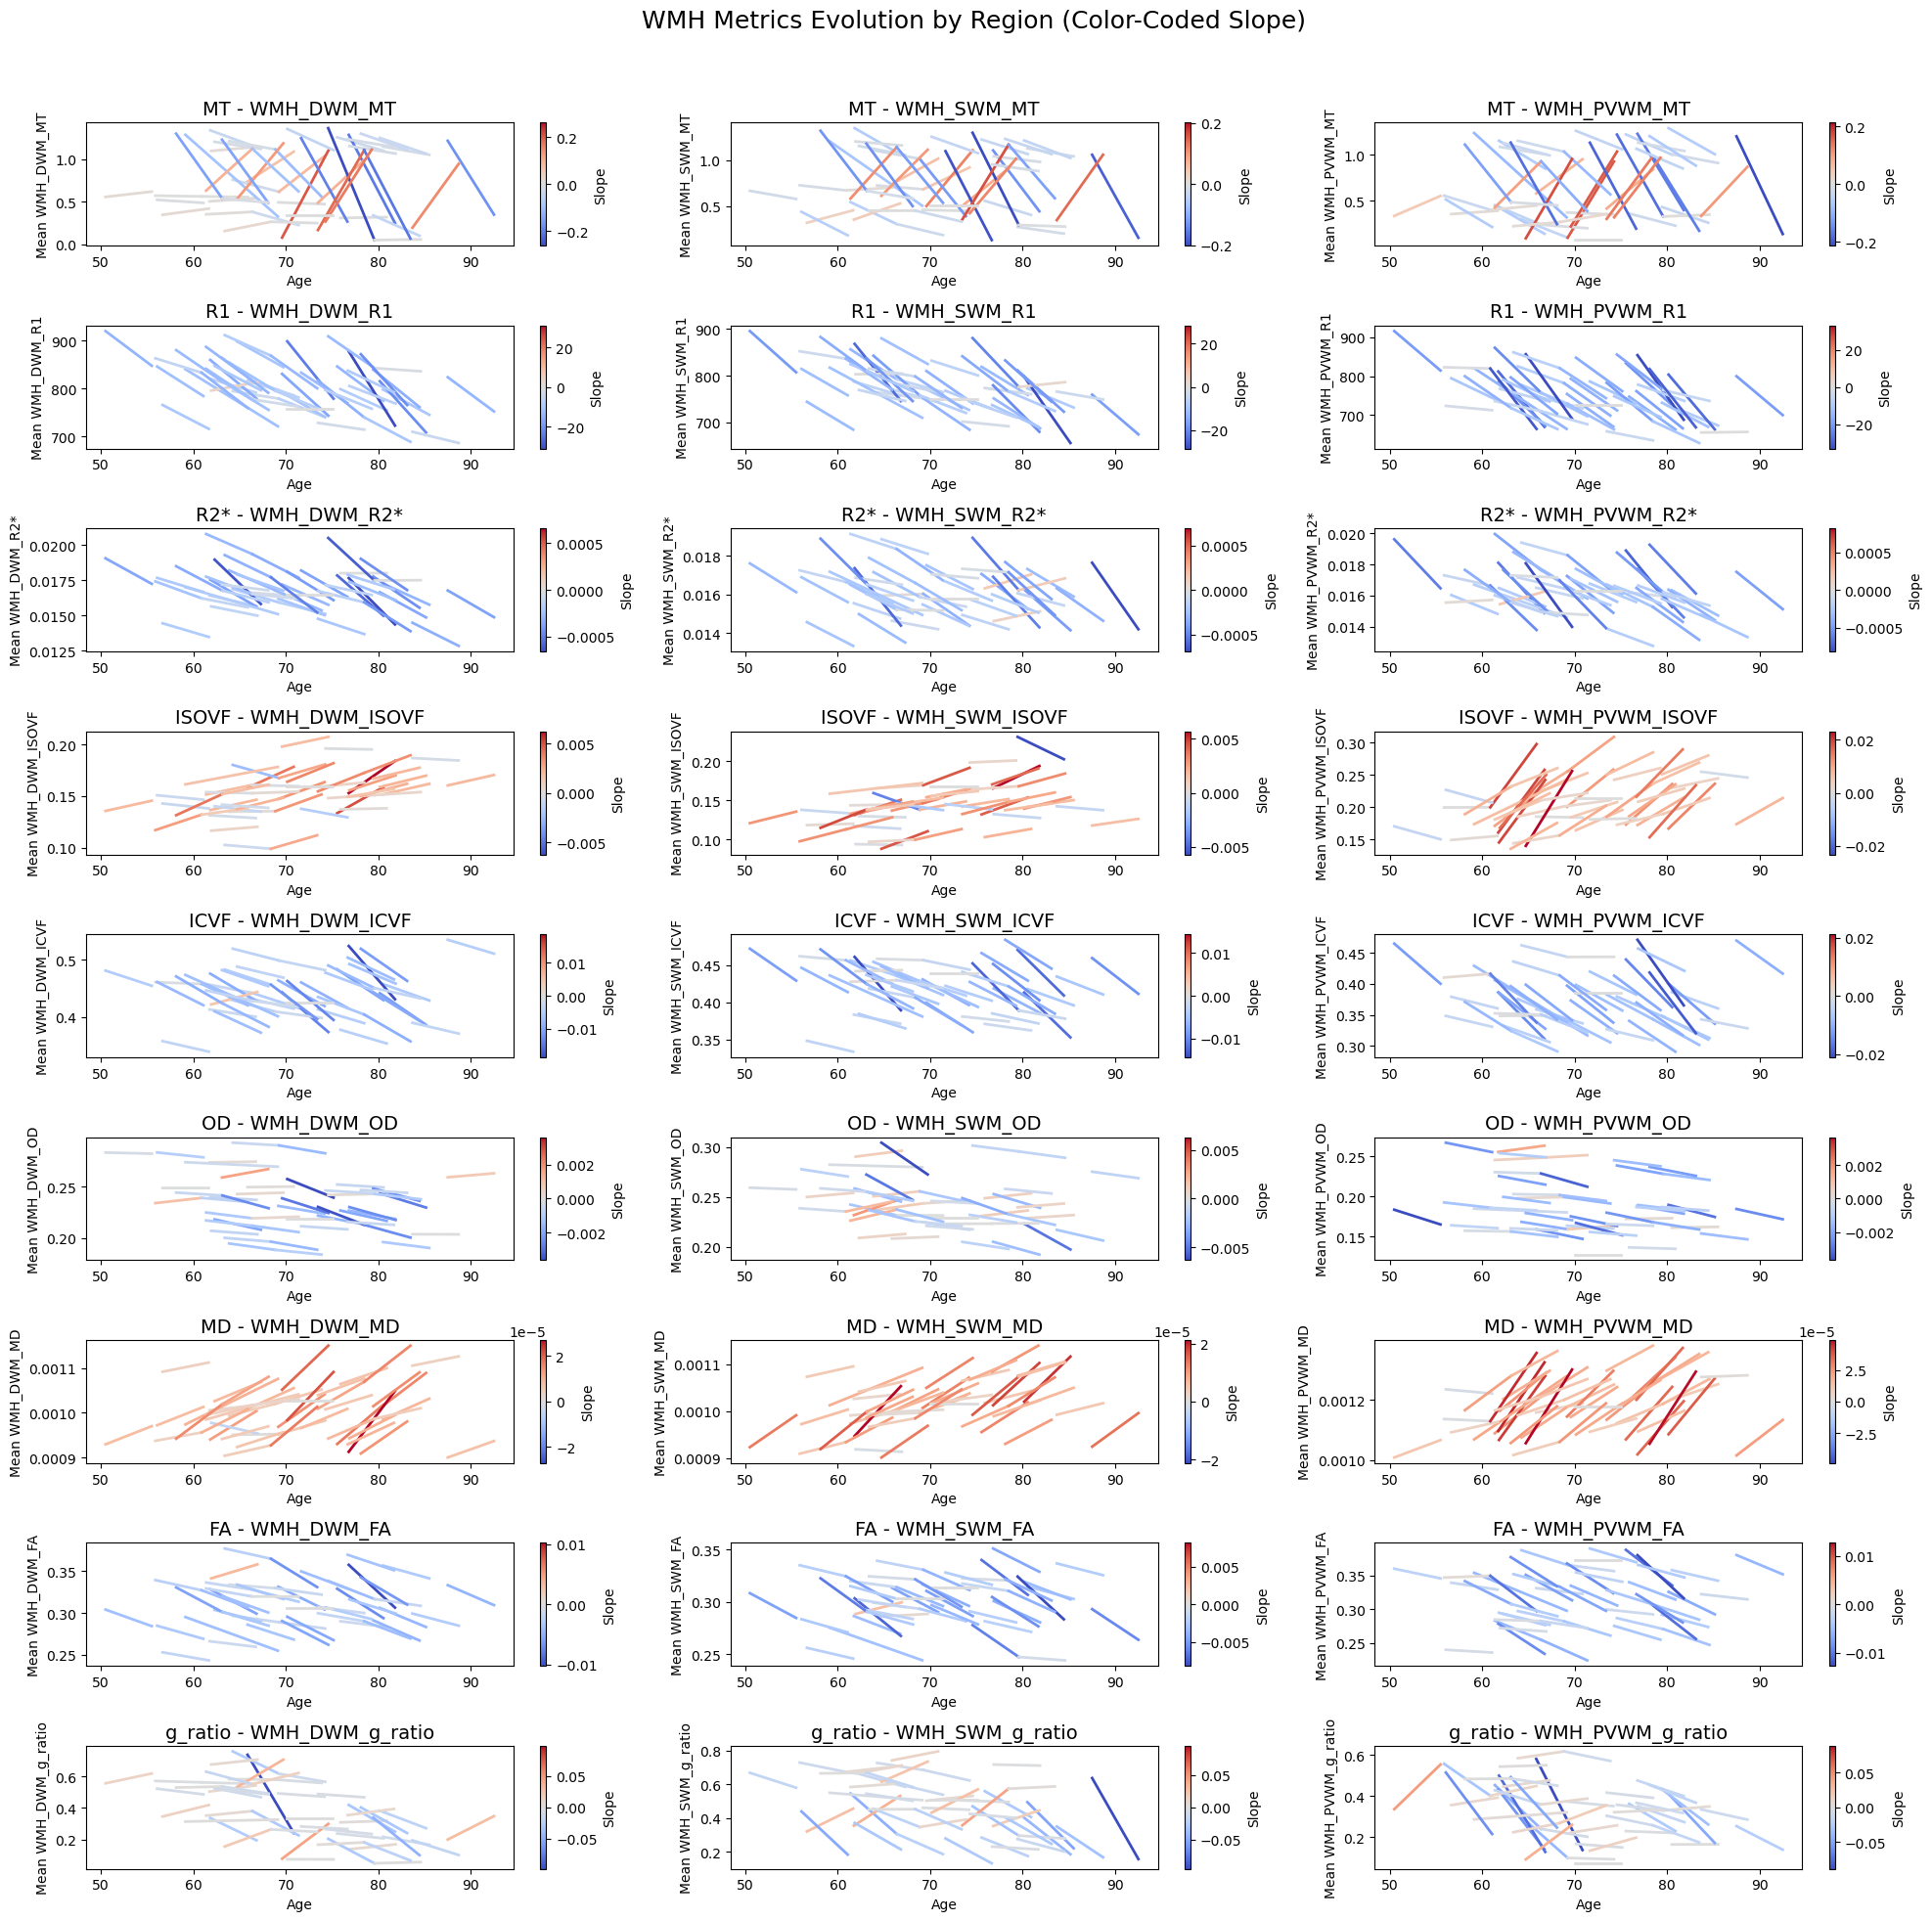

In [228]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# List of metrics to plot, organized by region
metrics_by_region = {
    'MT': ['WMH_DWM_MT', 'WMH_SWM_MT', 'WMH_PVWM_MT'],
    'R1': ['WMH_DWM_R1', 'WMH_SWM_R1', 'WMH_PVWM_R1'],
    'R2*': ['WMH_DWM_R2*', 'WMH_SWM_R2*', 'WMH_PVWM_R2*'],
    'ISOVF': ['WMH_DWM_ISOVF', 'WMH_SWM_ISOVF', 'WMH_PVWM_ISOVF'],
    'ICVF': ['WMH_DWM_ICVF', 'WMH_SWM_ICVF', 'WMH_PVWM_ICVF'],
    'OD': ['WMH_DWM_OD', 'WMH_SWM_OD', 'WMH_PVWM_OD'],
    'MD': ['WMH_DWM_MD', 'WMH_SWM_MD', 'WMH_PVWM_MD'],
    'FA': ['WMH_DWM_FA', 'WMH_SWM_FA', 'WMH_PVWM_FA'],
    'g_ratio': ['WMH_DWM_g_ratio', 'WMH_SWM_g_ratio', 'WMH_PVWM_g_ratio']
}

# Function to remove outliers by metric (values more than 2 SD from the mean)
def remove_outliers(df, metric):
    mean = df[metric].mean()
    std = df[metric].std()
    lower_bound = mean - 2 * std
    upper_bound = mean + 2 * std
    return df[(df[metric] >= lower_bound) & (df[metric] <= upper_bound)]

# Sort merged_df by 'long_PR' and 'Age'
merged_df_sorted = merged_df.sort_values(by=['long_PR', 'Age'])

# Apply outlier removal for each metric
for metric_list in metrics_by_region.values():
    for metric in metric_list:
        merged_df_sorted = remove_outliers(merged_df_sorted, metric)

# Set up the grid for subplots (1 row per metric type, 3 columns for regions)
fig, axes = plt.subplots(len(metrics_by_region), 3, figsize=(20, 20))  # 9 rows, 3 columns
axes = axes.flatten()  # Flatten to easily index with a loop

# Loop through each metric category (e.g., 'MT', 'R1', etc.)
for row_idx, (metric_type, metrics) in enumerate(metrics_by_region.items()):
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx * 3 + col_idx]  # Access each subplot in the grid

        # Calculate slope within each group
        def calculate_slope(group):
            group['slope'] = (group[metric].shift(-1) - group[metric]) / (group['Age'].shift(-1) - group['Age'])
            return group

        region_metric_df = merged_df_sorted.groupby('long_PR', group_keys=False).apply(calculate_slope)

        # Normalize slope symmetrically around zero
        max_slope = abs(region_metric_df['slope']).max()
        norm = plt.Normalize(-max_slope, max_slope)
        cmap = plt.get_cmap("coolwarm")

        # Plot colored line segments
        for long_pr, group in region_metric_df.groupby('long_PR'):
            for i in range(len(group) - 1):
                x1, x2 = group.iloc[i]['Age'], group.iloc[i + 1]['Age']
                y1, y2 = group.iloc[i][metric], group.iloc[i + 1][metric]
                slope = group.iloc[i]['slope']
                color = cmap(norm(slope))
                ax.plot([x1, x2], [y1, y2], color=color, lw=2)

        # Set titles and labels
        ax.set_title(f'{metric_type} - {metric}', fontsize=14)
        ax.set_xlabel('Age')
        ax.set_ylabel(f'Mean {metric}')

        # Colorbar per plot (optional — comment if you want one global colorbar instead)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        fig.colorbar(sm, ax=ax, orientation='vertical', label='Slope')

# Tidy up layout
plt.suptitle('WMH Metrics Evolution by Region (Color-Coded Slope)', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust for title and labels
plt.show()


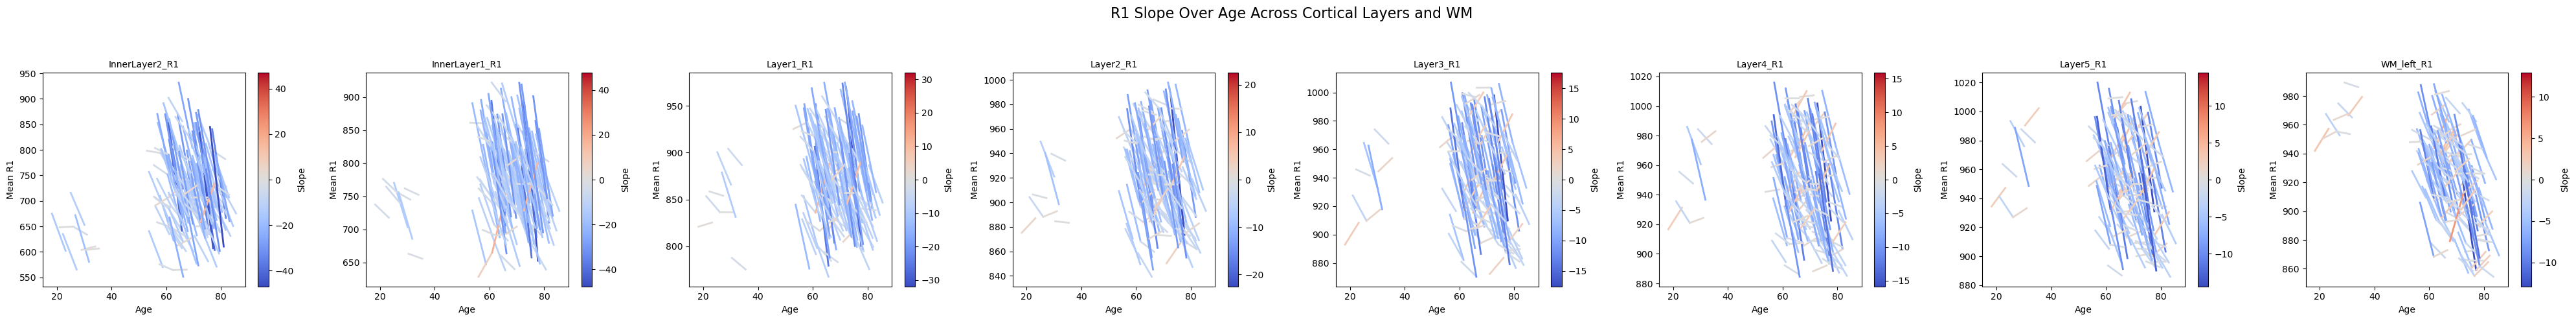

In [230]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# List of R1 metrics across layers and WM
layer_metrics = ['InnerLayer2_R1', 'InnerLayer1_R1', 'Layer1_R1', 'Layer2_R1',
                 'Layer3_R1', 'Layer4_R1', 'Layer5_R1', 'WM_left_R1']

# Function to remove outliers by metric (values more than 2 SD from the mean)
def remove_outliers(df, metric):
    mean = df[metric].mean()
    std = df[metric].std()
    lower_bound = mean - 2 * std
    upper_bound = mean + 2 * std
    return df[(df[metric] >= lower_bound) & (df[metric] <= upper_bound)]

# Sort and clean dataframe
merged_df_sorted = merged_df.sort_values(by=['long_PR', 'Age'])
for metric in layer_metrics:
    merged_df_sorted = remove_outliers(merged_df_sorted, metric)

# Create subplots — 1 row, 8 columns
fig, axes = plt.subplots(1, len(layer_metrics), figsize=(40, 5))

# Loop over each layer metric
for idx, metric in enumerate(layer_metrics):
    ax = axes[idx]

    # Calculate slope within each subject group
    def calculate_slope(group):
        group['slope'] = (group[metric].shift(-1) - group[metric]) / (group['Age'].shift(-1) - group['Age'])
        return group

    metric_df = merged_df_sorted.groupby('long_PR', group_keys=False).apply(calculate_slope)

    # Normalize slope symmetrically
    max_slope = abs(metric_df['slope']).max()
    norm = plt.Normalize(-max_slope, max_slope)
    cmap = plt.get_cmap("coolwarm")

    # Plot colored line segments
    for long_pr, group in metric_df.groupby('long_PR'):
        for i in range(len(group) - 1):
            x1, x2 = group.iloc[i]['Age'], group.iloc[i + 1]['Age']
            y1, y2 = group.iloc[i][metric], group.iloc[i + 1][metric]
            slope = group.iloc[i]['slope']
            color = cmap(norm(slope))
            ax.plot([x1, x2], [y1, y2], color=color, lw=2)

    ax.set_title(metric, fontsize=10)
    ax.set_xlabel('Age')
    ax.set_ylabel('Mean R1')

    # Optional: individual colorbars
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, orientation='vertical', label='Slope')

# Layout and title
plt.suptitle('R1 Slope Over Age Across Cortical Layers and WM', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


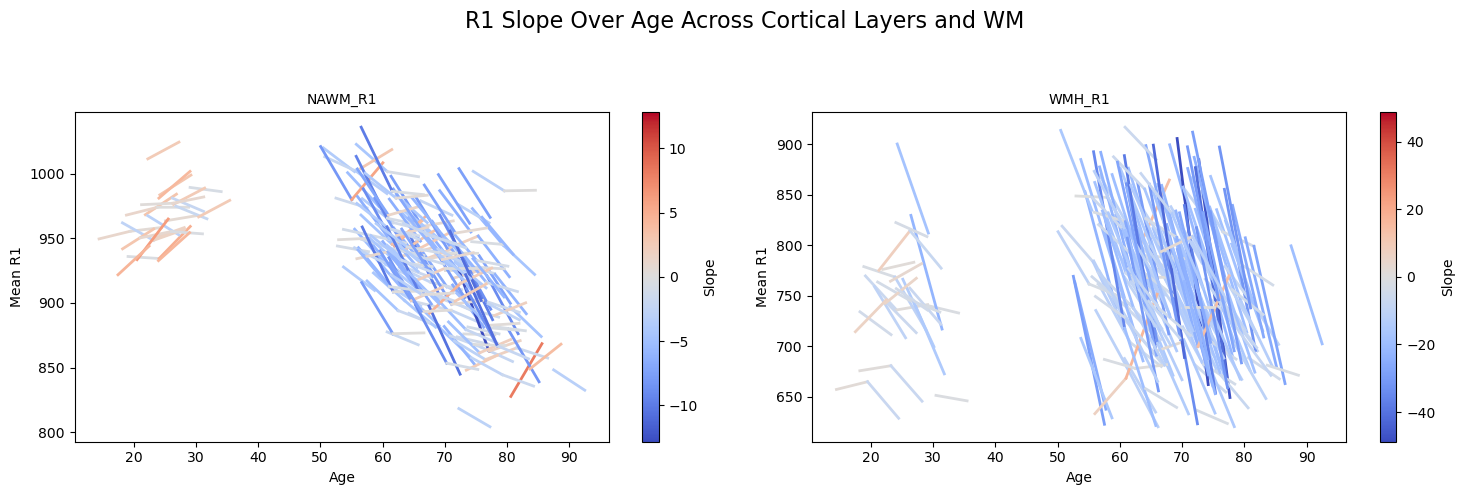

In [231]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# List of R1 metrics across layers and WM
layer_metrics = ['NAWM_R1', 'WMH_R1']

# Function to remove outliers by metric (values more than 2 SD from the mean)
def remove_outliers(df, metric):
    mean = df[metric].mean()
    std = df[metric].std()
    lower_bound = mean - 2 * std
    upper_bound = mean + 2 * std
    return df[(df[metric] >= lower_bound) & (df[metric] <= upper_bound)]

# Sort and clean dataframe
merged_df_sorted = merged_df.sort_values(by=['long_PR', 'Age'])
for metric in layer_metrics:
    merged_df_sorted = remove_outliers(merged_df_sorted, metric)

# Create subplots — 1 row, 8 columns
fig, axes = plt.subplots(1, len(layer_metrics), figsize=(15, 5))

# Loop over each layer metric
for idx, metric in enumerate(layer_metrics):
    ax = axes[idx]

    # Calculate slope within each subject group
    def calculate_slope(group):
        group['slope'] = (group[metric].shift(-1) - group[metric]) / (group['Age'].shift(-1) - group['Age'])
        return group

    metric_df = merged_df_sorted.groupby('long_PR', group_keys=False).apply(calculate_slope)

    # Normalize slope symmetrically
    max_slope = abs(metric_df['slope']).max()
    norm = plt.Normalize(-max_slope, max_slope)
    cmap = plt.get_cmap("coolwarm")

    # Plot colored line segments
    for long_pr, group in metric_df.groupby('long_PR'):
        for i in range(len(group) - 1):
            x1, x2 = group.iloc[i]['Age'], group.iloc[i + 1]['Age']
            y1, y2 = group.iloc[i][metric], group.iloc[i + 1][metric]
            slope = group.iloc[i]['slope']
            color = cmap(norm(slope))
            ax.plot([x1, x2], [y1, y2], color=color, lw=2)

    ax.set_title(metric, fontsize=10)
    ax.set_xlabel('Age')
    ax.set_ylabel('Mean R1')

    # Optional: individual colorbars
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, orientation='vertical', label='Slope')

# Layout and title
plt.suptitle('R1 Slope Over Age Across Cortical Layers and WM', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


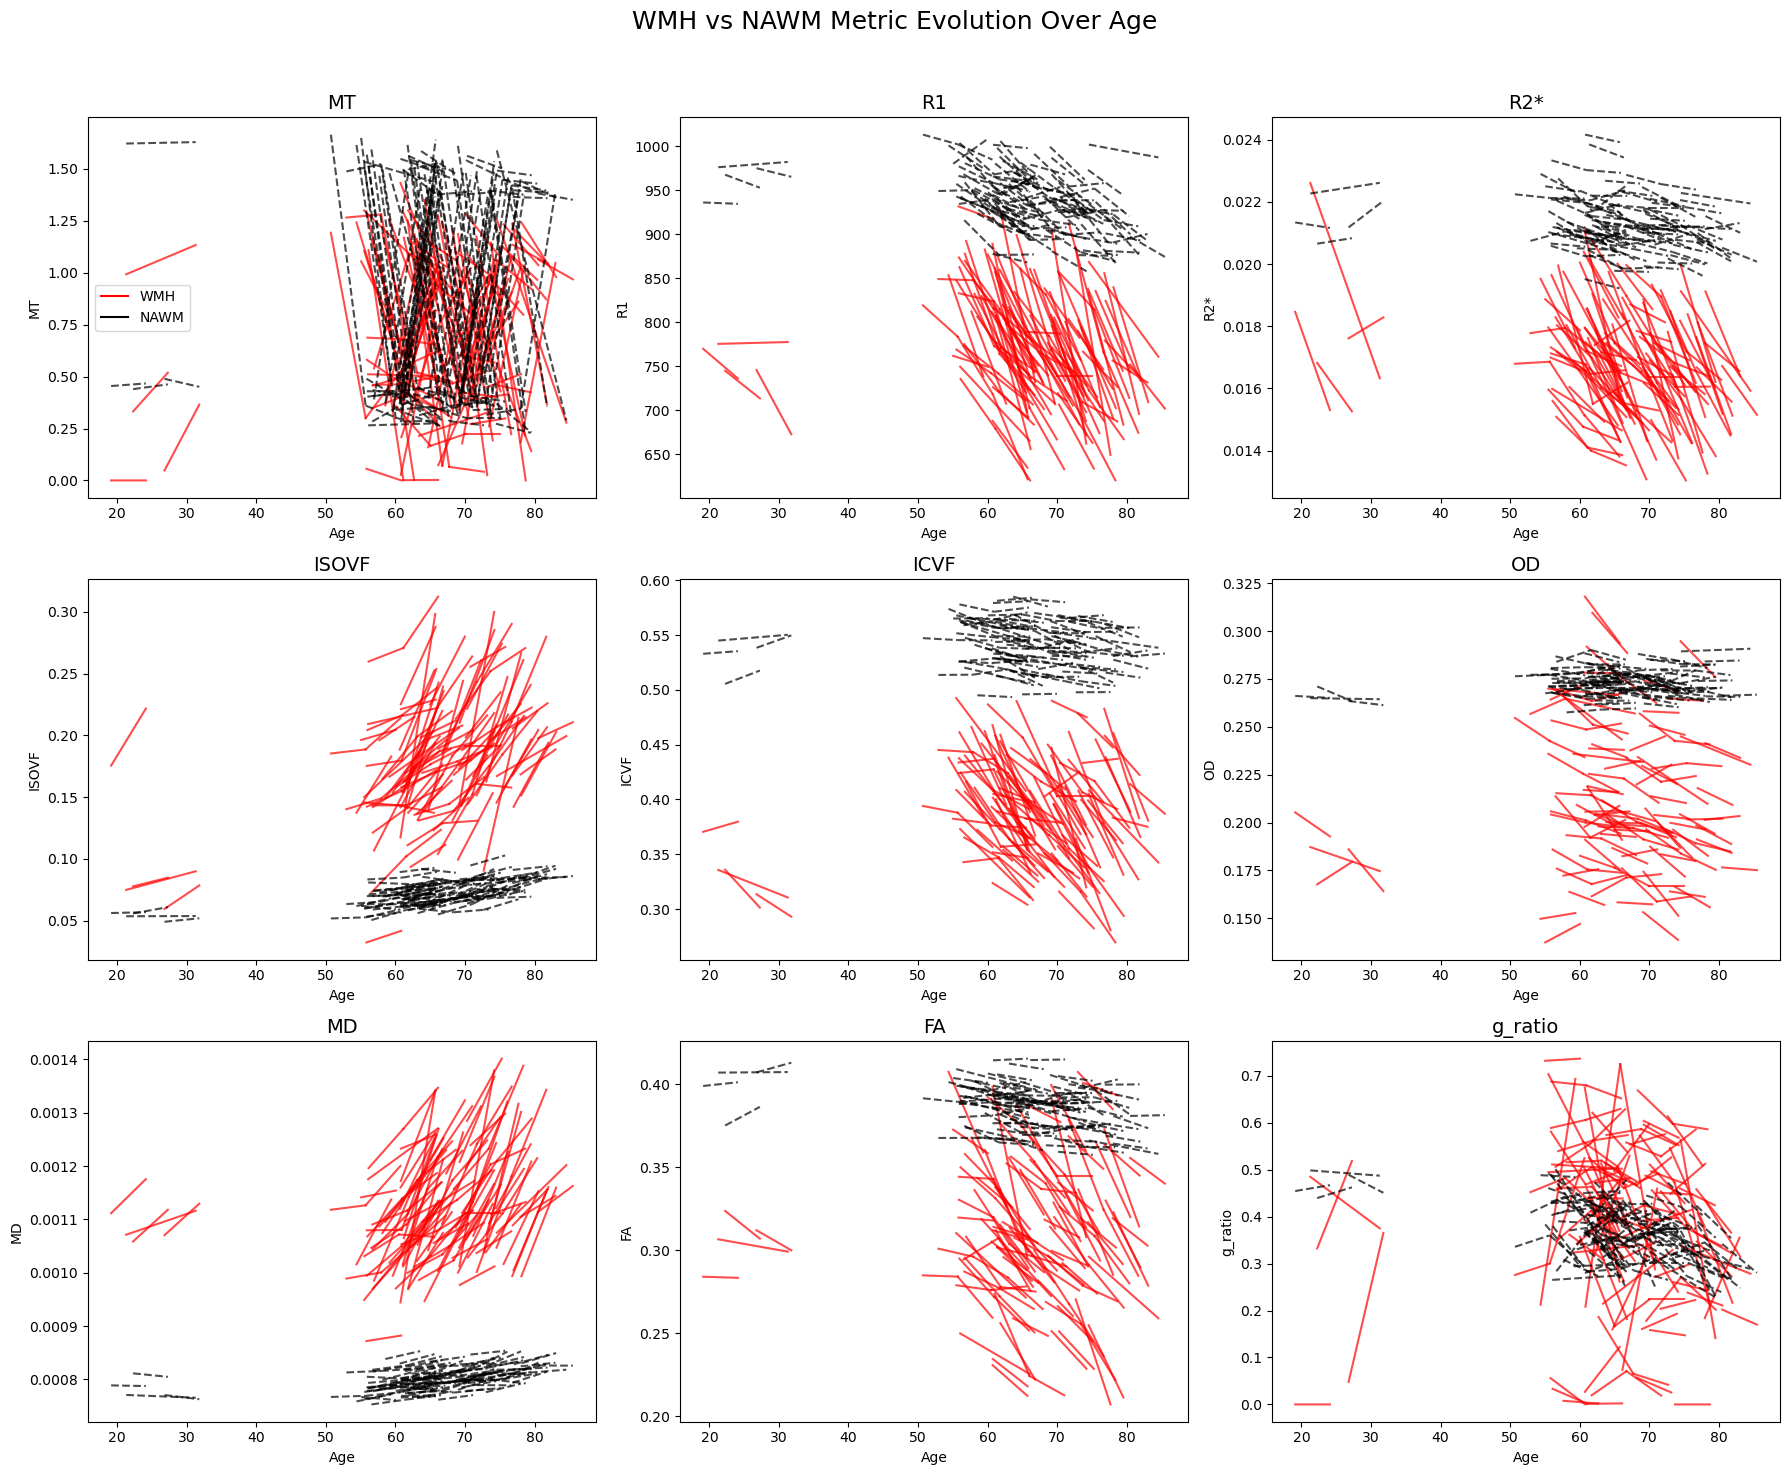

In [235]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

# Define metrics and tissue types
base_metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g_ratio']
wm_types = ['WMH', 'NAWM']

# Function to remove outliers
def remove_outliers(df, metric):
    mean = df[metric].mean()
    std = df[metric].std()
    lower, upper = mean - 2 * std, mean + 2 * std
    return df[(df[metric] >= lower) & (df[metric] <= upper)]

# Sort and clean data
merged_df_sorted = merged_df.sort_values(by=['long_PR', 'Age'])
for base in base_metrics:
    for wm in wm_types:
        merged_df_sorted = remove_outliers(merged_df_sorted, f"{wm}_{base}")

# Set up subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Plot each metric
for idx, base in enumerate(base_metrics):
    ax = axes[idx]

    # Plot WMH and NAWM lines
    for wm in wm_types:
        metric = f"{wm}_{base}"

        def calc_slope(group):
            group[f'{metric}_slope'] = (group[metric].shift(-1) - group[metric]) / (group['Age'].shift(-1) - group['Age'])
            return group

        merged_df_sorted = merged_df_sorted.groupby('long_PR', group_keys=False).apply(calc_slope)

        # Choose style
        color = 'red' if wm == 'WMH' else 'black'
        linestyle = '-' if wm == 'WMH' else '--'

        # Plot individual subject lines
        for long_pr, group in merged_df_sorted.groupby('long_PR'):
            for i in range(len(group) - 1):
                x1, x2 = group.iloc[i]['Age'], group.iloc[i + 1]['Age']
                y1, y2 = group.iloc[i][metric], group.iloc[i + 1][metric]
                if pd.notna(y1) and pd.notna(y2):  # Avoid plotting if NaNs
                    ax.plot([x1, x2], [y1, y2], color=color, linestyle=linestyle, alpha=0.7)

    ax.set_title(base, fontsize=14)
    ax.set_xlabel('Age')
    ax.set_ylabel(base)

    # Add legend only to first plot
    if idx == 0:
        ax.plot([], [], color='red', label='WMH')
        ax.plot([], [], color='black', label='NAWM')
        ax.legend()

# Final layout
plt.suptitle('WMH vs NAWM Metric Evolution Over Age', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


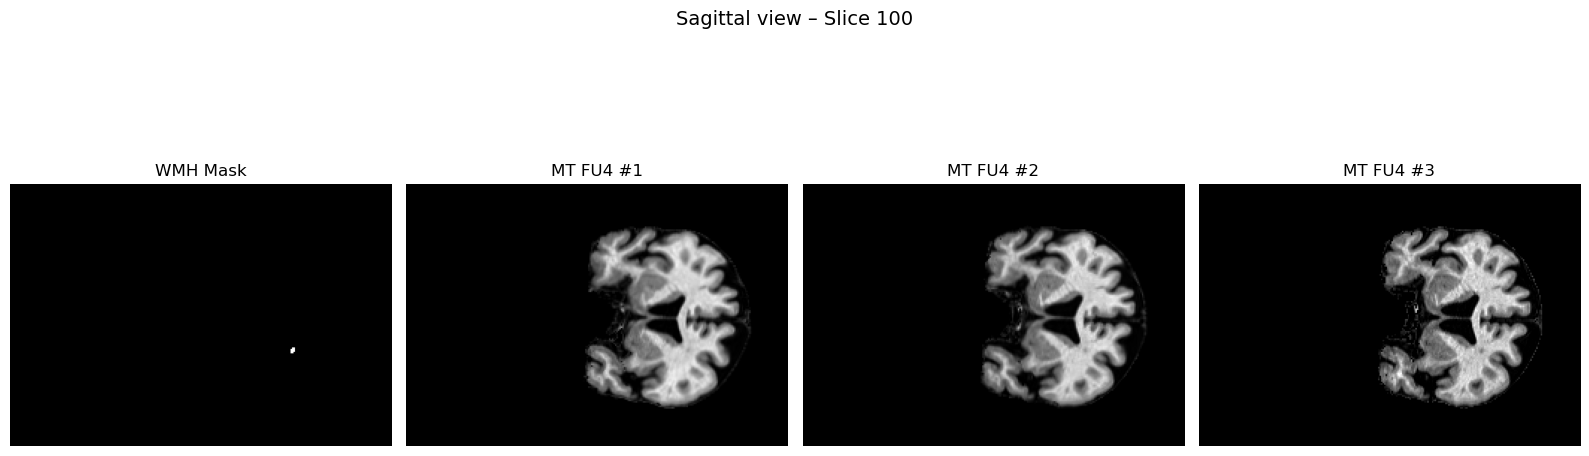

In [353]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- Setup ---
longitudinalPR = 'sPR05731_PB200451'
view = 'sagittal'  # Choose from: 'axial', 'coronal', 'sagittal'
slice_index = 100   # Adjust depending on the chosen view

# --- Paths ---
wmh_file_path = glob.glob(
    os.path.join(dir_path, 'FLAIR', longitudinalPR, f'whitenet_FLAIR_WMH_sanlm_m{longitudinalPR}*_in_MPRAGE_masked_in_MPM_clea*.nii.gz')
)
mt_file_paths = sorted(glob.glob(
    os.path.join(mpm_path, longitudinalPR, '*MT_masked*FU4*nii.gz')
))

assert wmh_file_path, "WMH file not found"
assert mt_file_paths, "No MT FU4 files found"

# --- Load WMH Mask ---
wmh_img = nib.load(wmh_file_path[0])
wmh_data = wmh_img.get_fdata()

# --- Load MT FU4 Images ---
mt_data_list = [nib.load(f).get_fdata() for f in mt_file_paths]

# --- Function to get slice by view ---
def get_slice(data, view, index):
    if view == 'axial':
        return data[:, :, index].T
    elif view == 'coronal':
        return data[:, index, :].T
    elif view == 'sagittal':
        return data[index, :, :].T
    else:
        raise ValueError("Invalid view. Choose from 'axial', 'coronal', or 'sagittal'.")

# --- Plotting ---
n_cols = len(mt_data_list) + 1
plt.figure(figsize=(4 * n_cols, 6))

# Plot WMH mask
plt.subplot(1, n_cols, 1)
plt.imshow(get_slice(wmh_data, view, slice_index), cmap='gray', origin='lower')
plt.title('WMH Mask')
plt.axis('off')


# Plot each MT image
for i, mt_data in enumerate(mt_data_list):
    plt.subplot(1, n_cols, i + 2)
    plt.imshow(get_slice(mt_data, view, slice_index), cmap='gray', origin='lower', vmin=0, vmax=2)
    plt.title(f'MT FU4 #{i+1}')
    plt.axis('off')

plt.suptitle(f'{view.capitalize()} view – Slice {slice_index}', fontsize=14)
plt.tight_layout()
plt.show()


In [354]:
import numpy as np
import nibabel as nib
import os
import glob

# --- Load WMH mask ---
wmh_img = nib.load(wmh_file_path[0])
wmh_data = wmh_img.get_fdata()

# Ensure mask is binary
wmh_mask = wmh_data == 1

# --- Compute mean MT in WMH=1 voxels for each scan ---
mt_means_in_wmh = {}

for mt_path in mt_file_paths:
    mt_img = nib.load(mt_path)
    mt_data = mt_img.get_fdata()
    
    # Apply WMH mask and compute mean
    masked_mt_values = mt_data[wmh_mask]
    mean_val = np.mean(masked_mt_values)
    
    mt_means_in_wmh[os.path.basename(mt_path)] = mean_val

# --- Display results ---
for fname, mean_val in mt_means_in_wmh.items():
    print(f"{fname}: mean MT in WMH = {mean_val:.4f}")


sPR01015_PB200451-0005-00001-000176-01_MT_masked_in_FU4.nii.gz: mean MT in WMH = 1.1942
sPR04339_PB200451-0011-00001-000176-01_MT_masked_in_FU4.nii.gz: mean MT in WMH = 1.1066
sPR05731_PB200451-0012-00001-000176-01_MT_masked_in_FU4.nii.gz: mean MT in WMH = 1.0220


In [331]:
subset = merged_df[merged_df['long_PR'] == 'sPR05731_PB200451'][['long_PR', 'file_PR', 'Age', 'WMH_MT']]
print(subset)


              long_PR  file_PR    Age    WMH_MT
11  sPR05731_PB200451  PR01015  60.85  0.208250
12  sPR05731_PB200451  PR04339  65.85  0.724688
13  sPR05731_PB200451  PR05731  70.85  1.021965


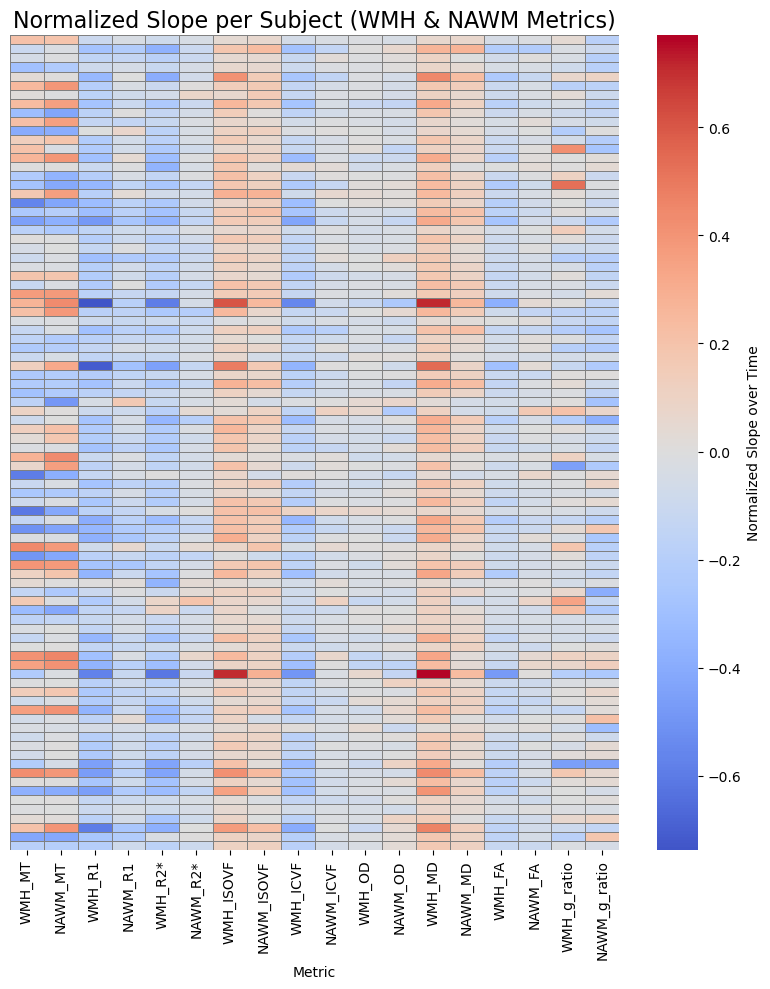

In [291]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Base definitions
base_metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g_ratio']
wm_types = ['WMH', 'NAWM']
metrics = [f"{wm}_{metric}" for metric in base_metrics for wm in wm_types]

# Step 1: Sort data by subject and age
merged_df_sorted = merged_df.sort_values(by=['long_PR', 'Age']).copy()

# Step 2: Remove outlier rows per metric (using ±2SD of global mean)
filtered_df = merged_df_sorted.copy()  # Start with the whole dataset

for metric in metrics:
    metric_mean = filtered_df[metric].mean()
    metric_std = filtered_df[metric].std()
    lower_bound = metric_mean - 2 * metric_std
    upper_bound = metric_mean + 2 * metric_std

    # Remove rows where the metric value is outside ±2SD
    filtered_df = filtered_df[filtered_df[metric].between(lower_bound, upper_bound)]

# Step 3: Normalize each metric across subjects (using the mean and std per column)
normalized_df = filtered_df.copy()
for metric in metrics:
    metric_mean = filtered_df[metric].mean()
    metric_std = filtered_df[metric].std()
    
    # Normalize by subtracting the mean and dividing by the std (across subjects)
    normalized_df[metric] = (filtered_df[metric] - metric_mean) / metric_std

# Step 4: Compute slopes for each metric by subject
slope_data = []

for metric in metrics:
    temp = normalized_df[['long_PR', 'Age', metric]].copy()
    
    def compute_slopes(group):
        # Calculate the difference in age and the difference in metric values
        age_diff = group['Age'].diff()
        val_diff = group[metric].diff()
        
        # Calculate the slope as the ratio of the differences
        slope = val_diff / age_diff
        return slope

    # Apply slope calculation for each subject
    slopes = normalized_df.groupby('long_PR').apply(lambda g: compute_slopes(g)).reset_index(level=0)
    slopes.columns = ['long_PR', 'slope']
    slopes['metric'] = metric

    # Average the slope per subject for each metric
    avg_slopes = slopes.groupby('long_PR')['slope'].mean().reset_index()
    avg_slopes['metric'] = metric
    slope_data.append(avg_slopes)

# Step 5: Create heatmap matrix from slopes
slope_df = pd.concat(slope_data)
heatmap_data = slope_df.pivot(index='long_PR', columns='metric', values='slope')

# Step 5.1: Sort columns in interleaved WMH/NAWM pairs per metric type
ordered_columns = []
for metric in base_metrics:
    ordered_columns.append(f'WMH_{metric}')
    ordered_columns.append(f'NAWM_{metric}')
heatmap_data = heatmap_data[ordered_columns]

# Step 5.2: Remove rows (subjects) with all NaNs
heatmap_data = heatmap_data.dropna(how='all')

wmh_columns = [col for col in heatmap_data.columns if col.startswith("WMH_")]
heatmap_data = heatmap_data[~heatmap_data[wmh_columns].isna().all(axis=1)]

# Step 6: Plot the heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Normalized Slope over Time'},
    yticklabels=False  # This hides the subject (long_PR) labels
)

plt.title('Normalized Slope per Subject (WMH & NAWM Metrics)', fontsize=16)
plt.xlabel('Metric')
plt.ylabel('')  # Optional: also clear axis label text
plt.tight_layout()
plt.show()


In [ ]:
normalized_df

In [275]:
filtered_df['WMH_OD']

0      0.173933
1      0.171091
2      0.397937
3      0.382227
4      0.234811
         ...   
487    0.194036
488    0.192477
490    0.193365
489    0.191651
491    0.183009
Name: WMH_OD, Length: 8363, dtype: float64

In [292]:
heatmap_data

metric,WMH_MT,NAWM_MT,WMH_R1,NAWM_R1,WMH_R2*,NAWM_R2*,WMH_ISOVF,NAWM_ISOVF,WMH_ICVF,NAWM_ICVF,WMH_OD,NAWM_OD,WMH_MD,NAWM_MD,WMH_FA,NAWM_FA,WMH_g_ratio,NAWM_g_ratio
long_PR,,,,,,,,,,,,,,,,,,
sPR05731_PB200451,0.209708,0.198915,-0.096882,-0.034542,-0.082138,-0.037715,0.043264,0.062507,-0.059077,-0.027309,-0.012918,-0.041068,0.061532,0.067769,-0.045595,-0.017835,0.043341,-0.180232
sPR05736_IT120841,-0.101094,-0.023100,-0.278726,-0.214377,-0.369069,-0.105021,0.186422,0.235198,-0.283738,-0.138280,0.001951,0.060779,0.265648,0.269995,-0.208024,-0.216930,-0.029731,-0.100922
sPR05739_HO200936,-0.049144,-0.010980,-0.151041,-0.134187,-0.180710,-0.102534,0.050666,0.051404,-0.116707,0.024287,-0.007605,0.015925,0.094327,-0.003949,-0.070665,0.007082,-0.034671,-0.195037
sPR05745_VS160649,-0.294546,-0.223273,-0.084186,-0.050314,-0.114889,-0.047500,0.059719,0.052006,-0.091237,-0.015632,-0.015512,0.006239,0.080416,0.041488,-0.040493,-0.033731,-0.078607,-0.184887
sPR05753_EM200244,0.032844,0.010558,-0.336359,-0.004287,-0.392453,-0.068491,0.407059,0.147499,-0.262545,-0.144188,-0.018272,-0.058684,0.446541,0.232128,-0.235092,-0.116615,0.069313,0.093159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sPR06688_BH211255,-0.008492,-0.003530,-0.100292,-0.041189,-0.079314,-0.045563,0.049174,0.018622,-0.063009,-0.025835,-0.039840,-0.061234,0.073449,0.041429,-0.026346,0.001869,-0.017921,-0.031142
sPR06691_EL060251,0.029409,0.011082,-0.172197,-0.055060,-0.262176,-0.079555,0.085781,-0.004764,-0.169236,-0.015165,-0.025133,0.097937,0.145972,-0.000399,-0.116448,-0.071100,0.062064,0.097775
sPR06694_JK210857,0.204343,0.397081,-0.590314,-0.264603,-0.383475,-0.001480,0.371618,0.222280,-0.396584,-0.001491,-0.110814,0.046598,0.467384,0.132101,-0.154907,-0.066996,-0.090734,-0.139713


<Figure size 800x600 with 0 Axes>

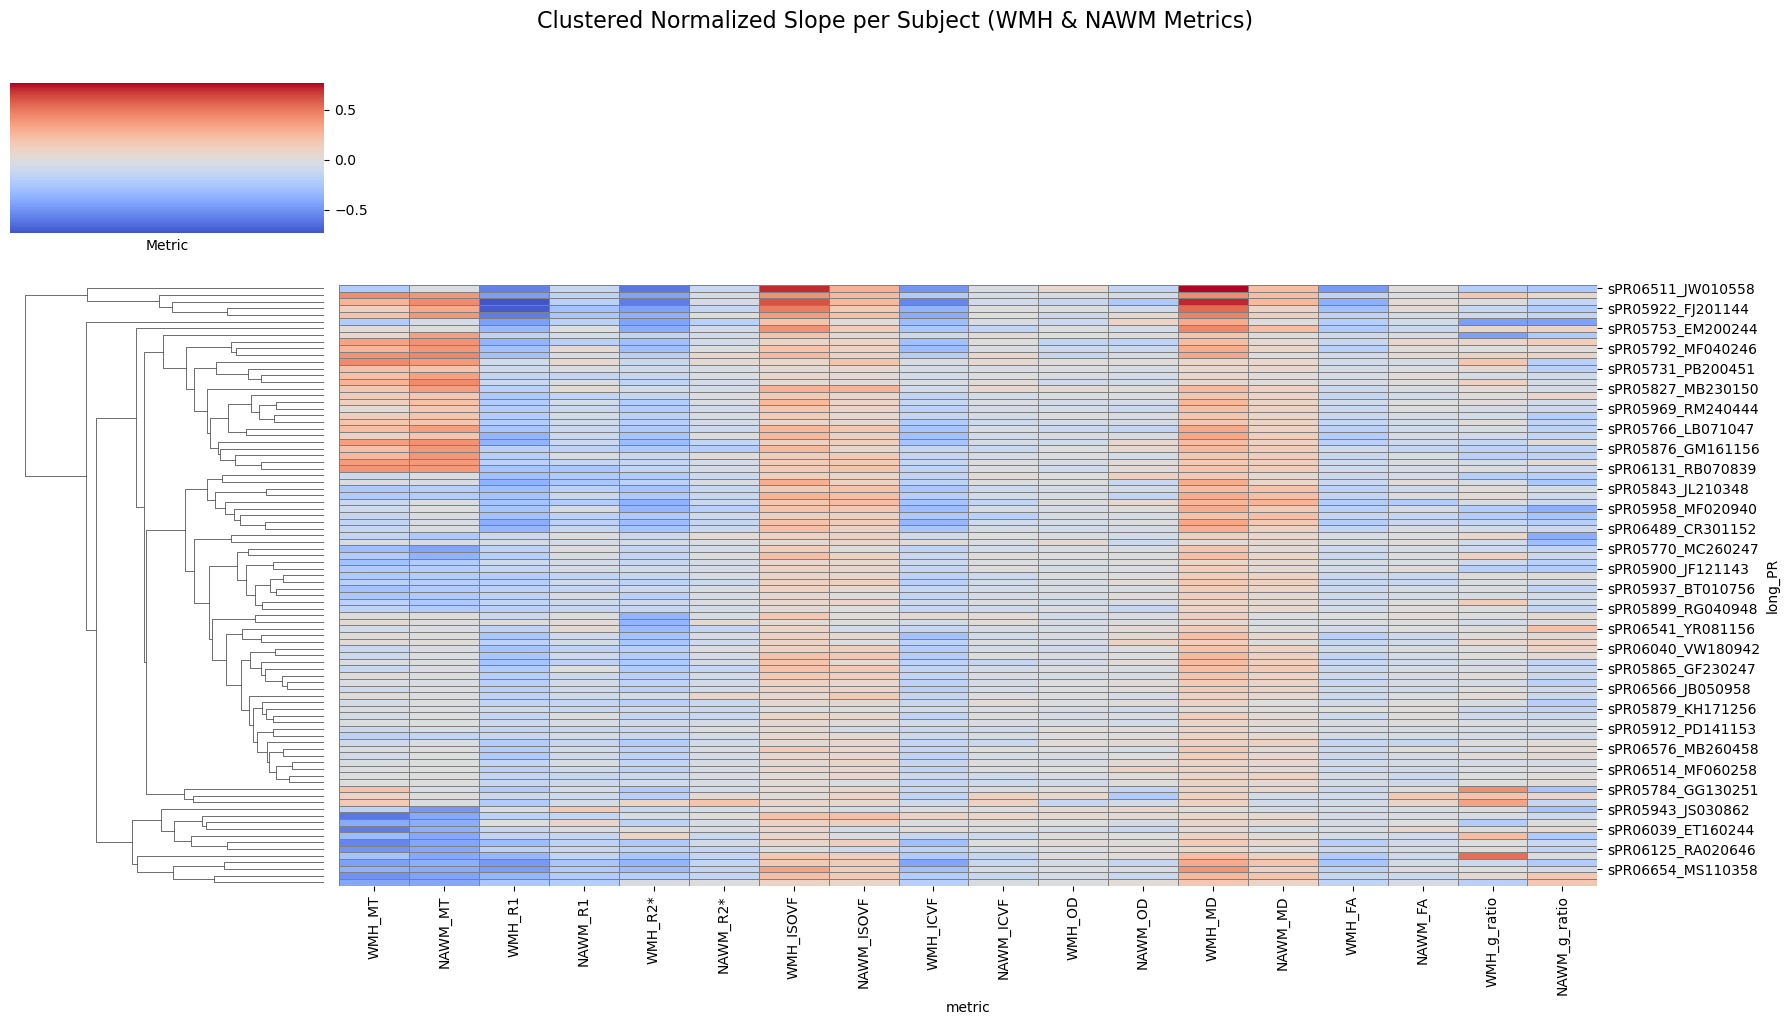

In [305]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Base definitions
base_metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g_ratio']
wm_types = ['WMH', 'NAWM']
metrics = [f"{wm}_{metric}" for metric in base_metrics for wm in wm_types]

# Step 1: Sort data by subject and age
merged_df_sorted = merged_df.sort_values(by=['long_PR', 'Age']).copy()

# Step 2: Remove outlier rows per metric (using ±2SD of global mean)
filtered_df = merged_df_sorted.copy()  # Start with the whole dataset

for metric in metrics:
    metric_mean = filtered_df[metric].mean()
    metric_std = filtered_df[metric].std()
    lower_bound = metric_mean - 2 * metric_std
    upper_bound = metric_mean + 2 * metric_std

    # Remove rows where the metric value is outside ±2SD
    filtered_df = filtered_df[filtered_df[metric].between(lower_bound, upper_bound)]

# Step 3: Normalize each metric across subjects (using the mean and std per column)
normalized_df = filtered_df.copy()
for metric in metrics:
    metric_mean = filtered_df[metric].mean()
    metric_std = filtered_df[metric].std()
    
    # Normalize by subtracting the mean and dividing by the std (across subjects)
    normalized_df[metric] = (filtered_df[metric] - metric_mean) / metric_std

# Step 4: Compute slopes for each metric by subject
slope_data = []

for metric in metrics:
    temp = normalized_df[['long_PR', 'Age', metric]].copy()
    
    def compute_slopes(group):
        # Calculate the difference in age and the difference in metric values
        age_diff = group['Age'].diff()
        val_diff = group[metric].diff()
        
        # Calculate the slope as the ratio of the differences
        slope = val_diff / age_diff
        return slope

    # Apply slope calculation for each subject
    slopes = normalized_df.groupby('long_PR').apply(lambda g: compute_slopes(g)).reset_index(level=0)
    slopes.columns = ['long_PR', 'slope']
    slopes['metric'] = metric

    # Average the slope per subject for each metric
    avg_slopes = slopes.groupby('long_PR')['slope'].mean().reset_index()
    avg_slopes['metric'] = metric
    slope_data.append(avg_slopes)

# Step 5: Create heatmap matrix from slopes
slope_df = pd.concat(slope_data)
heatmap_data = slope_df.pivot(index='long_PR', columns='metric', values='slope')

# Step 5.1: Sort columns in interleaved WMH/NAWM pairs per metric type
ordered_columns = []
for metric in base_metrics:
    ordered_columns.append(f'WMH_{metric}')
    ordered_columns.append(f'NAWM_{metric}')
heatmap_data = heatmap_data[ordered_columns]

# Step 5.2: Remove rows (subjects) with all NaNs
heatmap_data = heatmap_data.dropna(how='all')

wmh_columns = [col for col in heatmap_data.columns if col.startswith("WMH_")]
heatmap_data = heatmap_data[~heatmap_data[wmh_columns].isna().all(axis=1)]

heatmap_data = heatmap_data.dropna(how='any')  # Remove any row with NaN values

# Step 6: Plot
plt.figure(figsize=(8, 6))
sns.clustermap(
    heatmap_data,
    cmap="coolwarm",
    center=0,
    col_cluster=False,     # Cluster only rows (subjects)
    row_cluster=True,  
    method='average',     # Change the linkage method here# Enable clustering by rows
    linewidths=0.5,
    linecolor='gray',
    figsize=(18, 10),
    cbar_kws={'label': 'Normalized Slope over Time'}
)

plt.suptitle('Clustered Normalized Slope per Subject (WMH & NAWM Metrics)', fontsize=16, y=1.02)
plt.xlabel('Metric')
plt.ylabel('')  # Optional: also clear axis label text
plt.tight_layout()
plt.show()



In [298]:
heatmap_data

metric,WMH_MT,NAWM_MT,WMH_R1,NAWM_R1,WMH_R2*,NAWM_R2*,WMH_ISOVF,NAWM_ISOVF,WMH_ICVF,NAWM_ICVF,WMH_OD,NAWM_OD,WMH_MD,NAWM_MD,WMH_FA,NAWM_FA,WMH_g_ratio,NAWM_g_ratio
long_PR,,,,,,,,,,,,,,,,,,
sPR05731_PB200451,0.209708,0.198915,-0.096882,-0.034542,-0.082138,-0.037715,0.043264,0.062507,-0.059077,-0.027309,-0.012918,-0.041068,0.061532,0.067769,-0.045595,-0.017835,0.043341,-0.180232
sPR05736_IT120841,-0.101094,-0.023100,-0.278726,-0.214377,-0.369069,-0.105021,0.186422,0.235198,-0.283738,-0.138280,0.001951,0.060779,0.265648,0.269995,-0.208024,-0.216930,-0.029731,-0.100922
sPR05739_HO200936,-0.049144,-0.010980,-0.151041,-0.134187,-0.180710,-0.102534,0.050666,0.051404,-0.116707,0.024287,-0.007605,0.015925,0.094327,-0.003949,-0.070665,0.007082,-0.034671,-0.195037
sPR05745_VS160649,-0.294546,-0.223273,-0.084186,-0.050314,-0.114889,-0.047500,0.059719,0.052006,-0.091237,-0.015632,-0.015512,0.006239,0.080416,0.041488,-0.040493,-0.033731,-0.078607,-0.184887
sPR05753_EM200244,0.032844,0.010558,-0.336359,-0.004287,-0.392453,-0.068491,0.407059,0.147499,-0.262545,-0.144188,-0.018272,-0.058684,0.446541,0.232128,-0.235092,-0.116615,0.069313,0.093159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sPR06688_BH211255,-0.008492,-0.003530,-0.100292,-0.041189,-0.079314,-0.045563,0.049174,0.018622,-0.063009,-0.025835,-0.039840,-0.061234,0.073449,0.041429,-0.026346,0.001869,-0.017921,-0.031142
sPR06691_EL060251,0.029409,0.011082,-0.172197,-0.055060,-0.262176,-0.079555,0.085781,-0.004764,-0.169236,-0.015165,-0.025133,0.097937,0.145972,-0.000399,-0.116448,-0.071100,0.062064,0.097775
sPR06694_JK210857,0.204343,0.397081,-0.590314,-0.264603,-0.383475,-0.001480,0.371618,0.222280,-0.396584,-0.001491,-0.110814,0.046598,0.467384,0.132101,-0.154907,-0.066996,-0.090734,-0.139713


In [300]:
# Order filtered_df by 'long_PR'
ordered_filtered_df = filtered_df[['long_PR', 'Age', 'WMH_MT']].sort_values(by='long_PR')

# Display the ordered dataframe
print(ordered_filtered_df)


               long_PR    Age    WMH_MT
9    sPR05719_PG220250  66.97  1.222815
11   sPR05731_PB200451  60.85  0.208250
12   sPR05731_PB200451  65.85  0.724688
13   sPR05731_PB200451  70.85  1.021965
17   sPR05736_IT120841  75.55  1.232696
..                 ...    ...       ...
487  sPR06701_CC300556  63.09  1.161339
488  sPR06701_CC300556  68.09  0.346656
490  sPR06703_NF170556  58.13  1.188918
489  sPR06703_NF170556  63.13  0.519296
491  sPR06703_NF170556  68.13  0.475589

[266 rows x 3 columns]


In [303]:
import pandas as pd

# Order filtered_df by 'long_PR'
ordered_filtered_df = merged_df[['long_PR', 'file_PR', 'Age', 'WMH_MT']].sort_values(by='long_PR')

# Display the ordered dataframe
# Display the first 100 rows
print(ordered_filtered_df.head(100))



              long_PR  file_PR    Age    WMH_MT
0   sPR05710_JD190636  PR05249  80.63  0.985674
1   sPR05710_JD190636  PR05710  85.63  0.855573
2   sPR05713_SD101257  PR03637  59.17  0.680150
3   sPR05713_SD101257  PR05713  64.17  0.706849
4   sPR05714_NP091046  PR01027  65.34  0.554242
5   sPR05714_NP091046  PR04025  70.34  0.508920
6   sPR05714_NP091046  PR05714  75.34  0.922371
7   sPR05717_JB170499  PR03552  17.82       NaN
8   sPR05717_JB170499  PR05717  22.82       NaN
9   sPR05719_PG220250  PR03358  66.97  1.222815
10  sPR05719_PG220250  PR05719  71.97  0.414040
11  sPR05731_PB200451  PR01015  60.85  0.208250
12  sPR05731_PB200451  PR04339  65.85  0.724688
13  sPR05731_PB200451  PR05731  70.85  1.021965
16  sPR05733_RG090596  PR01979  15.79       NaN
15  sPR05733_RG090596  PR03521  20.79       NaN
14  sPR05733_RG090596  PR05733  25.79       NaN
17  sPR05736_IT120841  PR01041  75.55  1.232696
18  sPR05736_IT120841  PR05736  80.55  1.036563
19  sPR05739_HO200936  PR04271  80.51  1

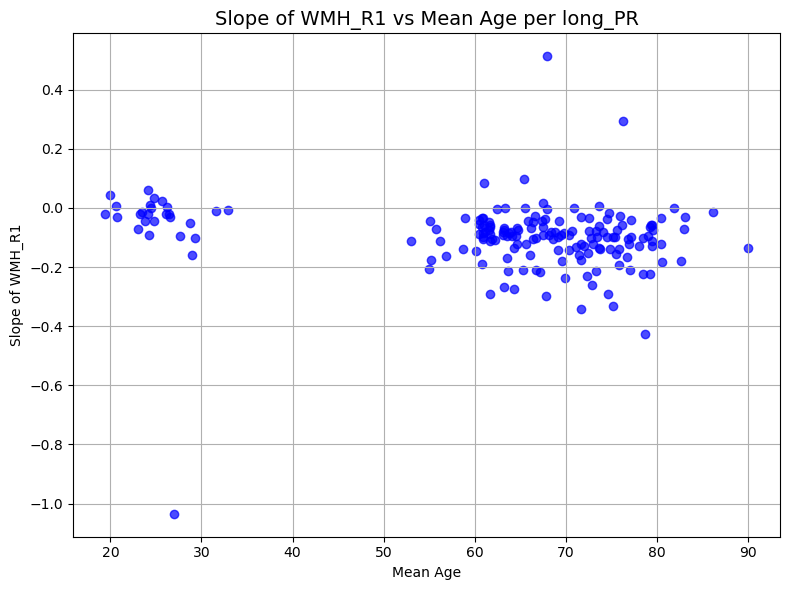

In [267]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Base definitions
base_metrics = ['MT', 'R1', 'R2*', 'ISOVF', 'ICVF', 'OD', 'MD', 'FA', 'g_ratio']
wm_types = ['WMH', 'NAWM']
metrics = [f"{wm}_{metric}" for metric in base_metrics for wm in wm_types]

# Step 1: Sort data by subject and age
merged_df_sorted = merged_df.sort_values(by=['long_PR', 'Age']).copy()

# Step 2: Remove outlier subjects per metric (if any value exceeds ±2SD of global mean)
filtered_df = pd.DataFrame()
for metric in metrics:
    global_mean = merged_df_sorted[metric].mean()
    global_std = merged_df_sorted[metric].std()
    lower, upper = global_mean - 2 * global_std, global_mean + 2 * global_std

    # Identify "clean" subjects (none of their values exceed ±2SD)
    valid_subjects = merged_df_sorted.groupby('long_PR').filter(
        lambda g: g[metric].between(lower, upper).all()
    )['long_PR'].unique()

    # Keep only clean data for this metric
    metric_df = merged_df_sorted[merged_df_sorted['long_PR'].isin(valid_subjects)].copy()
    filtered_df = pd.concat([filtered_df, metric_df])

# Step 3: Normalize per metric across subjects (column-wise normalization)
normalized_df = filtered_df.copy()
for metric in metrics:
    normalized_df[metric] = normalized_df[metric].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0
    )

# Step 4: Compute slopes for each metric (slope across Age for each subject)
slope_data = []

for metric in metrics:
    temp = normalized_df[['long_PR', 'Age', metric]].copy()

    def compute_slope(group):
        age_diff = group['Age'].diff()
        val_diff = group[metric].diff()
        slope = val_diff / age_diff
        return slope

    # Compute slopes for each subject
    slopes = normalized_df.groupby('long_PR').apply(lambda g: compute_slope(g)).reset_index(level=0)
    slopes.columns = ['long_PR', 'slope']
    slopes['metric'] = metric

    # Average slope per subject per metric
    avg_slopes = slopes.groupby('long_PR')['slope'].mean().reset_index()
    avg_slopes['metric'] = metric
    slope_data.append(avg_slopes)
    
# Step 5: Create heatmap matrix
slope_df = pd.concat(slope_data)
heatmap_data = slope_df.pivot(index='long_PR', columns='metric', values='slope')

# Step 5.1: Sort columns in interleaved WMH/NAWM pairs per metric type
ordered_columns = []
for metric in base_metrics:
    ordered_columns.append(f'WMH_{metric}')
    ordered_columns.append(f'NAWM_{metric}')
heatmap_data = heatmap_data[ordered_columns]

# Step 5.2: Remove rows (subjects) with all NaNs
heatmap_data = heatmap_data.dropna(how='all')

wmh_columns = [col for col in heatmap_data.columns if col.startswith("WMH_")]
heatmap_data = heatmap_data[~heatmap_data[wmh_columns].isna().all(axis=1)]

# Step 6: Plot the slope of 'WMH_R1' vs mean age for each subject
# Get the data for 'WMH_R1' and mean age of each subject
wmh_r1_slope = slope_df[slope_df['metric'] == 'WMH_R1'][['long_PR', 'slope']]
mean_age = normalized_df.groupby('long_PR')['Age'].mean().reset_index()

# Merge data for plotting
plot_data = pd.merge(wmh_r1_slope, mean_age, on='long_PR')

# Step 7: Plotting
plt.figure(figsize=(8, 6))
plt.scatter(plot_data['Age'], plot_data['slope'], color='blue', alpha=0.7)
plt.title('Slope of WMH_R1 vs Mean Age per long_PR', fontsize=14)
plt.xlabel('Mean Age')
plt.ylabel('Slope of WMH_R1')
plt.grid(True)
plt.tight_layout()
plt.show()


In [254]:
normalized_df

,WMH_MT,NAWM_MT,WMH_DWM_MT,WMH_SWM_MT,WMH_PVWM_MT,NAWM_DWM_MT,NAWM_SWM_MT,NAWM_PVWM_MT,Layer1_MT,Layer2_MT,...,Follow-up,SubjectName,Age,Unnamed: 6,Gender,StudySubjectID,StudyDate,PR_short,PR,slope
0,0.985674,1.327131,1.122476,1.016979,0.929718,1.461105,1.277745,1.286556,1.223926,1.358514,...,NaN,NaN,80.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.855573,1.259609,0.975792,0.937957,0.800102,1.373194,1.222801,1.213868,1.116429,1.268042,...,4.0,PR05710_JD190636^c,85.63,NaN,F,52058-01-4,2022-02-03,PR05710,sPR05710_JD190636,-0.282843
2,0.680150,1.458052,NaN,0.680150,NaN,1.573797,1.387067,1.477651,1.001379,1.209804,...,NaN,NaN,59.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.706849,0.309905,NaN,0.706849,NaN,0.282113,0.327956,0.311584,0.581935,0.511029,...,8.0,PR05713_SD101257^p,64.17,NaN,F,B0124-55-8,2022-02-08,PR05713,sPR05713_SD101257,-0.282843
4,0.554242,0.386902,0.374936,0.093712,0.562892,0.421984,0.391123,0.304675,0.539469,0.532358,...,NaN,NaN,65.34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,1.161339,1.535725,1.226903,1.180508,1.134494,1.628924,1.489303,1.498521,1.380064,1.489951,...,NaN,NaN,63.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
488,0.346656,0.389503,0.486947,0.501554,0.246632,0.428231,0.385555,0.317082,0.374172,0.385419,...,4.0,PR06701_CC300556,68.09,F,NaN,55645-1-4,NaN,PR06701,sPR06701_CC300556,-0.282843
490,1.188918,1.497165,1.297174,1.320417,1.113008,1.569748,1.462358,1.468741,1.424469,1.487024,...,NaN,NaN,58.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
489,0.519296,0.445486,0.535699,0.667594,0.484952,0.483074,0.438983,0.383315,0.500643,0.507404,...,NaN,NaN,63.13,NaN,NaN,NaN,NaN,NaN,NaN,-0.232113
